### Analyze Post-Optimization results for a single run 

**stochastic model with scenario tree for long-term demand uncertainty and using only a subset of weeks each representative year**

In [1]:
# Import python modules
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
# Import custom modules
import plotting
import utils

In [3]:
import yaml

In [4]:
# Notebook input parameters
SAVE_FIGURES = True
SAVE_TABLES = True
file_name = "May05_Mon_h11-GTSEP_stochastic_v1-128_ES_PT"
# file_name = "May07_Wed_h19-GTSEP_stochastic_v1-37_ES_PT"
# file_name = "May07_Wed_h20-GTSEP_stochastic_v1-37_ES_PT"
file_name = "May11_Sun_h09-GTSEP_stochastic_v1-37_ES_PT"
file_name = "May12_Mon_h15_m30_s50-GTSEP_stochastic_v1-128_ES_PT"

In [5]:
FOLDER = os.path.join(
    os.path.dirname(os.getcwd()),
    "runs",
    "single_runs",
    file_name,
)
# FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\37_4week_with_EVPI_and_VSS\1_May05_Mon_h12-GTSEP_stochastic_v1-37_ES_PT"
decision_variables_folder = os.path.join(FOLDER, "decision_variables")
model_info_folder = os.path.join(FOLDER, "model_info")
dual_variables_folder = os.path.join(FOLDER, "dual_variables")

In [6]:
RESULTS_FOLDER = os.path.join(FOLDER, "results")
if not os.path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)
if SAVE_TABLES:
    tables_folder = os.path.join(RESULTS_FOLDER, "tables")
    if not os.path.exists(tables_folder):
        os.makedirs(tables_folder)
else:
    tables_folder = None
if SAVE_FIGURES:
    figures_folder = os.path.join(RESULTS_FOLDER, "figures")
    if not os.path.exists(figures_folder):
        os.makedirs(figures_folder)
else:
    figures_folder = None

In [7]:
# Color mapping for scenarios (reuse for other plots)
scenario_colors = {
    "NT": "#1f77b4",
    "GA": "#ff7f0e",
    "DE": "#2ca02c",
    "Average": "#7f7f7f",
}

# Define a consistent color palette for cost categories
category_colors = {
    "Invest Gen": "#b20000",  # dark red
    "Invest Bat": "#0072b2",  # blue
    "Invest Tx": "#009e73",  # green
    "Prod Cost": "#f0e442",  # yellow
    "CO₂ Cost": "#d55e00",  # orange
    "Load Shedding Cost": "#cc79a7",  # magenta
    "Curtailment Cost": "#56b4e9",  # light blue
}

## Read data

In [8]:
model_info = pd.read_csv(os.path.join(model_info_folder, "model_info.csv"))
config = yaml.safe_load(open(os.path.join(model_info_folder, "config.yaml")))
jsons = utils.read_jsons_from_dir(model_info_folder)

In [9]:
scenarios = jsons["scenarios"]
scenario_probabilities = jsons["scenario_probabilities"]
week_weights = jsons["week_weights"]

In [10]:
data_folder_name = config["data_folder_name"]
VOLL = config["VOLL"]
CC = config["CC"]
CO2_price = config["CO2_price"]
E_limit = config["E_limit"]
p_max_new_branch = config["p_max_new_branch"]
p_min_new_branch = config["p_min_new_branch"]
expansion_factor = config["expansion_factor"]
MS = config["MS"]
model_name = config["model_name"]
MIPGap = config["MIPGap"]
years = config["years"]
r = config["discount_rate"]
representative_period_unit = config["representative_period_unit"]
weeks = config["representative_periods"]
scenario_file = config["scenario_file"]

In [11]:
input_data_folder = os.path.join(
    os.path.dirname(os.getcwd()), "data", "processed", config["data_folder_name"]
)
input_data = utils.load_multi_year_csv_files_with_week_from_folder(
    years=years, data_folder_path=input_data_folder
)
scenario_multiplier = utils.load_scenario_multiplier(scenario_file_name=scenario_file)

**Note:** The input data is such that all data is the same for all years. All the data that is year-dependent has year as index. The only exception is the demand data, which does not have copies for years.

In [12]:
dual_variables = utils.load_csv_files_from_folder_with_scenarios(dual_variables_folder)
decision_varables = utils.load_csv_files_from_folder_with_scenarios(
    decision_variables_folder
)

In [13]:
print("Input data")
for data_type in input_data.keys():
    print(f"{data_type}")
print()
print("Decision variables:")
for decision_variable in decision_varables.keys():
    print(decision_variable)
print()
print("Dual variables:")
for dual_variable in dual_variables.keys():
    print(dual_variable)

Input data
batteries
branches
capacity_factors
generators
generator_costs
hourly_demand
nodes

Decision variables:
battery_capacity
battery_charging
battery_discharging
battery_soc
branch_capacity
curtailment
generation
generator_capacity
load_shedding
power_flow

Dual variables:
battery_charge_new_max_duals
battery_charge_old_duals
battery_discharge_new_max_duals
battery_discharge_old_duals
branch_extension_duals
branch_flow_new_duals_max
branch_flow_new_duals_min
branch_flow_old_duals_max
branch_flow_old_duals_min
emissions_duals
gen_extension_duals
gen_output_new_duals
gen_output_old_duals
load_shedding_duals
power_balance_duals


In [14]:
# read dataframes
# input data
batteries = input_data["batteries"]
branches = input_data["branches"]
generators = input_data["generators"]
capacity_factors = input_data["capacity_factors"]
generator_costs = input_data["generator_costs"]
hourly_demand = input_data["hourly_demand"]
nodes = input_data["nodes"]
# decision variables
battery_capacity = decision_varables["battery_capacity"]
battery_charging = decision_varables["battery_charging"]
battery_discharging = decision_varables["battery_discharging"]
battery_soc = decision_varables["battery_soc"]
branch_capacity = decision_varables["branch_capacity"]
curtailment = decision_varables["curtailment"]
generation = decision_varables["generation"]
generator_capacity = decision_varables["generator_capacity"]
load_shedding = decision_varables["load_shedding"]
power_flow = decision_varables["power_flow"]
# dual variables
battery_charge_new_max_duals = dual_variables["battery_charge_new_max_duals"]
battery_charge_old_duals = dual_variables["battery_charge_old_duals"]
battery_discharge_new_max_duals = dual_variables["battery_discharge_new_max_duals"]
battery_discharge_old_duals = dual_variables["battery_discharge_old_duals"]
branch_extension_duals = dual_variables["branch_extension_duals"]
branch_flow_old_duals_min = dual_variables["branch_flow_old_duals_min"]
branch_flow_old_duals_max = dual_variables["branch_flow_old_duals_max"]
branch_flow_new_duals_min = dual_variables["branch_flow_new_duals_min"]
branch_flow_new_duals_max = dual_variables["branch_flow_new_duals_max"]
emissions_duals = dual_variables["emissions_duals"]
gen_extension_duals = dual_variables["gen_extension_duals"]
gen_output_new_duals = dual_variables["gen_output_new_duals"]
gen_output_old_duals = dual_variables["gen_output_old_duals"]
load_shedding_duals = dual_variables["load_shedding_duals"]
power_balance_duals = dual_variables["power_balance_duals"]

## Generators analysis

### Generators preprocessing

In [15]:
generators["extension_potential"] = generators["p_nom"] * config["expansion_factor"]

In [16]:
def add_capacity_and_cumulative_metrics(
    generators_df, generator_capacity_df, capacity_col="value"
):
    """
    Merge new capacity values, drop 'extended_by', and add cumulative metrics.

    Parameters
    ----------
    generators_df : pd.DataFrame
        DataFrame indexed by (year, generator), containing columns including
        'extension_potential' and 'extended_by'.
    generator_capacity_df : pd.DataFrame
        DataFrame indexed by (generator, year) with a column (named by capacity_col)
        of new capacity values.
    capacity_col : str, optional
        Name of the column in generator_capacity_df holding the new capacity values
        (default 'value').

    Returns
    -------
    pd.DataFrame
        DataFrame indexed by (year, generator) containing:
        - all original columns except 'extended_by'
        - 'new_capacity' (from generator_capacity_df)
        - 'cum_new_capacity' (running total of new_capacity per generator)
        - 'cum_extension_potential' (running total of extension_potential per generator)
    """
    # 1. Reset indices to expose 'year' and 'generator' as columns
    gen = generators_df.reset_index()
    cap = generator_capacity_df.reset_index()

    # 2. Rename the capacity output column to 'new_capacity'
    cap = cap.rename(columns={capacity_col: "new_capacity"})

    # 3. Merge new_capacity into the generators table
    merged = gen.merge(
        cap[["year", "generator", "new_capacity"]], on=["year", "generator"], how="left"
    )

    # 4. Drop the old 'extended_by' column
    merged = merged.drop(columns=["extended_by"], errors="ignore")

    # 5. Compute cumulative metrics per generator in chronological order
    merged = merged.sort_values(["generator", "year"])
    # cumulative new capacity
    merged["cum_new_capacity"] = merged.groupby("generator")["new_capacity"].cumsum()
    # cumulative extension potential
    merged["cum_extension_potential"] = merged.groupby("generator")[
        "extension_potential"
    ].cumsum()

    # 6. Restore the MultiIndex
    merged = merged.set_index(["year", "generator"])

    merged["total_capacity"] = merged["p_nom"] + merged["cum_new_capacity"]

    return merged

In [17]:
# Example usage:
generators = add_capacity_and_cumulative_metrics(generators, generator_capacity)

### Generator Investment and Capacity Plots 

In [18]:
if SAVE_FIGURES:
    generators_save_folder = os.path.join(figures_folder, "generators")
    if not os.path.exists(generators_save_folder):
        os.makedirs(generators_save_folder)
else:
    generators_save_folder = None

In [19]:
def plot_capacity_investment_by_carrier(
    generators: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Plot a stacked bar chart of new capacity investments per year by generation technology.

    Parameters
    ----------
    generators : pd.DataFrame
        DataFrame indexed by (year, generator) with columns:
        - new_capacity
        - carrier
        - nice_name
        - color
    savefolder : str or None, optional
        Directory to save the figure. If None, the figure is not saved. Default is None.
    """
    # Prepare the data: aggregate new_capacity by year & carrier
    temp = generators.reset_index()
    agg = (
        temp.groupby(["year", "carrier"])["new_capacity"]
        .sum()
        .unstack("carrier")
        .fillna(0)
    )

    # Build mappings for labels and colors from the original DataFrame
    meta = (
        temp[["carrier", "nice_name", "color"]]
        .drop_duplicates("carrier")
        .set_index("carrier")
    )
    labels = [meta.loc[c, "nice_name"] for c in agg.columns]
    colors = [meta.loc[c, "color"] for c in agg.columns]

    # Plot
    fig, ax = plt.subplots()
    agg.plot(kind="bar", stacked=True, ax=ax, color=colors)

    ax.set_xlabel("Year")
    ax.set_ylabel("New Capacity (MW)")
    ax.legend(labels, title="Technology")

    plt.tight_layout()

    # Save if requested
    if savefolder:
        savepath = os.path.join(savefolder, "capacity_investment_by_technology.png")
        fig.savefig(savepath, bbox_inches="tight")

    # Print title line instead of setting it on the plot
    print("Annual Capacity Investments by Technology")

    plt.show()

Annual Capacity Investments by Technology


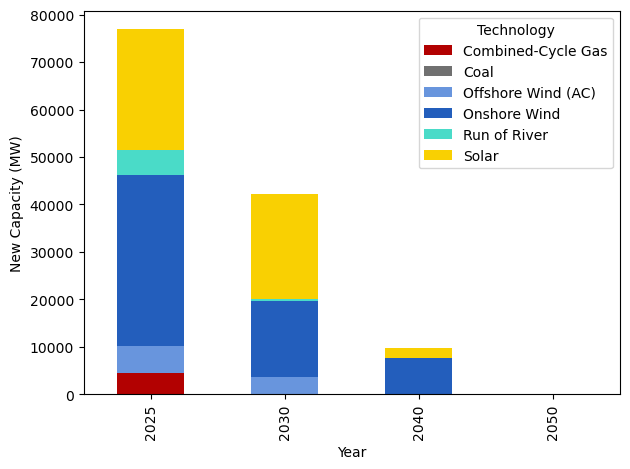

In [20]:
plot_capacity_investment_by_carrier(generators, generators_save_folder)

In [21]:
def plot_capacity_spending_by_carrier(
    generators: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Plot a stacked bar chart of annual capital expenditure on new capacity by generation technology,
    with the y-axis in billions of euros.

    Parameters
    ----------
    generators : pd.DataFrame
        DataFrame indexed by (year, generator) with columns:
        - new_capacity
        - capital_cost
        - carrier
        - nice_name
        - color
    savefolder : str or None, optional
        Directory to save the figure. If None, the figure is not saved. Default is None.
    """
    # Prepare the data: compute spending = new_capacity * capital_cost (in billions)
    temp = generators.reset_index()
    temp["investment_cost"] = temp["new_capacity"] * temp["capital_cost"] / 1e9

    # Aggregate by year & carrier
    agg = (
        temp.groupby(["year", "carrier"])["investment_cost"]
        .sum()
        .unstack("carrier")
        .fillna(0)
    )

    # Build mappings for labels and colors
    meta = (
        temp[["carrier", "nice_name", "color"]]
        .drop_duplicates("carrier")
        .set_index("carrier")
    )
    labels = [meta.loc[c, "nice_name"] for c in agg.columns]
    colors = [meta.loc[c, "color"] for c in agg.columns]

    # Plot
    fig, ax = plt.subplots()
    agg.plot(kind="bar", stacked=True, ax=ax, color=colors)

    ax.set_xlabel("Year")
    ax.set_ylabel("Capital Expenditure (billion €)")
    ax.legend(labels, title="Technology")

    plt.tight_layout()

    # Save if requested
    if savefolder:
        savepath = os.path.join(savefolder, "capacity_spending_by_technology.png")
        fig.savefig(savepath, bbox_inches="tight")

    # Print title line
    print("Annual Capital Expenditure by Technology")

    plt.show()

Annual Capital Expenditure by Technology


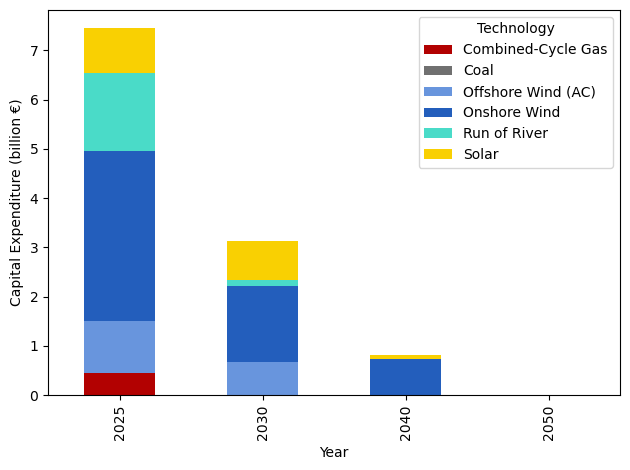

In [22]:
plot_capacity_spending_by_carrier(generators, generators_save_folder)

In [23]:
def plot_total_capacity_growth(
    generators: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Plot the growth in total installed capacity over time.

    For each year:
    - 'existing_capacity' is the initial p_nom plus all new_capacity built in prior periods.
    - 'new_capacity' is the capacity added in that year.

    Y-axis is in GW. Legend labels are made reader-friendly. Uses a new color palette.
    """
    temp = generators.reset_index()
    years = sorted(temp["year"].unique())
    first_year = years[0]

    # Initial capacity (MW) at first year
    init = temp[temp["year"] == first_year].set_index("generator")["p_nom"]

    # Compute cumulative new capacity
    temp = temp.sort_values(["generator", "year"])
    temp["cum_new_capacity"] = temp.groupby("generator")["new_capacity"].cumsum()
    temp["existing_capacity"] = init.reindex(temp["generator"]).values + (
        temp["cum_new_capacity"] - temp["new_capacity"]
    )

    # Aggregate and convert to GW
    agg = temp.groupby("year")[["existing_capacity", "new_capacity"]].sum().loc[years]
    agg_gw = agg / 1e3

    fig, ax = plt.subplots()
    agg_gw.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=["#1b9e77", "#d95f02"],  # new palette: green & orange
    )

    ax.set_xlabel("Year")
    ax.set_ylabel("Capacity (GW)")
    ax.legend(["Existing Capacity", "New Capacity"], title="")

    plt.tight_layout()

    if savefolder:
        savepath = os.path.join(savefolder, "total_capacity_growth.png")
        fig.savefig(savepath, bbox_inches="tight")

    print("Growth in Total Installed Capacity")
    plt.show()

Growth in Total Installed Capacity


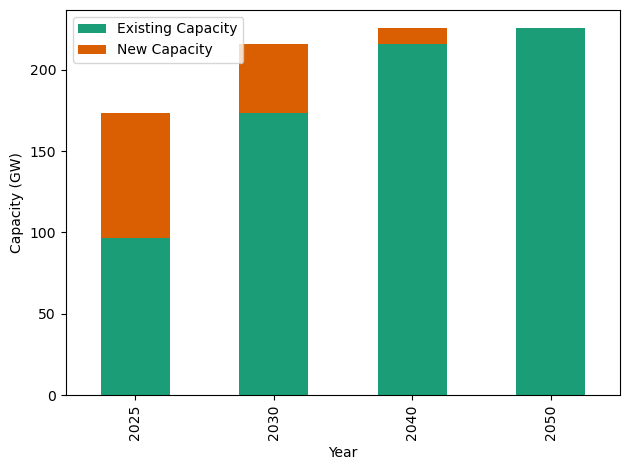

In [24]:
plot_total_capacity_growth(generators, generators_save_folder)

In [25]:
def plot_extension_vs_potential_by_carrier(
    generators: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Single-figure bar chart of extension potential vs actual new capacity by technology and year,
    with values in GW.

    For each year, two sets of stacked bars (Actual vs Potential), colored by carrier.
    Potential bars are drawn with alpha=0.5.

    Parameters
    ----------
    generators : pd.DataFrame
        DataFrame indexed by (year, generator) with columns:
        - new_capacity
        - extension_potential
        - carrier
        - nice_name
        - color
    savefolder : str or None, optional
        Directory to save the figure. If None, the figure is not saved. Default is None.
    """
    temp = generators.reset_index()
    agg = (
        temp.groupby(["year", "carrier"])
        .agg(
            extension_potential=("extension_potential", "sum"),
            new_capacity=("new_capacity", "sum"),
        )
        .reset_index()
    )

    # Pivot and convert to GW
    potential_df = (
        agg.pivot(index="year", columns="carrier", values="extension_potential").fillna(
            0
        )
        / 1e3
    )
    actual_df = (
        agg.pivot(index="year", columns="carrier", values="new_capacity").fillna(0)
        / 1e3
    )
    years = potential_df.index.tolist()
    carriers = potential_df.columns.tolist()

    meta = (
        temp[["carrier", "nice_name", "color"]]
        .drop_duplicates("carrier")
        .set_index("carrier")
    )

    positions = np.arange(len(years))
    width = 0.4
    bottom_act = np.zeros(len(years))
    bottom_pot = np.zeros(len(years))

    fig, ax = plt.subplots(figsize=(10, 6))
    for carrier in carriers:
        color = meta.loc[carrier, "color"]
        nice = meta.loc[carrier, "nice_name"]
        act_vals = actual_df[carrier].reindex(years).values
        pot_vals = potential_df[carrier].reindex(years).values

        ax.bar(
            positions - width / 2,
            act_vals,
            width,
            bottom=bottom_act,
            color=color,
            label=nice,
        )
        ax.bar(
            positions + width / 2,
            pot_vals,
            width,
            bottom=bottom_pot,
            color=color,
            alpha=0.5,
        )

        bottom_act += act_vals
        bottom_pot += pot_vals

    ax.set_xticks(positions)
    ax.set_xticklabels([str(y) for y in years])
    ax.set_xlabel("Year")
    ax.set_ylabel("Capacity (GW)")

    # Expand right margin for legends
    fig.subplots_adjust(right=0.85)

    from matplotlib.patches import Patch

    # Technology legend
    tech_handles = [Patch(facecolor=meta.loc[c, "color"]) for c in carriers]
    tech_labels = [meta.loc[c, "nice_name"] for c in carriers]
    leg1 = ax.legend(
        tech_handles,
        tech_labels,
        title="Technology",
        bbox_to_anchor=(0.88, 1),
        loc="upper left",
        borderaxespad=0.0,
        framealpha=1.0,
    )
    ax.add_artist(leg1)

    # Bar type legend
    type_handles = [
        Patch(facecolor="gray", alpha=1),
        Patch(facecolor="gray", alpha=0.5),
    ]
    type_labels = ["Actual", "Potential"]
    ax.legend(
        type_handles,
        type_labels,
        title="Bar Type",
        bbox_to_anchor=(1.02, 0.66),
        loc="upper left",
        borderaxespad=0.0,
        fontsize="small",
    )

    print("Extension Potential vs Actual New Capacity by Technology")
    plt.show()

    if savefolder:
        savepath = os.path.join(savefolder, "extension_vs_actual_by_technology.png")
        fig.savefig(savepath, bbox_inches="tight")

Extension Potential vs Actual New Capacity by Technology


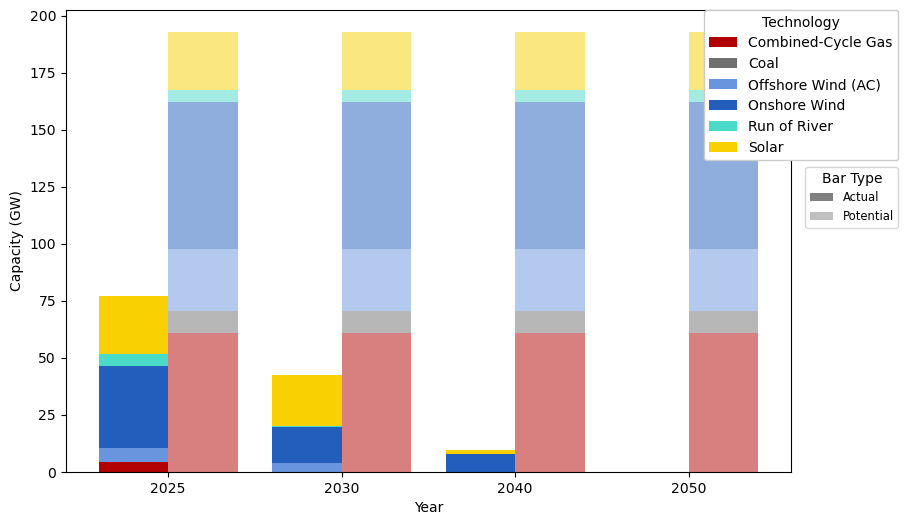

In [26]:
plot_extension_vs_potential_by_carrier(generators, generators_save_folder)

### Generators Production and Time Series Plots

In [27]:
def create_energy_production_by_carrier_table(
    generation: pd.DataFrame,
    generators: pd.DataFrame,
    scenarios: dict,
    scenario_probabilities: dict,
    week_weights: dict,
    savefolder: str = None,
) -> None:
    """
    Create a table of annual energy production by carrier, both unweighted and weighted by scenario probabilities.

    Parameters
    ----------
    generation : pd.DataFrame
        DataFrame indexed by (year, generator, scenario, week) with columns:
        - value (energy produced)
    generators : pd.DataFrame
        DataFrame indexed by (year, generator) with columns:
        - carrier (energy carrier type)
    scenarios : dict
        Dictionary mapping years to lists of scenarios.
    scenario_probabilities : dict
        Dictionary mapping years to lists of scenario probabilities.
    week_weights : dict
        Dictionary mapping weeks to weights for annualization.

    Returns
    -------
    None
        Displays the unweighted and weighted tables.
    """
    # 1) Build a small DataFrame of (year, scenario, probability)
    scenario_data = []
    for year_str, scen_list in scenarios.items():
        year = int(year_str)
        probs = scenario_probabilities[year_str]
        for scen, prob in zip(scen_list, probs):
            scenario_data.append({"year": year, "scenario": scen, "probability": prob})
    prob_df = pd.DataFrame(scenario_data)

    # 2) Compute weekly sums and annualize using week_weights
    weekly = (
        generation.groupby(["generator", "scenario", "year", "week"])["value"]
        .sum()
        .reset_index(name="weekly_gen")
    )
    weekly["weight"] = weekly["week"].astype(str).map(week_weights)
    weekly["annual_gen"] = weekly["weekly_gen"] * weekly["weight"]

    # 3) Sum to get annual generation per (generator, scenario, year)
    annual = (
        weekly.groupby(["generator", "scenario", "year"])["annual_gen"]
        .sum()
        .reset_index()
    )

    # 4) Map each generator to its carrier
    gen2car = (
        generators.reset_index()[["generator", "carrier"]]
        .drop_duplicates("generator")
        .set_index("generator")["carrier"]
    )
    annual["carrier"] = annual["generator"].map(gen2car)

    # 5) Unweighted: mean across scenarios
    unweighted = (
        annual.groupby(["year", "carrier"])["annual_gen"]
        .mean()
        .unstack("carrier")
        .fillna(0)
    )

    # 6) Weighted: merge probabilities and compute expected value
    annual = annual.merge(prob_df, on=["year", "scenario"], how="left")
    annual["weighted_gen"] = annual["annual_gen"] * annual["probability"]
    weighted = (
        annual.groupby(["year", "carrier"])["weighted_gen"]
        .sum()
        .unstack("carrier")
        .fillna(0)
    )

    # # 7) Display
    # print("Annual energy production by carrier (unweighted average across scenarios):")
    # display(unweighted)

    print("\nAnnual expected energy production by carrier (scenario-weighted):")
    # display(weighted)
    if savefolder:
        savepath = os.path.join(savefolder, "energy_production_by_carrier_table.csv")
        weighted.to_csv(savepath, index=True)

    return weighted

In [28]:
production_by_carrier_table = create_energy_production_by_carrier_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    savefolder=tables_folder,
)


Annual expected energy production by carrier (scenario-weighted):


In [29]:
def make_annual_production_table(
    generation: pd.DataFrame,
    generators: pd.DataFrame,
    scenarios: dict,
    scenario_probabilities: dict,
    week_weights: dict,
    savefolder: str | None = None,
) -> None:
    """
    Compute and print the annual expected energy production by carrier and scenario,
    and optionally save it to CSV.

    Parameters
    ----------
    generation : pd.DataFrame
        Hourly generation with MultiIndex (generator, scenario, year, week, hour)
        and a 'value' column in MWh.
    generators : pd.DataFrame
        Generator metadata with a 'carrier' column, indexed by (year, generator)
        or containing a 'generator' column to map to carrier.
    savefolder : str or None, optional
        Directory to save the CSV. If None, the table is not saved.
    """
    # 1. Build a DataFrame of scenario probabilities
    scenario_data = []
    for year_str, scen_list in scenarios.items():
        year = int(year_str)
        probs = scenario_probabilities[year_str]
        for scen, prob in zip(scen_list, probs):
            scenario_data.append({"year": year, "scenario": scen, "probability": prob})
    prob_df = pd.DataFrame(scenario_data)

    # 2. Sum hourly → weekly, then annualize
    weekly = (
        generation.groupby(["generator", "scenario", "year", "week"])["value"]
        .sum()
        .reset_index(name="weekly_gen")
    )
    weekly["weight"] = weekly["week"].astype(str).map(week_weights)
    weekly["annual_gen"] = weekly["weekly_gen"] * weekly["weight"]

    # 3. Collapse to annual per (generator, scenario, year)
    annual = (
        weekly.groupby(["generator", "scenario", "year"])["annual_gen"]
        .sum()
        .reset_index()
    )

    # 4. Map generator → carrier
    gen2car = (
        generators.reset_index()[["generator", "carrier"]]
        .drop_duplicates("generator")
        .set_index("generator")["carrier"]
    )
    annual["carrier"] = annual["generator"].map(gen2car)

    # 5. Merge probabilities and compute weighted generation
    annual = annual.merge(prob_df, on=["year", "scenario"], how="left")
    annual["expected_gen"] = annual["annual_gen"] * annual["probability"]

    # 6. Pivot to get carriers as columns, for each (year, scenario)
    table = (
        annual.groupby(["year", "scenario", "carrier"])["expected_gen"]
        .sum()
        .unstack("carrier")
        .fillna(0)
    )

    # 7. Add a Total column
    table["Total"] = table.sum(axis=1)

    # 8. Print the table
    print("Annual expected energy production by carrier and scenario (MWh):")
    # print(table)

    # 9. Save if requested
    if savefolder:
        savepath = os.path.join(
            savefolder, "annual_production_by_carrier_and_scenario.csv"
        )
        table.to_csv(savepath)
    return table

In [30]:
def make_weighted_annual_production_cost_by_year_table(
    generation: pd.DataFrame,
    generators: pd.DataFrame,
    week_weights: dict[str, float],
    carbon_price: float,
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Compute and return the scenario-weighted annual production cost (including CO₂ emissions)
    by technology and year.

    Parameters
    ----------
    generation : pd.DataFrame
        Hourly generation with MultiIndex (generator, scenario, year, week, hour)
        and a 'value' column in MWh.
    generators : pd.DataFrame
        Generator metadata with columns:
        - marginal_cost (EUR/MWh)
        - co2_emissions (tonnes CO₂/MWh)
        - carrier
        indexed by (year, generator) or containing 'year' & 'generator' columns.
    week_weights : dict[str, float]
        Multiplier for each week to annualize generation.
    carbon_price : float
        Emission price in EUR per tonne CO₂.
    savefolder : str or None, optional
        Directory to save the CSV. If None, no file is written.

    Returns
    -------
    pd.DataFrame
        Indexed by year, columns are carrier types (plus 'Total'),
        values are the scenario-weighted annual production cost including emissions (EUR).
    """
    # build scenario probability DataFrame
    scenario_data = []
    for year_str, scen_list in scenarios.items():
        year = int(year_str)
        probs = scenario_probabilities[year_str]
        for scen, prob in zip(scen_list, probs):
            scenario_data.append({"year": year, "scenario": scen, "probability": prob})
    prob_df = pd.DataFrame(scenario_data)

    # hourly → weekly sums, then annualize
    weekly = (
        generation.groupby(["generator", "scenario", "year", "week"])["value"]
        .sum()
        .reset_index(name="weekly_gen")
    )
    weekly["weight"] = weekly["week"].astype(str).map(week_weights)
    weekly["annual_gen"] = weekly["weekly_gen"] * weekly["weight"]

    # annual total per generator–scenario–year
    annual = (
        weekly.groupby(["generator", "scenario", "year"])["annual_gen"]
        .sum()
        .reset_index()
    )

    # attach cost & emission rates and carrier
    meta = generators.reset_index()[
        ["year", "generator", "marginal_cost", "co2_emissions", "carrier"]
    ].drop_duplicates(["year", "generator"])
    annual = annual.merge(meta, on=["year", "generator"], how="left")

    # compute cost including emissions
    annual["production_cost"] = annual["annual_gen"] * annual["marginal_cost"]
    annual["co2_emission"] = annual["annual_gen"] * annual["co2_emissions"]
    annual["co2_cost"] = annual["co2_emission"] * carbon_price
    annual["total_cost"] = annual["production_cost"] + annual["co2_cost"]

    # merge probabilities and compute weighted cost
    annual = annual.merge(prob_df, on=["year", "scenario"], how="left")
    annual["weighted_cost"] = annual["total_cost"] * annual["probability"]

    # pivot to carriers by year
    table = (
        annual.groupby(["year", "carrier"])["weighted_cost"]
        .sum()
        .unstack("carrier")
        .fillna(0)
    )
    table["Total"] = table.sum(axis=1)

    print("Annual scenario-weighted production cost (incl. CO₂) by technology (EUR):")

    if savefolder:
        path = os.path.join(savefolder, "annual_weighted_cost_by_carrier.csv")
        table.to_csv(path)

    return table

In [136]:
analytics.make_annual_production_table(
    generation, generators, scenarios, scenario_probabilities, tables_folder
)

NameError: name 'analytics' is not defined

In [32]:
annual_cost_table = make_weighted_annual_production_cost_by_year_table(
    generation,
    generators,
    week_weights,
    carbon_price=CO2_price,
    savefolder=tables_folder,
)
annual_cost_table

Annual scenario-weighted production cost (incl. CO₂) by technology (EUR):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,2.579421e+09,7.606796e+07,537339.736947,1.546195e+06,0.0,515240.385653,2.658087e+09
2030,1.766468e+09,8.132434e+07,547693.751842,1.629572e+06,0.0,778814.823618,1.850748e+09
2040,2.527882e+09,1.549413e+08,629692.020049,2.082940e+06,0.0,842653.300191,2.686379e+09
2050,2.884687e+09,1.873694e+08,670302.366089,2.265893e+06,0.0,852847.218959,3.075846e+09


In [33]:
def make_weighted_annual_production_by_year(
    generation: pd.DataFrame, generators: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Compute and print the annual scenario-weighted energy production by carrier (years only),
    and optionally save it to CSV.

    Parameters
    ----------
    generation : pd.DataFrame
        Hourly generation with MultiIndex (generator, scenario, year, week, hour)
        and a 'value' column in MWh.
    generators : pd.DataFrame
        Generator metadata with a 'carrier' column, indexed by (year, generator)
        or containing a 'generator' column to map to carrier.
    savefolder : str or None, optional
        Directory to save the CSV. If None, the table is not saved.
    """
    # Build scenario probability lookup
    scenario_data = []
    for year_str, scen_list in scenarios.items():
        year = int(year_str)
        probs = scenario_probabilities[year_str]
        for scen, prob in zip(scen_list, probs):
            scenario_data.append({"year": year, "scenario": scen, "probability": prob})
    prob_df = pd.DataFrame(scenario_data)

    # Hourly → weekly sums and annualize
    weekly = (
        generation.groupby(["generator", "scenario", "year", "week"])["value"]
        .sum()
        .reset_index(name="weekly_gen")
    )
    weekly["weight"] = weekly["week"].astype(str).map(week_weights)
    weekly["annual_gen"] = weekly["weekly_gen"] * weekly["weight"]

    # Annual total per (generator, scenario, year)
    annual = (
        weekly.groupby(["generator", "scenario", "year"])["annual_gen"]
        .sum()
        .reset_index()
    )

    # Map generator → carrier
    gen2car = (
        generators.reset_index()[["generator", "carrier"]]
        .drop_duplicates("generator")
        .set_index("generator")["carrier"]
    )
    annual["carrier"] = annual["generator"].map(gen2car)

    # Merge probabilities and compute weighted generation
    annual = annual.merge(prob_df, on=["year", "scenario"], how="left")
    annual["expected_gen"] = annual["annual_gen"] * annual["probability"]

    # Pivot to carriers, index by year
    table = (
        annual.groupby(["year", "carrier"])["expected_gen"]
        .sum()
        .unstack("carrier")
        .fillna(0)
    )

    # Add total column
    table["Total"] = table.sum(axis=1)

    # Print
    print("Annual scenario-weighted energy production by carrier (MWh):")
    # print(table)

    # Save if requested
    if savefolder:
        savepath = os.path.join(savefolder, "annual_weighted_production_by_carrier.csv")
        table.to_csv(savepath)
    return table

In [34]:
weighted_annual_production_by_year = make_weighted_annual_production_by_year(
    generation, generators, tables_folder
)
weighted_annual_production_by_year

Annual scenario-weighted energy production by carrier (MWh):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,4.612881e+07,1.332259e+06,3.582265e+07,1.030797e+08,3.739784e+07,5.152404e+07,2.752853e+08
2030,3.157218e+07,1.424320e+06,3.651292e+07,1.086381e+08,3.938636e+07,7.788148e+07,2.954154e+08
2040,4.504883e+07,2.713651e+06,4.197947e+07,1.388627e+08,3.938636e+07,8.426533e+07,3.522563e+08
2050,5.139102e+07,3.281600e+06,4.468682e+07,1.510595e+08,3.938636e+07,8.528472e+07,3.750901e+08


In [35]:
def plot_weighted_production_evolution(
    weighted_table: pd.DataFrame,
    generators: pd.DataFrame,
    savefolder: str | None = None,
) -> None:
    """
    Plot the evolution of scenario-weighted annual energy production by technology over years.

    Parameters
    ----------
    weighted_table : pd.DataFrame
        Indexed by year, columns are carrier types (and possibly 'Total'), values are expected annual generation in MWh.
    generators : pd.DataFrame
        Generator metadata with 'carrier', 'nice_name', and 'color' columns.
    savefolder : str or None
        Directory to save the figure. If None, the figure is not saved.
    """
    # Identify carrier columns (exclude 'Total' if present)
    carriers = [c for c in weighted_table.columns if c != "Total"]

    # Extract color and label mappings
    meta = (
        generators.reset_index()[["carrier", "nice_name", "color"]]
        .drop_duplicates("carrier")
        .set_index("carrier")
    )

    # Convert MWh → TWh
    data_twh = weighted_table[carriers] / 1e6

    # Plot stacked area
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [meta.loc[c, "color"] for c in carriers]
    labels = [meta.loc[c, "nice_name"] for c in carriers]
    ax.stackplot(
        data_twh.index, [data_twh[c] for c in carriers], labels=labels, colors=colors
    )

    ax.set_xlabel("Year")
    ax.set_ylabel("Annual Generation (TWh)")
    plt.tight_layout()

    # Place legend to the right
    fig.subplots_adjust(right=0.75)
    ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")

    # Print title
    print(
        "Evolution of Annual Energy Production by Technology (averaged across scenarios)"
    )

    plt.show()

    # Save if requested
    if savefolder:
        savepath = os.path.join(savefolder, "production_evolution_by_technology.png")
        fig.savefig(savepath, bbox_inches="tight")

Evolution of Annual Energy Production by Technology (averaged across scenarios)


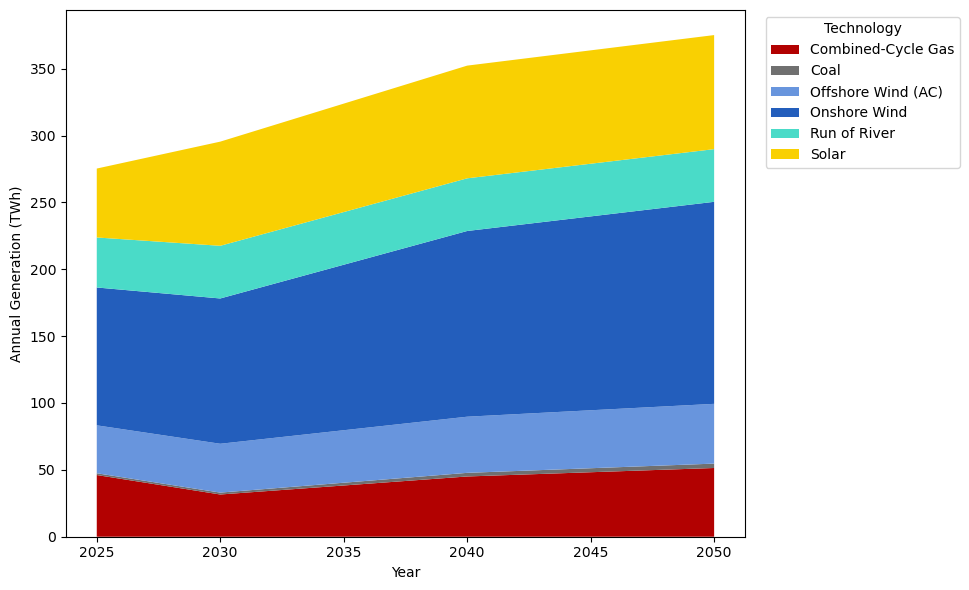

In [36]:
plot_weighted_production_evolution(
    weighted_annual_production_by_year, generators, savefolder=figures_folder
)

In [37]:
def plot_weighted_production_cost_evolution(
    weighted_cost_table: pd.DataFrame,
    generators: pd.DataFrame,
    savefolder: str | None = None,
) -> None:
    """
    Plot the evolution of scenario-weighted annual production cost including CO₂ emissions
    by technology over years, as a stacked area chart.

    Parameters
    ----------
    weighted_cost_table : pd.DataFrame
        Indexed by year, columns are carrier types (and possibly 'Total'),
        values are expected annual production cost including emissions in EUR.
    generators : pd.DataFrame
        Generator metadata with 'carrier', 'nice_name', and 'color' columns.
    savefolder : str or None
        Directory to save the figure. If None, the figure is not saved.
    """
    # identify technology columns (drop any 'Total')
    carriers = [c for c in weighted_cost_table.columns if c != "Total"]

    # build mapping of nice_name and color
    meta = (
        generators.reset_index()[["carrier", "nice_name", "color"]]
        .drop_duplicates("carrier")
        .set_index("carrier")
    )

    # convert EUR → billion EUR
    data_beur = weighted_cost_table[carriers] / 1e9

    # plot stacked area
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [meta.loc[c, "color"] for c in carriers]
    labels = [meta.loc[c, "nice_name"] for c in carriers]
    ax.stackplot(
        data_beur.index, [data_beur[c] for c in carriers], labels=labels, colors=colors
    )

    ax.set_xlabel("Year")
    ax.set_ylabel("Annual Production Cost including Emissions (billion €)")
    plt.tight_layout()

    # shift legend to right
    fig.subplots_adjust(right=0.75)
    ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")

    print("Evolution of Annual Production Cost including CO₂ Emissions by Technology")
    plt.show()

    if savefolder:
        savepath = os.path.join(
            savefolder, "production_cost_evolution_by_technology.png"
        )
        fig.savefig(savepath, bbox_inches="tight")

Evolution of Annual Production Cost including CO₂ Emissions by Technology


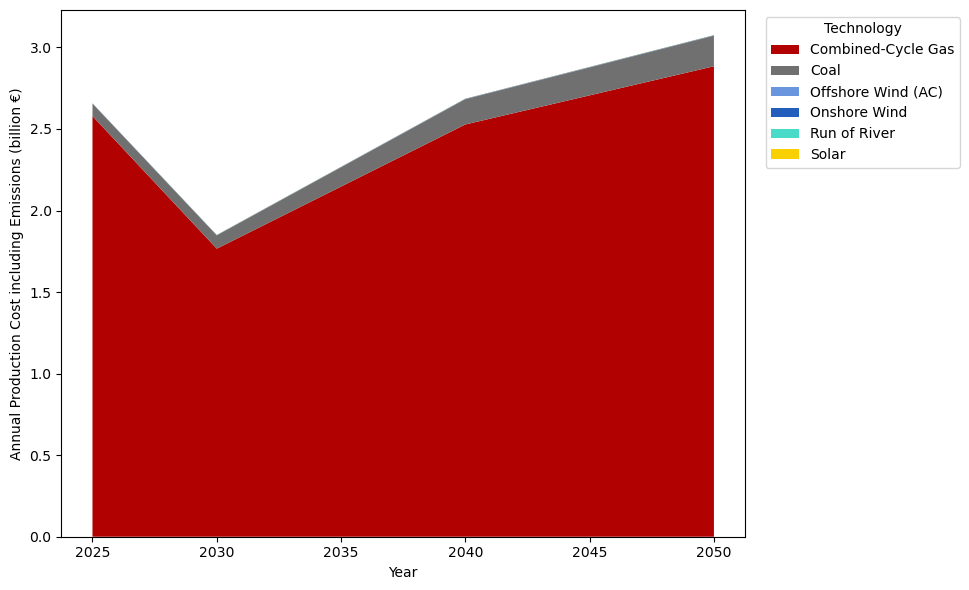

In [38]:
plot_weighted_production_cost_evolution(
    annual_cost_table, generators, savefolder=figures_folder
)

In [39]:
def make_yearly_system_costs_table(
    generation: pd.DataFrame,
    generators: pd.DataFrame,
    week_weights: dict[str, float],
    carbon_price: float,
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Compute annual system-level metrics by year and scenario:
      - yearly production (MWh)
      - yearly CO2 emissions (tonnes)
      - yearly CO2 emission cost (EUR)
      - yearly production cost (EUR)
      - yearly production cost including emission cost (EUR)

    Parameters
    ----------
    generation : pd.DataFrame
        Hourly generation with MultiIndex
        (generator, scenario, year, week, hour) and a 'value' column in MWh.
    generators : pd.DataFrame
        Generator metadata with columns:
        - marginal_cost (EUR/MWh)
        - co2_emissions (tonnes CO2/MWh)
        indexed by (year, generator) or containing 'year' & 'generator'.
    week_weights : dict[str, float]
        Multipliers for each week to annualize generation.
    carbon_price : float
        Emission price in EUR per tonne CO2.
    savefolder : str or None, optional
        Directory to save the CSV. If None, no file is written.

    Returns
    -------
    pd.DataFrame
        Indexed by (year, scenario) with columns:
        'production', 'co2_emission', 'co2_emission_cost',
        'production_cost', 'production_cost_with_emission'.
    """
    # 1. Hourly → weekly sum
    tmp = (
        generation.groupby(["generator", "scenario", "year", "week"])["value"]
        .sum()
        .reset_index(name="weekly_gen")
    )
    tmp["weight"] = tmp["week"].astype(str).map(week_weights)
    tmp["annual_gen"] = tmp["weekly_gen"] * tmp["weight"]

    # 2. Sum to (generator, scenario, year)
    annual = (
        tmp.groupby(["generator", "scenario", "year"])["annual_gen"].sum().reset_index()
    )

    # 3. Attach marginal_cost and co2_emissions
    meta = generators.reset_index()[
        ["year", "generator", "marginal_cost", "co2_emissions"]
    ].drop_duplicates(["year", "generator"])
    annual = annual.merge(meta, on=["year", "generator"], how="left")

    # 4. Compute metrics per generator‐scenario‐year
    annual["production"] = annual["annual_gen"]
    annual["co2_emission"] = annual["annual_gen"] * annual["co2_emissions"]
    annual["production_cost"] = annual["annual_gen"] * annual["marginal_cost"]
    annual["co2_emission_cost"] = annual["co2_emission"] * carbon_price
    annual["production_cost_with_emission"] = (
        annual["production_cost"] + annual["co2_emission_cost"]
    )

    # 5. Aggregate across generators → (year, scenario)
    table = (
        annual.groupby(["year", "scenario"])[
            [
                "production",
                "co2_emission",
                "co2_emission_cost",
                "production_cost",
                "production_cost_with_emission",
            ]
        ]
        .sum()
        .sort_index()
    )

    # 6. Print and save
    print("Yearly system metrics by year and scenario:")
    # print(table)

    if savefolder:
        path = os.path.join(savefolder, "yearly_system_costs_by_scenario.csv")
        table.to_csv(path)

    return table

In [40]:
yearly_system_cost_table = make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, tables_folder
)
yearly_system_cost_table

Yearly system metrics by year and scenario:


production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.752853e+08  9.678730e+06       8.226920e+08     1.835395e+09   
2030 NT        2.954154e+08  6.798705e+06       5.778899e+08     1.272858e+09   
2040 DE        3.687090e+08  1.135707e+07       9.653506e+08     2.107953e+09   
     GA        3.280376e+08  7.879909e+06       6.697923e+08     1.461924e+09   
     NT        3.600223e+08  1.056025e+07       8.976211e+08     1.956496e+09   
2050 DE        3.975553e+08  1.359427e+07       1.155513e+09     2.521499e+09   
     GA        3.526248e+08  9.193624e+06       7.814581e+08     1.693221e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         2.658087e+09  
2030 NT                         1.850748e+09  
2040 DE                         3.073303e+09  
     GA                         2.131717e+09  
     NT                         2.854117e+09  
2050 DE                         3.677012e+09  
     GA                         2.474679e+09

In [41]:
def plot_co2_emissions_by_scenario(
    yearly_system_costs: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Plot CO₂ emissions by year and scenario (million tonnes) as a grouped bar chart.

    Parameters
    ----------
    yearly_system_costs : pd.DataFrame
        DataFrame indexed by (year, scenario) with a 'co2_emission' column (tonnes).
    savefolder : str or None, optional
        Directory to save the figure. If None, the figure is not saved.
    """
    # Pivot to have scenarios as columns, convert tonnes → million tonnes
    co2_df = yearly_system_costs["co2_emission"].unstack("scenario") / 1e6

    fig, ax = plt.subplots(figsize=(8, 6))
    # Grouped bar chart
    co2_df.plot(kind="bar", ax=ax, color=[scenario_colors[s] for s in co2_df.columns])

    ax.set_xlabel("Year")
    ax.set_ylabel("CO₂ Emissions (million tonnes)")
    plt.tight_layout()

    # Print title line
    print("CO₂ Emissions by Year and Scenario")

    plt.show()

    if savefolder:
        savepath = os.path.join(savefolder, "co2_emissions_by_scenario.png")
        fig.savefig(savepath, bbox_inches="tight")

CO₂ Emissions by Year and Scenario


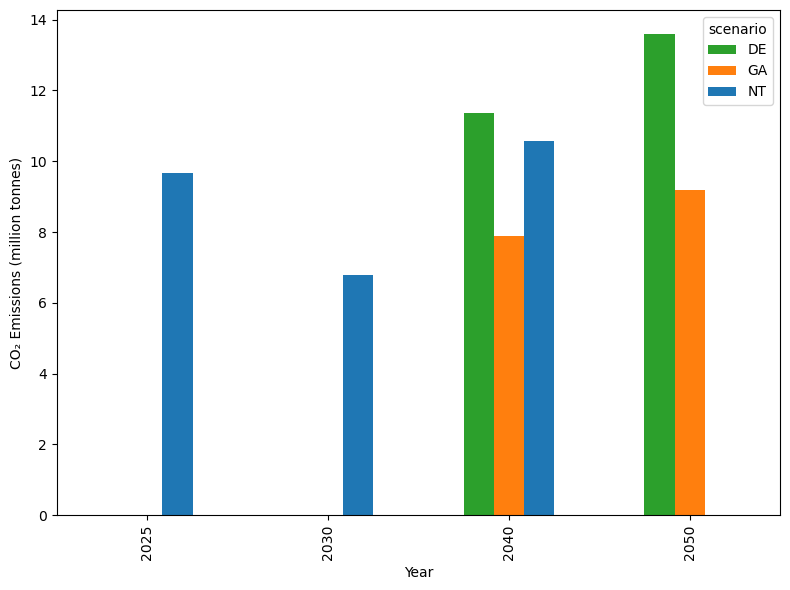

In [42]:
plot_co2_emissions_by_scenario(yearly_system_cost_table, savefolder=figures_folder)

In [43]:
def plot_co2_emissions_by_scenario(
    yearly_system_costs: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Grouped bar chart of CO₂ emissions by year, scenario, and average (million tonnes).
    """
    # Pivot without filling zeros
    df = yearly_system_costs["co2_emission"].unstack("scenario") / 1e6
    # Compute average across non-NaN values
    df["Average"] = df.mean(axis=1)
    # Prepare for plotting (fill NaN to avoid plot errors)
    df_plot = df.fillna(0)

    fig, ax = plt.subplots(figsize=(8, 6))
    df_plot.plot(kind="bar", ax=ax, color=[scenario_colors[s] for s in df_plot.columns])

    ax.set_xlabel("Year")
    ax.set_ylabel("CO₂ Emissions (million tonnes)")
    plt.tight_layout()
    print("CO₂ Emissions by Year, Scenario, and Average")
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "co2_emissions_by_scenario_avg.png"),
            bbox_inches="tight",
        )


def plot_production_by_scenario(
    yearly_system_costs: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Grouped bar chart of annual production by year, scenario, and average (TWh).
    """
    df = yearly_system_costs["production"].unstack("scenario") / 1e6
    df["Average"] = df.mean(axis=1)
    df_plot = df.fillna(0)

    fig, ax = plt.subplots(figsize=(8, 6))
    df_plot.plot(kind="bar", ax=ax, color=[scenario_colors[s] for s in df_plot.columns])

    ax.set_xlabel("Year")
    ax.set_ylabel("Annual Production (TWh)")
    plt.tight_layout()
    print("Annual Production by Year, Scenario, and Average")
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "production_by_scenario_avg.png"),
            bbox_inches="tight",
        )


def plot_production_cost_by_scenario(
    yearly_system_costs: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Grouped bar chart of production cost by year, scenario, and average (billion €).
    """
    df = yearly_system_costs["production_cost"].unstack("scenario") / 1e9
    df["Average"] = df.mean(axis=1)
    df_plot = df.fillna(0)

    fig, ax = plt.subplots(figsize=(8, 6))
    df_plot.plot(kind="bar", ax=ax, color=[scenario_colors[s] for s in df_plot.columns])

    ax.set_xlabel("Year")
    ax.set_ylabel("Production Cost (billion €)")
    plt.tight_layout()
    print("Production Cost by Year, Scenario, and Average")
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "production_cost_by_scenario_avg.png"),
            bbox_inches="tight",
        )


def plot_production_cost_with_emission_by_scenario(
    yearly_system_costs: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Grouped bar chart of production cost including emissions by year, scenario, and average (billion €).
    """
    df = yearly_system_costs["production_cost_with_emission"].unstack("scenario") / 1e9
    df["Average"] = df.mean(axis=1)
    df_plot = df.fillna(0)

    fig, ax = plt.subplots(figsize=(8, 6))
    df_plot.plot(kind="bar", ax=ax, color=[scenario_colors[s] for s in df_plot.columns])

    ax.set_xlabel("Year")
    ax.set_ylabel("Production Cost w/ Emission (billion €)")
    plt.tight_layout()
    print("Production Cost w/ Emissions by Year, Scenario, and Average")
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(
                savefolder, "production_cost_with_emission_by_scenario_avg.png"
            ),
            bbox_inches="tight",
        )

CO₂ Emissions by Year, Scenario, and Average


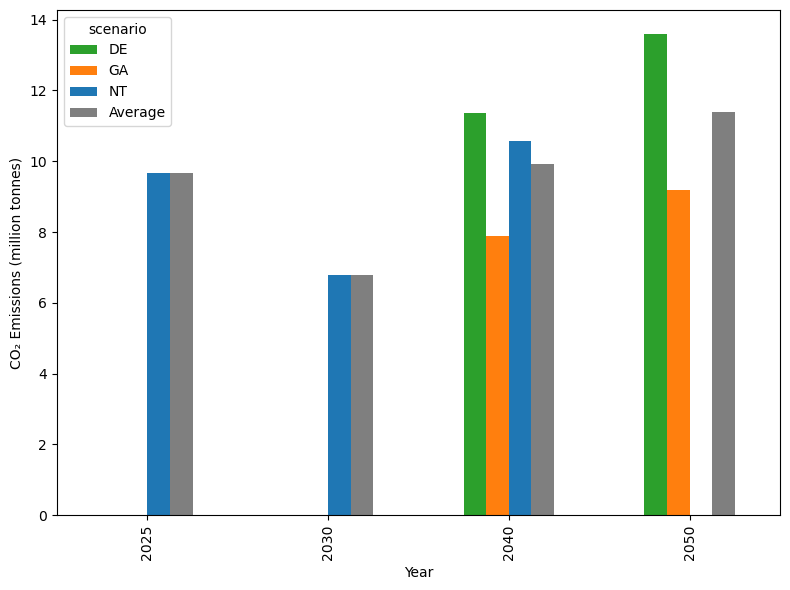

Annual Production by Year, Scenario, and Average


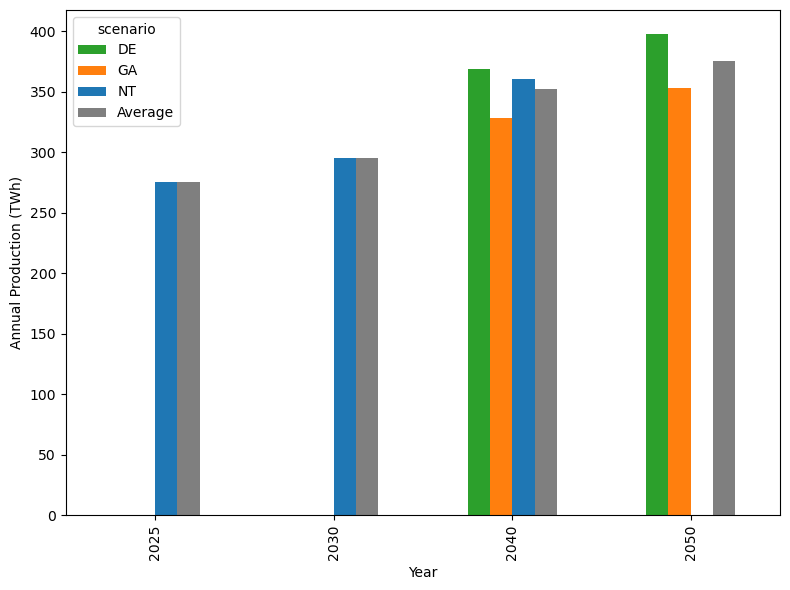

Production Cost by Year, Scenario, and Average


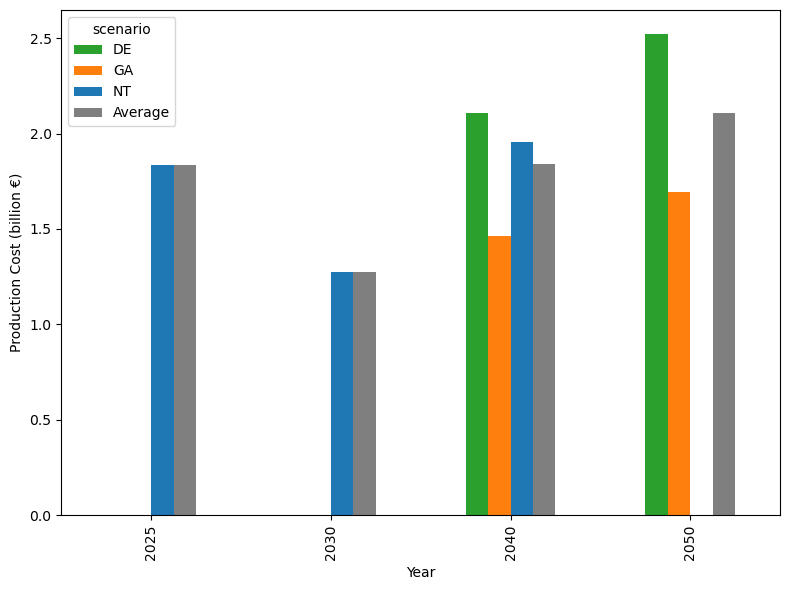

Production Cost w/ Emissions by Year, Scenario, and Average


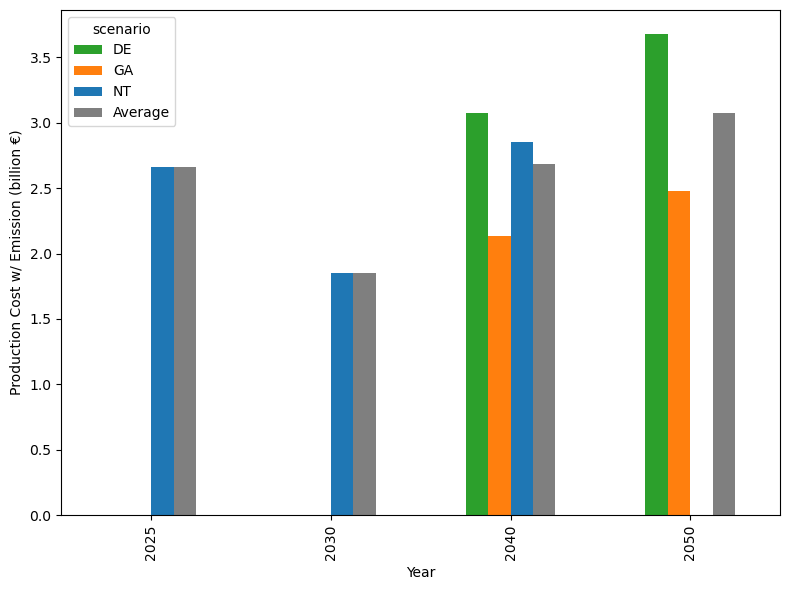

In [44]:
plot_co2_emissions_by_scenario(yearly_system_cost_table, figures_folder)
plot_production_by_scenario(yearly_system_cost_table, figures_folder)
plot_production_cost_by_scenario(yearly_system_cost_table, figures_folder)
plot_production_cost_with_emission_by_scenario(yearly_system_cost_table, figures_folder)

In [45]:
def plot_generation_curves_by_carrier(
    generation: pd.DataFrame,
    generators: pd.DataFrame,
    year: int,
    week: int,
    scenario: str,
    carrier_type: str,
    savefolder: str | None = None,
) -> None:
    """
    Plot hourly generation curves for all generators of a given carrier type
    in a specified year, week, and scenario.

    Parameters
    ----------
    generation : pd.DataFrame
        Hourly generation with MultiIndex
        (generator, scenario, year, week, hour) and a 'value' column.
    generators : pd.DataFrame
        Generator metadata with a 'carrier' and 'color' column,
        indexed by (year, generator) or with columns 'year' and 'generator'.
    year : int
        Year to plot.
    week : int
        Week number to plot.
    scenario : str
        Scenario name to plot.
    carrier_type : str
        Carrier (technology) whose generators to include.
    savefolder : str or None
        Directory to save the figure. If None, figure is not saved.
    """
    # find all generators of this carrier in that year
    meta = generators.reset_index()
    gens = meta.loc[
        (meta["year"] == year) & (meta["carrier"] == carrier_type), "generator"
    ].unique()
    if len(gens) == 0:
        print(f"No generators of carrier {carrier_type} in {year}")
        return

    # build a DataFrame of hours × generators
    dfs = []
    for g in gens:
        try:
            ser = generation.xs(
                (g, scenario, year, week),
                level=("generator", "scenario", "year", "week"),
            )["value"]
        except KeyError:
            continue
        dfs.append(ser.rename(g))
    if not dfs:
        print(
            f"No generation data for {carrier_type} in {year}, week {week}, scenario {scenario}"
        )
        return
    df = pd.concat(dfs, axis=1)

    # plot
    fig, ax = plt.subplots(figsize=(8, 4))
    for gen in df.columns:
        # use the color from the generators table
        color = meta.loc[
            (meta["year"] == year) & (meta["generator"] == gen), "color"
        ].iloc[0]
        ax.plot(df.index, df[gen], label=gen, color=color)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Generation (MW)")
    title = f"Generation curves for {carrier_type}, {year}, week {week}, scenario {scenario}"
    print(title)
    plt.tight_layout()
    ax.legend(title="Generator", bbox_to_anchor=(1.02, 1), loc="upper left")

    if savefolder:
        fname = f"gen_curves_{carrier_type}_{year}_w{week}_{scenario}.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")
    plt.show()

In [46]:
# # Example loop over years, weeks, scenarios, and carrier types
# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# carriers = generators.reset_index()["carrier"].unique()
# if figures_folder:
#     generation_curves_folder = os.path.join(figures_folder, "generation_curves")
#     os.makedirs(generation_curves_folder, exist_ok=True)
# else:
#     generation_curves_folder = None

# for year in years:
#     for scenario in scenarios[str(year)]:
#         for week in weeks:
#             for carrier in carriers:
#                 plot_generation_curves_by_carrier(
#                     generation,
#                     generators,
#                     year,
#                     week,
#                     scenario,
#                     carrier,
#                     savefolder=generation_curves_folder,  # or None if you don’t want to save
# )

In [47]:
def plot_fraction_of_max_generation_by_carrier(
    generation: pd.DataFrame,
    capacity_factors: pd.DataFrame,
    generators: pd.DataFrame,
    year: int,
    week: int,
    scenario: str,
    carrier_type: str,
    savefolder: str | None = None,
) -> None:
    """
    Plot, for a given carrier type, the hourly fraction:
      actual_generation / (total_capacity * capacity_factor)
    in a specified year, week, and scenario.

    Parameters
    ----------
    generation : pd.DataFrame
        Hourly generation with MultiIndex
        (generator, scenario, year, week, hour) and a 'value' column (MWh).
    capacity_factors : pd.DataFrame
        Hourly capacity factors with MultiIndex (year, week, hour)
        and columns = generator names (values in [0,1]).
    generators : pd.DataFrame
        Generator table indexed by (year, generator) with columns:
        - total_capacity (MW)
        - color
    year : int
    week : int
    scenario : str
    carrier_type : str
    savefolder : str | None
    """
    # 1) Identify all generators of this carrier in that year
    meta = generators.reset_index()
    gens = meta.loc[
        (meta["year"] == year) & (meta["carrier"] == carrier_type), "generator"
    ].unique()
    if len(gens) == 0:
        print(f"No generators of carrier {carrier_type} in {year}")
        return

    # 2) Slice capacity factors for this year & week
    cf_slice = capacity_factors.xs((year, week), level=("year", "week"))

    # 3) Plot each generator’s fraction curve
    fig, ax = plt.subplots(figsize=(8, 4))
    for g in gens:
        # a) actual generation series
        try:
            gen_ser = generation.xs(
                (g, scenario, year, week),
                level=("generator", "scenario", "year", "week"),
            )["value"]
        except KeyError:
            continue

        # b) capacity‐factor series
        if g not in cf_slice.columns:
            continue
        cf_ser = cf_slice[g]

        # c) total installed capacity
        total_cap = generators.loc[(year, g), "total_capacity"]

        # d) theoretical max = total_capacity * cf
        theo = total_cap * cf_ser.values

        # e) fraction (guard divide‐by‐zero)
        with np.errstate(divide="ignore", invalid="ignore"):
            frac = gen_ser.values / theo

        # f) plot
        color = meta.loc[
            (meta["year"] == year) & (meta["generator"] == g), "color"
        ].iloc[0]
        ax.plot(gen_ser.index, frac, label=g, color=color)

    ax.set_xlabel("Hour")
    ax.set_ylabel("Fraction of Theoretical Max")
    print(
        f"Fraction of actual vs theoretical for {carrier_type}, {year}, w{week}, {scenario}"
    )
    plt.tight_layout()
    ax.legend(title="Generator", bbox_to_anchor=(1.02, 1), loc="upper left")

    # 4) Save if requested
    if savefolder:
        fname = f"fraction_gen_{carrier_type}_{year}_w{week}_{scenario}.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")
    plt.show()

In [48]:
# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# carriers = generators.reset_index()["carrier"].unique()

# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             for carrier in carriers:
#                 plot_fraction_of_max_generation_by_carrier(
#                     generation,
#                     capacity_factors,
#                     generators,
#                     year,
#                     week,
#                     scen,
#                     carrier,
#                     savefolder=generation_curves_folder,  # or None if you don’t want to save
#                 )

In [49]:
def plot_utilization_time_series_by_carrier(
    generation: pd.DataFrame,
    capacity_factors: pd.DataFrame,
    generators: pd.DataFrame,
    year: int,
    week: int,
    scenario: str,
    savefolder: str | None = None,
) -> None:
    """
    Plot hourly utilization factor time series for each carrier in a given year/week/scenario.

    Utilization factor = sum_actual_gen_by_carrier_hour / sum_total_capacity*cf_by_carrier_hour

    Parameters
    ----------
    generation : pd.DataFrame
        Hourly generation with MultiIndex
        (generator, scenario, year, week, hour) and 'value' column (MWh).
    capacity_factors : pd.DataFrame
        Hourly capacity factors with MultiIndex (year, week, hour),
        columns are generator names, values in [0,1].
    generators : pd.DataFrame
        Generator table indexed by (year, generator) with:
        - total_capacity (MW)
        - carrier
        - color
    year : int
    week : int
    scenario : str
    savefolder : str or None
    """
    # metadata for this year
    meta = generators.reset_index()
    year_meta = meta[meta["year"] == year]
    # carriers to plot
    carriers = year_meta["carrier"].unique()

    # slice generation for this scenario-year-week; pivot to hour×generator
    gen_slice = generation.xs(
        (scenario, year, week), level=("scenario", "year", "week")
    )["value"]
    gen_df = gen_slice.unstack("generator").fillna(0)

    # slice capacity_factors for this year-week
    cf_slice = capacity_factors.xs((year, week), level=("year", "week")).fillna(0)

    # compute potential: cf * total_capacity
    cap_series = year_meta.set_index("generator")["total_capacity"]
    potential_df = cf_slice.multiply(cap_series, axis=1)

    # prepare plot
    fig, ax = plt.subplots(figsize=(10, 6))
    for carrier in carriers:
        # generators of this carrier
        gens = year_meta[year_meta["carrier"] == carrier]["generator"]
        if len(gens) == 0:
            continue
        # sum actual & potential by hour
        actual_hour = gen_df[gens].sum(axis=1)
        potential_hour = potential_df[gens].sum(axis=1)
        # util factor (guard div0)
        util = actual_hour / potential_hour.replace({0: np.nan})
        # plot
        color = year_meta[year_meta["carrier"] == carrier]["color"].iloc[0]
        label = year_meta[year_meta["carrier"] == carrier]["nice_name"].iloc[0]
        ax.plot(util.index, util.values, label=label, color=color)

    ax.set_xlabel("Hour")
    ax.set_ylabel("Utilization Factor")
    fig.subplots_adjust(right=0.75)
    ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")
    print(
        f"Hourly utilization factor by carrier: {year}, week {week}, scenario {scenario}"
    )
    plt.tight_layout()
    plt.show()

    if savefolder:
        fname = f"util_factors_time_series_{year}_w{week}_{scenario}.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")


# # loop over combinations
# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             plot_utilization_time_series_by_carrier(
#                 generation,
#                 capacity_factors,
#                 generators,
#                 year,
#                 week,
#                 scen,
#                 savefolder=tables_folder,
#             )

In [50]:
def plot_utilization_hierarchy(
    generation: pd.DataFrame,
    capacity_factors: pd.DataFrame,
    generators: pd.DataFrame,
    week_weights: dict[str, float],
    scenarios: dict[str, list[str]],
    savefolder: str | None = None,
) -> None:
    """
    Grouped bar chart of annual utilization factor by technology, with a 3‐level x‐axis:
      Year → Scenario → Carrier.

    Utilization factor = total actual generation / total possible generation
    (i.e. sum(actual_gen) ÷ sum(total_capacity * capacity_factor)).

    Parameters
    ----------
    generation : pd.DataFrame
        Hourly generation with MultiIndex (generator, scenario, year, week, hour)
        and a 'value' column in MWh.
    capacity_factors : pd.DataFrame
        Hourly capacity factors with MultiIndex (year, week, hour)
        and columns = generator names.
    generators : pd.DataFrame
        Generator table indexed by (year, generator) with columns:
        - total_capacity (MW)
        - carrier
        - nice_name
        - color
    week_weights : dict[str, float]
        Multipliers to annualize each sample week.
    scenarios : dict[str, list[str]]
        Mapping year→list of scenarios.
    savefolder : str or None
        Directory to save the figure. If None, figure is not saved.
    """
    # 1) Annual actual generation per generator-scenario-year
    weekly = (
        generation.groupby(["generator", "scenario", "year", "week"])["value"]
        .sum()
        .reset_index(name="weekly_gen")
    )
    weekly["weight"] = weekly["week"].map(lambda w: week_weights[str(w)])
    weekly["annual_actual"] = weekly["weekly_gen"] * weekly["weight"]
    actual = (
        weekly.groupby(["year", "scenario", "generator"])["annual_actual"]
        .sum()
        .unstack("generator")
        .fillna(0)
    )

    # 2) Annual possible generation per generator-year
    # sum capacity_factors over hours per sample week
    cf_weekly = capacity_factors.groupby(level=["year", "week"]).sum()
    # build weight series, index as ints
    weight_s = pd.Series(week_weights).rename_axis("week").astype(float)
    weight_s.index = weight_s.index.astype(int)
    # multiply by week weight via alignment on 'week' level
    weighted_cf = cf_weekly.multiply(weight_s, level="week", axis=0)
    # sum over weeks to annualize
    annual_cf = weighted_cf.groupby(level="year").sum()

    # total installed capacity per year×generator
    cap_df = generators["total_capacity"].unstack(level="generator")

    # potential generation = annual_cf * capacity
    potential = annual_cf * cap_df

    # 3) Map generator→carrier and aggregate
    gen2car = (
        generators.reset_index()[["generator", "carrier"]]
        .drop_duplicates("generator")
        .set_index("generator")["carrier"]
    )
    actual_car = actual.groupby(gen2car, axis=1).sum()  # (year,scenario)×carrier
    potential_car = potential.groupby(gen2car, axis=1).sum()  # year×carrier

    # 4) Compute utilization factor per (year,scenario,carrier)
    util = actual_car.div(potential_car, level="year").stack().unstack("carrier")

    # 5) Plot
    carriers = util.columns.tolist()
    meta = (
        generators.reset_index()[["carrier", "nice_name", "color"]]
        .drop_duplicates("carrier")
        .set_index("carrier")
    )
    colors = [meta.loc[c, "color"] for c in carriers]
    labels = [meta.loc[c, "nice_name"] for c in carriers]

    idx = list(util.index)  # list of (year,scenario)
    n_groups = len(idx)
    n_car = len(carriers)
    width = 0.8 / n_car
    base = np.arange(n_groups)

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, carrier in enumerate(carriers):
        x = base + (i - (n_car - 1) / 2) * width
        ax.bar(x, util[carrier].values, width=width, color=colors[i], label=labels[i])

    tick_labels = [f"{yr}\n{sc}" for yr, sc in idx]
    ax.set_xticks(base)
    ax.set_xticklabels(tick_labels, rotation=0)
    ax.set_xlabel("Year / Scenario")
    ax.set_ylabel("Utilization Factor")

    fig.subplots_adjust(right=0.85)
    ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    print("Annual Utilization Factor by Year, Scenario, and Carrier")
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "utilization_hierarchy.png"), bbox_inches="tight"
        )

Annual Utilization Factor by Year, Scenario, and Carrier


C:\Users\tinus\AppData\Local\Temp\ipykernel_25220\4061216466.py:75: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  actual_car = actual.groupby(gen2car, axis=1).sum()  # (year,scenario)×carrier
C:\Users\tinus\AppData\Local\Temp\ipykernel_25220\4061216466.py:76: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  potential_car = potential.groupby(gen2car, axis=1).sum()  # year×carrier


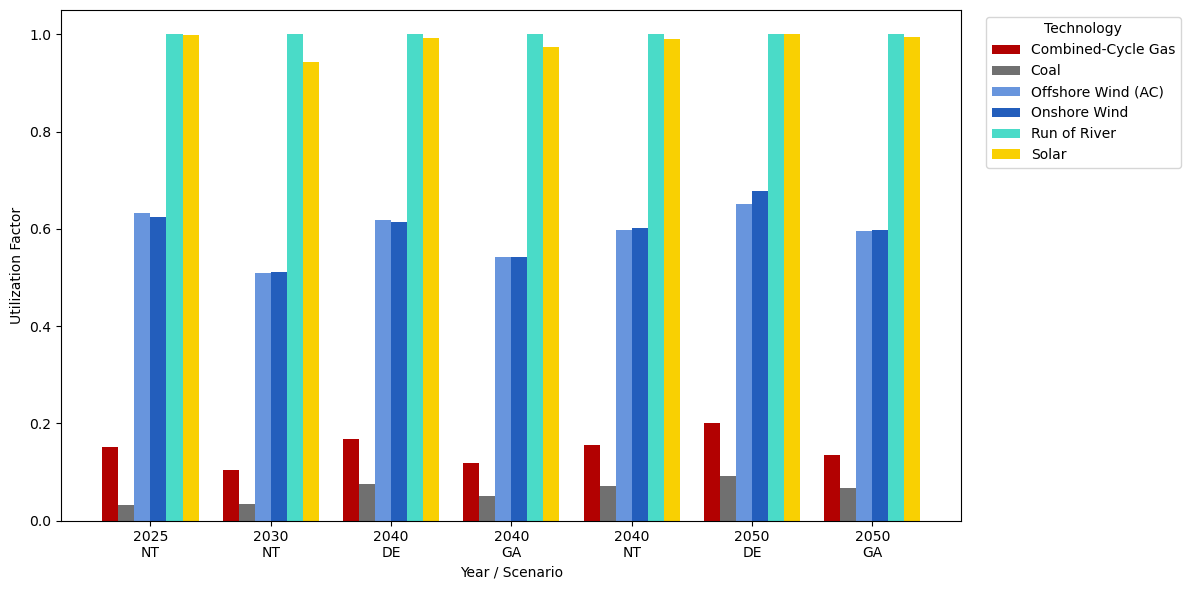

In [51]:
plot_utilization_hierarchy(
    generation, capacity_factors, generators, week_weights, scenarios, figures_folder
)

In [52]:
def make_system_summary_table(
    generation: pd.DataFrame,
    generators: pd.DataFrame,
    week_weights: dict[str, float],
    scenarios: dict[str, list[str]],
    scenario_probabilities: dict[str, list[float]],
    carbon_price: float,
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Build a system‐level summary table by year with columns:
      - potential_capacity                  (MW)
      - new_capacity                        (MW added)
      - number_possible_buildouts           (count of gens with extension_potential>0)
      - number_actual_buildouts             (count of gens with new_capacity>0)
      - cost_of_buildout                    (EUR)
      - total_production                    (expected MWh)
      - total_co2_emissions                 (expected tonnes)
      - total_co2_emission_cost             (EUR)
      - total_production_cost               (EUR, excl CO₂)
      - total_production_cost_with_emission (EUR)
      - total_cost                          (EUR; prod_cost_with_emission + buildout)
    """
    # --- Buildout metrics (per year) ---
    df_gen = generators.reset_index()
    df_gen["buildout_cost"] = df_gen["new_capacity"] * df_gen["capital_cost"]
    build_metrics = df_gen.groupby("year").agg(
        potential_capacity=("extension_potential", "sum"),
        new_capacity=("new_capacity", "sum"),
        number_possible_buildouts=("extension_potential", lambda x: (x > 0).sum()),
        number_actual_buildouts=("new_capacity", lambda x: (x > 0).sum()),
        cost_of_buildout=("buildout_cost", "sum"),
    )

    # --- Scenario probabilities DataFrame ---
    scen_rows = []
    for y_str, scen_list in scenarios.items():
        y = int(y_str)
        for scen, prob in zip(scen_list, scenario_probabilities[y_str]):
            scen_rows.append({"year": y, "scenario": scen, "probability": prob})
    prob_df = pd.DataFrame(scen_rows)

    # --- Generation metrics (per gen‐scen‐year) ---
    weekly = (
        generation.groupby(["generator", "scenario", "year", "week"])["value"]
        .sum()
        .reset_index(name="weekly_gen")
    )
    weekly["weight"] = weekly["week"].astype(str).map(week_weights)
    weekly["annual_gen"] = weekly["weekly_gen"] * weekly["weight"]
    annual = (
        weekly.groupby(["generator", "scenario", "year"])["annual_gen"]
        .sum()
        .reset_index()
    )

    # Merge in marginal_cost & co2_emissions
    meta = generators.reset_index()[
        ["year", "generator", "marginal_cost", "co2_emissions"]
    ].drop_duplicates(["year", "generator"])
    annual = annual.merge(meta, on=["year", "generator"], how="left")

    # Compute per‐gen metrics
    annual["production"] = annual["annual_gen"]
    annual["co2_emission"] = annual["annual_gen"] * annual["co2_emissions"]
    annual["production_cost"] = annual["annual_gen"] * annual["marginal_cost"]
    annual["co2_emission_cost"] = annual["co2_emission"] * carbon_price
    annual["production_cost_with_emission"] = (
        annual["production_cost"] + annual["co2_emission_cost"]
    )

    # Merge probabilities, weight and collapse to year
    annual = annual.merge(prob_df, on=["year", "scenario"], how="left")
    for col in [
        "production",
        "co2_emission",
        "co2_emission_cost",
        "production_cost",
        "production_cost_with_emission",
    ]:
        annual[f"w_{col}"] = annual[col] * annual["probability"]

    gen_metrics = annual.groupby("year")[
        [
            f"w_{c}"
            for c in [
                "production",
                "co2_emission",
                "co2_emission_cost",
                "production_cost",
                "production_cost_with_emission",
            ]
        ]
    ].sum()
    gen_metrics.columns = [
        "total_production",
        "total_co2_emissions",
        "total_co2_emission_cost",
        "total_production_cost",
        "total_production_cost_with_emission",
    ]

    # --- Combine and compute final ---
    summary = build_metrics.join(gen_metrics)
    summary["total_cost"] = (
        summary["total_production_cost_with_emission"] + summary["cost_of_buildout"]
    )

    # optional save
    if savefolder:
        path = os.path.join(savefolder, "system_summary_by_year.csv")
        summary.to_csv(path)

    return summary

In [53]:
summary_table = make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=tables_folder,
)

In [54]:
summary_table

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,192912.81714,76972.204833,51,22,7.447474e+09,2.752853e+08,9.678730e+06,8.226920e+08,1.835395e+09,2.658087e+09,1.010556e+10
2030,192912.81714,42286.805568,51,14,3.126891e+09,2.954154e+08,6.798705e+06,5.778899e+08,1.272858e+09,1.850748e+09,4.977639e+09
2040,192912.81714,9685.035458,51,2,8.084783e+08,3.522563e+08,9.932408e+06,8.442546e+08,1.842124e+09,2.686379e+09,3.494857e+09
2050,192912.81714,0.000000,51,0,0.000000e+00,3.750901e+08,1.139395e+07,9.684856e+08,2.107360e+09,3.075846e+09,3.075846e+09


In [55]:
def make_system_summary_table_by_carrier(
    generation: pd.DataFrame,
    generators: pd.DataFrame,
    week_weights: dict[str, float],
    scenarios: dict[str, list[str]],
    scenario_probabilities: dict[str, list[float]],
    carbon_price: float,
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Build a system‐level summary table by year and carrier with columns:
      - potential_capacity                  (MW)
      - new_capacity                        (MW added)
      - number_possible_buildouts           (count of gens with extension_potential>0)
      - number_actual_buildouts             (count of gens with new_capacity>0)
      - cost_of_buildout                    (EUR)
      - total_production                    (expected MWh)
      - total_co2_emissions                 (expected tonnes)
      - total_co2_emission_cost             (EUR)
      - total_production_cost               (EUR, excl CO₂)
      - total_production_cost_with_emission (EUR)
      - total_cost                          (EUR; production_cost_with_emission + buildout)
    """
    # --- Buildout metrics per year & carrier ---
    df_gen = generators.reset_index()
    df_gen["buildout_cost"] = df_gen["new_capacity"] * df_gen["capital_cost"]
    build_metrics = df_gen.groupby(["year", "carrier"]).agg(
        potential_capacity=("extension_potential", "sum"),
        new_capacity=("new_capacity", "sum"),
        number_possible_buildouts=("extension_potential", lambda x: (x > 0).sum()),
        number_actual_buildouts=("new_capacity", lambda x: (x > 0).sum()),
        cost_of_buildout=("buildout_cost", "sum"),
    )

    # --- Scenario probabilities DataFrame ---
    scen_rows = []
    for y_str, scen_list in scenarios.items():
        y = int(y_str)
        for scen, prob in zip(scen_list, scenario_probabilities[y_str]):
            scen_rows.append({"year": y, "scenario": scen, "probability": prob})
    prob_df = pd.DataFrame(scen_rows)

    # --- Generation metrics per generator / scenario / year ---
    weekly = (
        generation.groupby(["generator", "scenario", "year", "week"])["value"]
        .sum()
        .reset_index(name="weekly_gen")
    )
    weekly["weight"] = weekly["week"].astype(str).map(week_weights)
    weekly["annual_gen"] = weekly["weekly_gen"] * weekly["weight"]
    annual = (
        weekly.groupby(["generator", "scenario", "year"])["annual_gen"]
        .sum()
        .reset_index()
    )

    # attach cost & emissions rates and carrier
    meta = generators.reset_index()[
        ["year", "generator", "marginal_cost", "co2_emissions", "carrier"]
    ].drop_duplicates(["year", "generator"])
    annual = annual.merge(meta, on=["year", "generator"], how="left")

    # compute per‐generator metrics
    annual["production"] = annual["annual_gen"]
    annual["co2_emission"] = annual["annual_gen"] * annual["co2_emissions"]
    annual["production_cost"] = annual["annual_gen"] * annual["marginal_cost"]
    annual["co2_emission_cost"] = annual["co2_emission"] * carbon_price
    annual["production_cost_with_emission"] = (
        annual["production_cost"] + annual["co2_emission_cost"]
    )

    # merge probabilities and compute weighted metrics
    annual = annual.merge(prob_df, on=["year", "scenario"], how="left")
    for col in [
        "production",
        "co2_emission",
        "production_cost",
        "co2_emission_cost",
        "production_cost_with_emission",
    ]:
        annual[f"w_{col}"] = annual[col] * annual["probability"]

    gen_metrics = annual.groupby(["year", "carrier"])[
        [
            f"w_{c}"
            for c in [
                "production",
                "co2_emission",
                "production_cost",
                "co2_emission_cost",
                "production_cost_with_emission",
            ]
        ]
    ].sum()
    gen_metrics.columns = [
        "total_production",
        "total_co2_emissions",
        "total_production_cost",
        "total_co2_emission_cost",
        "total_production_cost_with_emission",
    ]

    # --- Combine buildout & generation metrics ---
    summary = build_metrics.join(gen_metrics)
    summary["total_cost"] = (
        summary["total_production_cost_with_emission"] + summary["cost_of_buildout"]
    )

    # optional save
    if savefolder:
        path = os.path.join(savefolder, "system_summary_by_year_and_carrier.csv")
        summary.to_csv(path)

    return summary

In [56]:
summary_by_carrier_table = make_system_summary_table_by_carrier(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    tables_folder,
)
summary_by_carrier_table

potential_capacity  new_capacity  number_possible_buildouts  \
year carrier                                                                   
2025 CCGT              60900.664000   4464.906949                         11   
     coal               9478.786965      0.000000                          5   
     offwind-ac        27469.304444   5750.206760                          9   
     onwind            64079.006689  36066.052577                         11   
     ror                5571.016495   5277.000000                          4   
     solar             25414.038546  25414.038546                         11   
2030 CCGT              60900.664000      0.000000                         11   
     coal               9478.786965      0.000000                          5   
     offwind-ac        27469.304444   3638.183698                          9   
     onwind            64079.006689  16021.999255                         11   
     ror                5571.016495    426.070288                          4   
     solar             25414.038546  22200.552327                         11   
2040 CCGT              60900.664000      0.000000                         11   
     coal               9478.786965      0.000000                          5   
     offwind-ac        27469.304444      0.000000                          9   
     onwind            64079.006689   7666.034392                         11   
     ror                5571.016495      0.000000                          4   
     solar             25414.038546   2019.001067                         11   
2050 CCGT              60900.664000      0.000000                         11   
     coal               9478.786965      0.000000                          5   
     offwind-ac        27469.304444      0.000000                          9   
     onwind            64079.006689      0.000000                         11   
     ror                5571.016495      0.000000                          4   
     solar             25414.038546      0.000000                         11   

                 number_actual_buildouts  cost_of_buildout  total_production  \
year carrier                                                                   
2025 CCGT                              1      4.421496e+08      4.612881e+07   
     coal                              0      0.000000e+00      1.332259e+06   
     offwind-ac                        2      1.056531e+09      3.582265e+07   
     onwind                            6      3.465439e+09      1.030797e+08   
     ror                               2      1.578563e+09      3.739784e+07   
     solar                            11      9.047924e+08      5.152404e+07   
2030 CCGT                              0      0.000000e+00      3.157218e+07   
     coal                              0      0.000000e+00      1.424320e+06   
     offwind-ac                        1      6.695623e+08      3.651292e+07   
     onwind                            2      1.539488e+09      1.086381e+08   
     ror                               1      1.274548e+08      3.938636e+07   
     solar                            10      7.903856e+08      7.788148e+07   
2040 CCGT                              0      0.000000e+00      4.504883e+07   
     coal                              0      0.000000e+00      2.713651e+06   
     offwind-ac                        0      0.000000e+00      4.197947e+07   
     onwind                            1      7.365977e+08      1.388627e+08   
     ror                               0      0.000000e+00      3.938636e+07   
     solar                             1      7.188062e+07      8.426533e+07   
2050 CCGT                              0      0.000000e+00      5.139102e+07   
     coal                              0      0.000000e+00      3.281600e+06   
     offwind-ac                        0      0.000000e+00      4.468682e+07   
     onwind                            0      0.000000e+00      1.510595e+08   
     ror        

## Transmission Lines

In [57]:
# Preprocessing
if "extended_by" in branches.columns:
    branches.drop(columns=["extended_by"], inplace=True)
if "branch" in branch_capacity.index.names:
    branch_capacity = branch_capacity.rename_axis(index={"branch": "line"})
if "branch" in power_flow.index.names:
    power_flow = power_flow.rename_axis(index={"branch": "line"})
branches["extension_potential"] = p_max_new_branch

In [58]:
branches

bus0   bus1         p_max  capital_cost      length  loss_factor  \
year line                                                                      
2025 88    ES1 0  ES1 3   2189.658631  23102.962586  449.297989     0.017250   
     89    ES1 0  ES1 6   6568.975893  11729.199350  228.105190     0.008758   
     90    ES1 1  ES1 2   8043.643950  16201.400425  315.078925     0.012097   
     91    ES1 1  ES1 4   7775.522485  22150.028030  430.765665     0.016539   
     92    ES1 1  ES1 5   1698.102612  19884.672096  386.709849     0.014847   
...          ...    ...           ...           ...         ...          ...   
2050 104   ES1 5  ES1 6   8758.634524  16188.029800  314.818898     0.012087   
     105   ES1 5  ES1 7  25024.670068  12467.493385  242.463263     0.009309   
     106   ES1 7  PT1 0   3172.770669  13131.503581  255.376691     0.009805   
     107   ES1 7  PT1 1   1698.102612  22061.025373  429.034774     0.016472   
     219   PT1 0  PT1 1  11707.970639  14480.882016  281.618911     0.010812   

           extendable  extension_potential  
year line                                   
2025 88          True                 5000  
     89          True                 5000  
     90          True                 5000  
     91          True                 5000  
     92          True                 5000  
...               ...                  ...  
2050 104         True                 5000  
     105         True                 5000  
     106         True                 5000  
     107         True                 5000  
     219         True                 5000  

[76 rows x 8 columns]

In [59]:
def extend_branches_table(
    branches: pd.DataFrame, branch_capacity: pd.DataFrame
) -> pd.DataFrame:
    """
    Add investment and capacity‐growth columns to the branches DataFrame.

    Parameters
    ----------
    branches : pd.DataFrame
        MultiIndexed by (year, line) with columns:
        - p_max
        - capital_cost
        - length
        - loss_factor
        - extendable
        - extension_potential
    branch_capacity : pd.DataFrame
        MultiIndexed by (line, year) with a 'value' column of new MW built.

    Returns
    -------
    pd.DataFrame
        branches with four new columns:
        - new_capacity                (MW added in that year)
        - cum_new_capacity            (cumulative MW added over time)
        - cum_extension_potential     (cumulative extension potential over time)
        - total_capacity              (existing p_max + cum_new_capacity)
    """
    # 1. Flatten indices for merging
    b = branches.reset_index()  # columns: year, line, p_max, …
    cap = branch_capacity.reset_index()  # columns: line, year, value

    # 2. Rename and merge new capacity
    cap = cap.rename(columns={"value": "new_capacity"})
    merged = b.merge(
        cap[["year", "line", "new_capacity"]], on=["year", "line"], how="left"
    )

    # 3. Sort for cumulative calculations
    merged = merged.sort_values(["line", "year"])

    # 4. Compute cumulative sums by line
    merged["cum_new_capacity"] = merged.groupby("line")["new_capacity"].cumsum()
    merged["cum_extension_potential"] = merged.groupby("line")[
        "extension_potential"
    ].cumsum()

    # 5. Total capacity = original + cumulative additions
    merged["total_capacity"] = merged["p_max"] + merged["cum_new_capacity"]

    # 6. Restore MultiIndex
    return merged.set_index(["year", "line"])

In [60]:
branches = extend_branches_table(branches, branch_capacity)

In [61]:
def plot_branch_new_capacity(
    branches: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Plot a bar chart of annual new branch capacity additions.

    Parameters
    ----------
    branches : pd.DataFrame
        DataFrame indexed by (year, line) containing a 'new_capacity' column (MW added).
    savefolder : str or None, optional
        Directory to save the figure. If None, the figure is not saved.
    """
    # Aggregate new_capacity by year
    temp = branches.reset_index()
    annual_new = temp.groupby("year")["new_capacity"].sum()

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(annual_new.index.astype(str), annual_new.values)
    ax.set_xlabel("Year")
    ax.set_ylabel("New Capacity (MW)")
    plt.tight_layout()

    # Print title line
    print("Annual New Branch Capacity Additions")
    plt.show()

    # Save if requested
    if savefolder:
        savepath = os.path.join(savefolder, "branch_new_capacity_by_year.png")
        fig.savefig(savepath, bbox_inches="tight")

Annual New Branch Capacity Additions


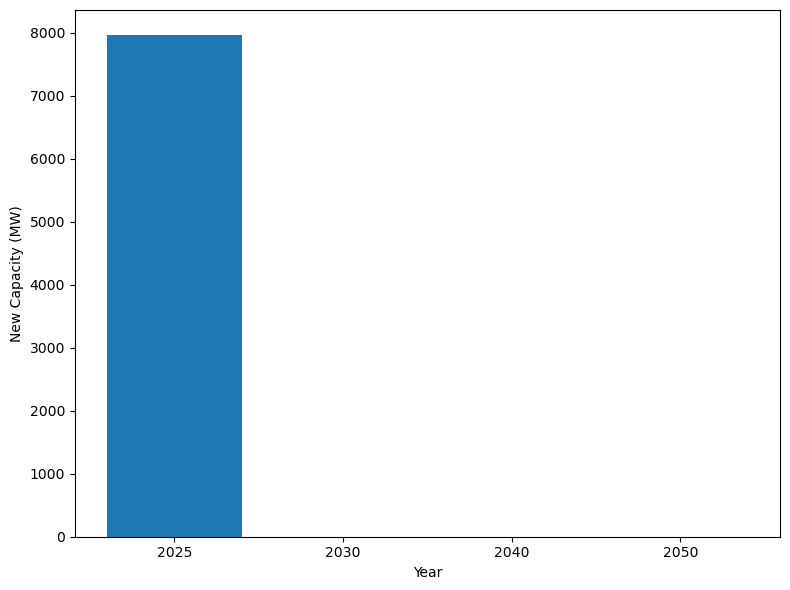

In [62]:
plot_branch_new_capacity(branches, figures_folder)

In [63]:
def make_branch_buildout_summary(
    extended_branches: pd.DataFrame, savefolder: str | None = None
) -> pd.DataFrame:
    """
    Compute yearly branch buildout metrics:
      - potential_capacity           (MW of extension_potential)
      - new_capacity                 (MW added)
      - number_possible_buildouts    (count of lines with extension_potential > 0)
      - number_actual_buildouts      (count of lines with new_capacity > 0)
      - cost_of_buildout             (EUR of new_capacity * capital_cost)

    Parameters
    ----------
    extended_branches : pd.DataFrame
        DataFrame indexed by (year, line) containing columns:
        - extension_potential
        - new_capacity
        - capital_cost
    savefolder : str or None, optional
        Directory to save CSV. If None, does not save.

    Returns
    -------
    pd.DataFrame
        Yearly summary table with the above buildout metrics.
    """
    df = extended_branches.reset_index()
    df["buildout_cost"] = df["new_capacity"] * df["capital_cost"]

    summary = df.groupby("year").agg(
        potential_capacity=("extension_potential", "sum"),
        new_capacity=("new_capacity", "sum"),
        number_possible_buildouts=("extension_potential", lambda x: (x > 0).sum()),
        number_actual_buildouts=("new_capacity", lambda x: (x > 0).sum()),
        cost_of_buildout=("buildout_cost", "sum"),
    )

    print("Branch buildout summary by year:")
    display(summary)

    if savefolder:
        path = os.path.join(savefolder, "branch_buildout_summary_by_year.csv")
        summary.to_csv(path)

    return summary

In [64]:
branch_buildout_summary = make_branch_buildout_summary(branches, tables_folder)
branch_buildout_summary

Branch buildout summary by year:


,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,7964.494407,19,2,1.341461e+08
2030,95000,0.000000,19,0,0.000000e+00
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,7964.494407,19,2,1.341461e+08
2030,95000,0.000000,19,0,0.000000e+00
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


In [65]:
def make_branch_flow_metrics(
    power_flow: pd.DataFrame,
    extended_branches: pd.DataFrame,
    week_weights: dict[str, float],
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Compute per‐line, per‐scenario, per‐year utilization and congestion rates.

    Utilization rate = annualized sum(|flow|) / (total_capacity * hours_per_year)
    Congestion rate = annualized hours(|flow| > 95% * total_capacity) / hours_per_year

    Parameters
    ----------
    power_flow : pd.DataFrame
        MultiIndexed by (line, scenario, year, week, hour) with column 'value' (MW flow).
    extended_branches : pd.DataFrame
        Indexed by (year, line) with column 'total_capacity' (MW).
    week_weights : dict[str, float]
        Mapping week → weight to annualize one representative week.
    savefolder : str or None
        Directory to save CSV. If None, does not save.

    Returns
    -------
    pd.DataFrame
        Indexed by (line, scenario, year) with columns:
        - utilization_rate   (fraction of capacity‐hours used)
        - congestion_rate    (fraction of hours > 95% flow)
    """
    # total hours in year from sample weeks
    hours_per_week = 168
    total_hours = sum(week_weights.values()) * hours_per_week

    # flatten power_flow
    pf = power_flow.reset_index().rename(columns={"value": "flow"})
    # absolute flow and week weight
    pf["abs_flow"] = pf["flow"].abs()
    pf["weight"] = pf["week"].astype(str).map(week_weights)

    # merge in total_capacity
    tb = extended_branches.reset_index()[["year", "line", "total_capacity"]]
    pf = pf.merge(tb, on=["year", "line"], how="left")

    # annualized absolute energy (MWh) and congested hours
    pf["weighted_abs_energy"] = pf["abs_flow"] * pf["weight"]
    pf["is_congested"] = pf["abs_flow"] > 0.95 * pf["total_capacity"]
    pf["weighted_cong_hours"] = pf["is_congested"] * pf["weight"]

    # aggregate
    grp = pf.groupby(["line", "scenario", "year"]).agg(
        abs_energy=("weighted_abs_energy", "sum"),
        cong_hours=("weighted_cong_hours", "sum"),
        total_capacity=("total_capacity", "first"),
    )

    # compute rates
    grp["utilization_rate"] = grp["abs_energy"] / (grp["total_capacity"] * total_hours)
    grp["congestion_rate"] = grp["cong_hours"] / total_hours

    # keep only rates
    result = grp[["utilization_rate", "congestion_rate"]]

    # save if requested
    if savefolder:
        path = os.path.join(savefolder, "branch_flow_metrics.csv")
        result.to_csv(path)

    return result

In [66]:
branch_flow_table_per_line = make_branch_flow_metrics(
    power_flow, branches, week_weights, savefolder=tables_folder
)
branch_flow_table_per_line

utilization_rate  congestion_rate
line scenario year                                   
88   DE       2040          0.996223         0.971726
              2050          0.994858         0.967262
     GA       2040          0.998829         0.989583
              2050          0.996546         0.974702
     NT       2025          0.998898         0.988095
...                              ...              ...
219  GA       2040          0.608814         0.081845
              2050          0.618406         0.080357
     NT       2025          0.661940         0.078869
              2030          0.606082         0.049107
              2040          0.628735         0.092262

[133 rows x 2 columns]

In [67]:
def make_aggregate_branch_flow_summary(
    power_flow: pd.DataFrame,
    extended_branches: pd.DataFrame,
    week_weights: dict[str, float],
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Compute annual, scenario‐specific system‐level flow metrics across all lines
    with year first in the index.

    Returns a DataFrame indexed by (year, scenario) with:
      - utilization_rate
      - congestion_rate
    """
    # total hours represented by sample weeks
    hours_per_year = sum(week_weights.values()) * 168

    # 1) Flatten and compute absolute flow & weights
    pf = power_flow.reset_index().rename(columns={"value": "flow"})
    pf["abs_flow"] = pf["flow"].abs()
    pf["weight"] = pf["week"].astype(str).map(week_weights)

    # 2) Merge in total_capacity
    tb = extended_branches.reset_index()[
        ["year", "line", "total_capacity"]
    ].drop_duplicates()
    pf = pf.merge(tb, on=["year", "line"], how="left")

    # 3) Weighted metrics
    pf["weighted_abs_energy"] = pf["abs_flow"] * pf["weight"]
    pf["is_congested"] = pf["abs_flow"] > 0.95 * pf["total_capacity"]
    pf["weighted_cong_hours"] = pf["is_congested"].astype(float) * pf["weight"]

    # 4) Aggregate by year, scenario
    agg = pf.groupby(["year", "scenario"]).agg(
        abs_energy=("weighted_abs_energy", "sum"),
        cong_hours=("weighted_cong_hours", "sum"),
    )

    # 5) Denominators per year
    cap_sum = extended_branches.reset_index().groupby("year")["total_capacity"].sum()
    line_counts = extended_branches.reset_index().groupby("year")["line"].nunique()

    # 6) Compute rates (leveraging alignment on 'year' level)
    agg["utilization_rate"] = agg["abs_energy"] / (cap_sum * hours_per_year)
    agg["congestion_rate"] = agg["cong_hours"] / (line_counts * hours_per_year)

    # 7) Select only the rates
    result = agg[["utilization_rate", "congestion_rate"]]

    # 8) Save if requested
    if savefolder:
        result.to_csv(os.path.join(savefolder, "aggregate_branch_flow_summary.csv"))

    return result

In [68]:
branch_flow_summary = make_aggregate_branch_flow_summary(
    power_flow, branches, week_weights, savefolder=tables_folder
)
branch_flow_summary

utilization_rate  congestion_rate
year scenario                                   
2025 NT                0.619219         0.506422
2030 NT                0.626184         0.508772
2040 DE                0.638244         0.513863
     GA                0.632837         0.514019
     NT                0.637183         0.514489
2050 DE                0.644693         0.516996
     GA                0.635959         0.511670

In [69]:
def plot_new_branches_for_years_with_investments(
    branches: pd.DataFrame, nodes: pd.DataFrame, savefolder: str | None = None
) -> None:
    years_with_branch_investments = (
        branch_capacity[branch_capacity["value"] > 0]
        .index.get_level_values("year")
        .unique()
        .tolist()
    )
    if not savefolder:
        new_branch_plots_folder = None
    else:
        new_branch_plots_folder = os.path.join(savefolder, "new_branch_plots")
        os.makedirs(new_branch_plots_folder, exist_ok=True)
    for year in years_with_branch_investments:
        print(f"Transmission line investments in {year}:")
        temp_branches = branches.xs(year, level="year")
        temp_branches = temp_branches[temp_branches["new_capacity"] > 0]
        temp_branches["p_max"] = temp_branches["new_capacity"]
        print(temp_branches)
        plotting.plot_sized_branches_with_year(
            nodes, temp_branches, year, savefolder=new_branch_plots_folder
        )

Transmission line investments in 2025:
       bus0   bus1        p_max  capital_cost      length  loss_factor  \
line                                                                     
88    ES1 0  ES1 3  2964.494407  23102.962586  449.297989     0.017250   
106   ES1 7  PT1 0  5000.000000  13131.503581  255.376691     0.009805   

      extendable  extension_potential  new_capacity  cum_new_capacity  \
line                                                                    
88          True                 5000   2964.494407       2964.494407   
106         True                 5000   5000.000000       5000.000000   

      cum_extension_potential  total_capacity  
line                                           
88                       5000     5154.153037  
106                      5000     8172.770669  


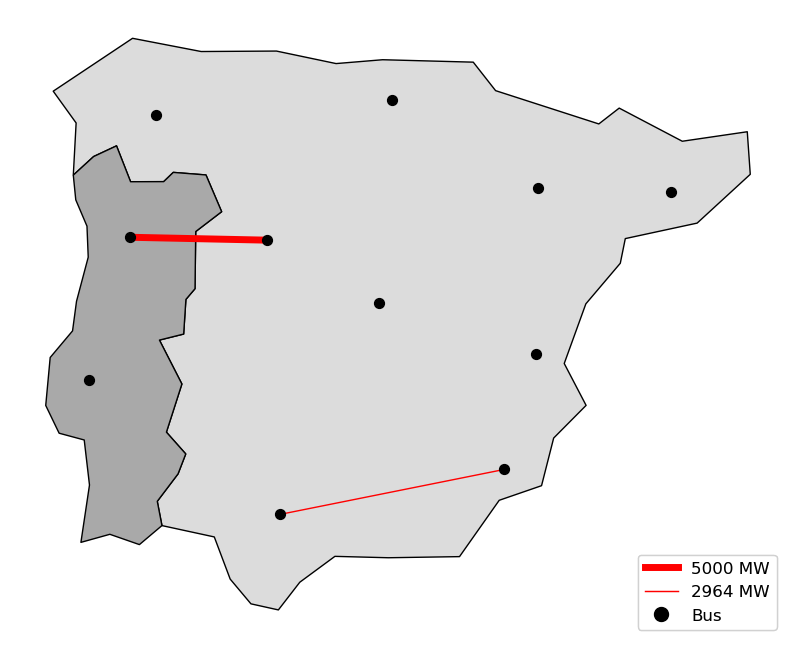

Plotting grid with new branches in year 2025


In [70]:
plot_new_branches_for_years_with_investments(branches, nodes, savefolder=figures_folder)

## Batteries

In [71]:
def extend_batteries_table(
    batteries: pd.DataFrame, battery_capacity: pd.DataFrame
) -> pd.DataFrame:
    """
    Add new_capacity and total_capacity (cumulative) to the batteries DataFrame.

    Parameters
    ----------
    batteries : pd.DataFrame
        MultiIndexed by (year, battery) with battery parameters.
    battery_capacity : pd.DataFrame
        MultiIndexed by (battery, year) with a 'value' column of new MWh built.

    Returns
    -------
    pd.DataFrame
        batteries with two new columns:
        - new_capacity      (MWh added in that year)
        - cum_new_capacity  (cumulative MWh added up to that year)
        - total_capacity    (same as cum_new_capacity, since no initial capacity)
    """
    # 1. Reset indices for merging
    b = batteries.reset_index()  # exposes year, battery, params…
    cap = battery_capacity.reset_index()  # exposes battery, year, value

    # 2. Rename & merge the new capacity
    cap = cap.rename(columns={"value": "new_capacity"})
    merged = b.merge(
        cap[["battery", "year", "new_capacity"]], on=["battery", "year"], how="left"
    )

    # 3. Missing years mean zero new capacity
    merged["new_capacity"] = merged["new_capacity"].fillna(0)

    # 4. Sort and compute cumulatives
    merged = merged.sort_values(["battery", "year"])
    merged["cum_new_capacity"] = merged.groupby("battery")["new_capacity"].cumsum()

    # 5. Total capacity equals cumulative new capacity
    merged["total_capacity"] = merged["cum_new_capacity"]

    # 6. Restore the original MultiIndex
    return merged.set_index(["year", "battery"])

In [72]:
batteries = extend_batteries_table(batteries, battery_capacity)

In [73]:
def plot_battery_investment_by_year(
    batteries: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Plot a bar chart of annual battery capacity investments.

    Parameters
    ----------
    batteries : pd.DataFrame
        DataFrame indexed by (year, battery) with a 'new_capacity' column (MWh added).
    savefolder : str or None, optional
        Directory to save the figure. If None, the figure is not saved.
    """
    # Aggregate new_capacity by year
    temp = batteries.reset_index()
    annual_new = temp.groupby("year")["new_capacity"].sum()

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(annual_new.index.astype(str), annual_new.values)
    ax.set_xlabel("Year")
    ax.set_ylabel("Battery Investment (MWh)")
    plt.tight_layout()

    # Print title line
    print("Annual Battery Capacity Investments")
    plt.show()

    # Save if requested
    if savefolder:
        savepath = os.path.join(savefolder, "battery_investment_by_year.png")
        fig.savefig(savepath, bbox_inches="tight")

Annual Battery Capacity Investments


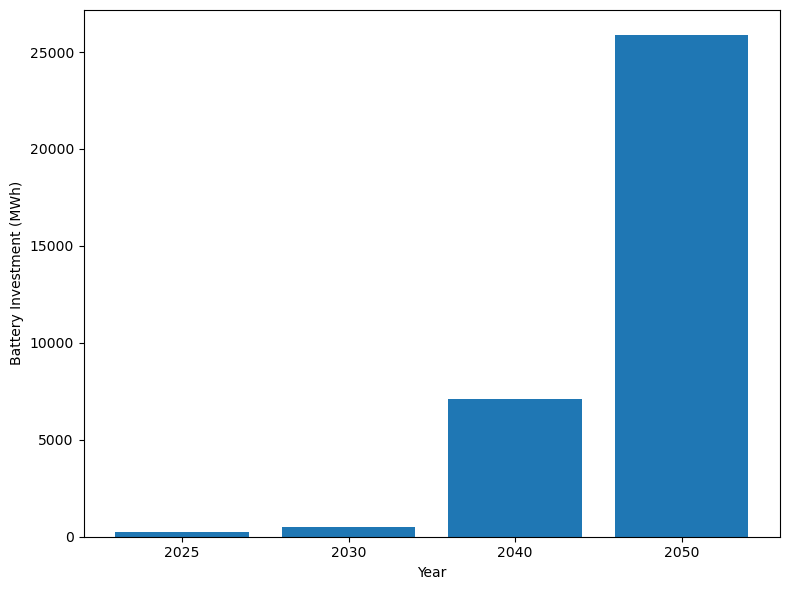

In [74]:
plot_battery_investment_by_year(batteries, savefolder=figures_folder)

In [75]:
def plot_battery_investment_cost_by_year(
    batteries: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Plot a bar chart of annual battery investment costs in million euros.

    Parameters
    ----------
    batteries : pd.DataFrame
        DataFrame indexed by (year, battery) with columns:
        - new_capacity    (MWh added)
        - capital_cost    (EUR/MWh)
    savefolder : str or None, optional
        Directory to save the figure. If None, the figure is not saved.
    """
    temp = batteries.reset_index()
    # Calculate cost in million euros
    temp["investment_cost_meur"] = (temp["new_capacity"] * temp["capital_cost"]) / 1e6
    annual_cost = temp.groupby("year")["investment_cost_meur"].sum()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(annual_cost.index.astype(str), annual_cost.values)
    ax.set_xlabel("Year")
    ax.set_ylabel("Investment Cost (million €)")
    plt.tight_layout()

    print("Annual Battery Investment Cost (million €)")
    plt.show()

    if savefolder:
        savepath = os.path.join(savefolder, "battery_investment_cost_by_year.png")
        fig.savefig(savepath, bbox_inches="tight")

Annual Battery Investment Cost (million €)


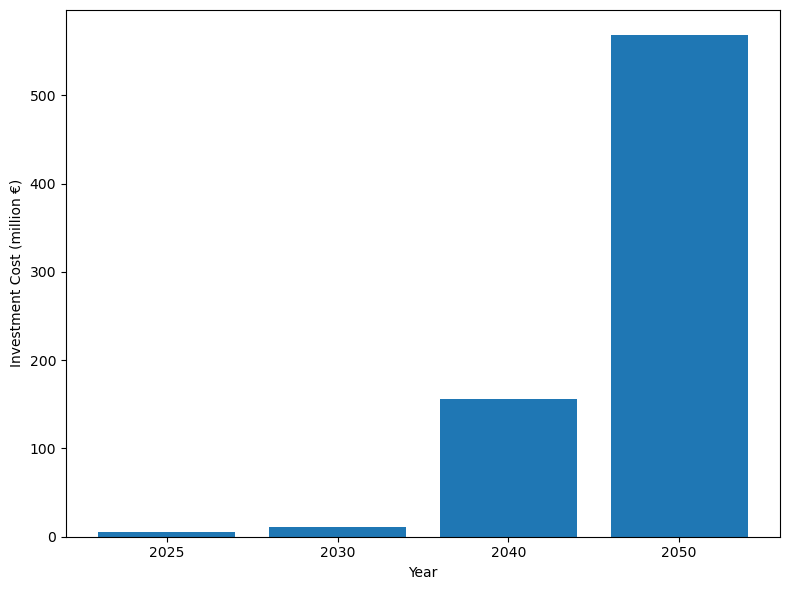

In [76]:
plot_battery_investment_cost_by_year(batteries, savefolder=figures_folder)

In [77]:
def make_battery_system_summary(
    extended_batteries: pd.DataFrame,
    battery_discharging: pd.DataFrame,
    week_weights: dict[str, float],
    scenarios: dict[str, list[str]],
    scenario_probabilities: dict[str, list[float]],
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Compute system‐level battery summary metrics by year:
      - num_buildout       (count of batteries with new_capacity>0)
      - capacity           (sum of total_capacity, MWh)
      - investment_cost    (sum of new_capacity*capital_cost, EUR)
      - cycles_per_year    (expected annual discharge / capacity)

    Parameters
    ----------
    extended_batteries : pd.DataFrame
        Indexed by (year, battery) with columns:
        - new_capacity
        - total_capacity
        - capital_cost
    battery_discharging : pd.DataFrame
        MultiIndexed by (battery, scenario, year, week, hour) with 'value' = discharge MW.
    week_weights : dict[str, float]
        Mapping week→weight for annualization.
    scenarios : dict[str, list[str]]
        Mapping year→list of scenarios.
    scenario_probabilities : dict[str, list[float]]
        Mapping year→list of scenario probabilities.
    savefolder : str or None
        Directory to save CSV. If None, does not save.

    Returns
    -------
    pd.DataFrame
        Indexed by year with columns:
        ['num_buildout', 'capacity', 'investment_cost', 'cycles_per_year']
    """
    # 1) Buildout metrics from extended_batteries
    eb = extended_batteries.reset_index()
    eb["build_cost"] = eb["new_capacity"] * eb["capital_cost"]
    build_summary = eb.groupby("year").agg(
        num_buildout=("new_capacity", lambda x: (x > 0).sum()),
        capacity=("total_capacity", "sum"),
        investment_cost=("build_cost", "sum"),
    )

    # 2) Compute expected annual discharge per battery-year
    wd = (
        battery_discharging.groupby(["battery", "scenario", "year", "week"])["value"]
        .sum()
        .reset_index(name="weekly_discharge")
    )
    wd["weight"] = wd["week"].astype(str).map(week_weights)
    wd["annual_discharge"] = wd["weekly_discharge"] * wd["weight"]

    # attach scenario probabilities
    prob_rows = []
    for y_str, scen_list in scenarios.items():
        y = int(y_str)
        for scen, prob in zip(scen_list, scenario_probabilities[y_str]):
            prob_rows.append({"year": y, "scenario": scen, "prob": prob})
    prob_df = pd.DataFrame(prob_rows)

    wd = wd.merge(prob_df, on=["year", "scenario"], how="left")
    wd["w_annual_discharge"] = wd["annual_discharge"] * wd["prob"]

    # sum across scenarios per battery-year
    exp_discharge = (
        wd.groupby(["battery", "year"])["w_annual_discharge"].sum().reset_index()
    )

    # 3) Sum expected discharge across batteries per year
    total_discharge = (
        exp_discharge.groupby("year")["w_annual_discharge"]
        .sum()
        .rename("expected_discharge")
    )

    # 4) Merge into summary to compute cycles
    summary = build_summary.join(total_discharge)
    summary["cycles_per_year"] = summary["expected_discharge"] / summary["capacity"]

    # drop intermediate
    summary = summary.drop(columns=["expected_discharge"])

    # 5) Optional save
    if savefolder:
        summary.to_csv(os.path.join(savefolder, "battery_system_summary_by_year.csv"))

    return summary

In [78]:
battery_summary = make_battery_system_summary(
    batteries,
    battery_discharging,
    week_weights,
    scenarios,
    scenario_probabilities,
    tables_folder,
)

In [79]:
battery_summary

,num_buildout,capacity,investment_cost,cycles_per_year
year,,,,
2025,2,263.004741,5.775301e+06,238.059248
2030,2,739.462606,1.046250e+07,188.695875
2040,2,7829.070909,1.556802e+08,247.554887
2050,2,33702.645487,5.681559e+08,183.353333


In [80]:
def plot_cycles_per_scenario_with_average(
    battery_discharging: pd.DataFrame,
    week_weights: dict[str, float],
    reference_cycle_mwh: float = 400,
    savefolder: str | None = None,
) -> None:
    """
    Grouped bar chart of annual number of reference cycles by year, scenario, and average.

    A “reference cycle” is defined as using `reference_cycle_mwh` MWh of discharge.
    """
    # 1) Flatten and annualize discharge
    df = battery_discharging.reset_index().rename(columns={"value": "discharge"})
    df["weight"] = df["week"].astype(str).map(week_weights)
    df["annual_discharge"] = df["discharge"] * df["weight"]

    # 2) Sum to annual discharge per battery, scenario, year
    annual = (
        df.groupby(["battery", "scenario", "year"])["annual_discharge"]
        .sum()
        .reset_index()
    )
    # 3) Total annual discharge by scenario & year
    total = (
        annual.groupby(["scenario", "year"])["annual_discharge"]
        .sum()
        .reset_index(name="annual_discharge")
    )
    # 4) Compute cycles
    total["cycles"] = total["annual_discharge"] / reference_cycle_mwh

    # 5) Pivot to have scenarios as columns, then compute average
    cycles_df = total.pivot(index="year", columns="scenario", values="cycles")
    cycles_df["Average"] = cycles_df.mean(axis=1, skipna=True)

    # 6) Prepare for plotting (fill NaN with 0)
    df_plot = cycles_df.fillna(0)

    # 7) Plot grouped bar chart
    fig, ax = plt.subplots(figsize=(8, 6))
    df_plot.plot(kind="bar", ax=ax, color=[scenario_colors[s] for s in df_plot.columns])

    ax.set_xlabel("Year")
    ax.set_ylabel(f"Number of {int(reference_cycle_mwh)} MWh Cycles")
    plt.tight_layout()
    print(
        f"Number of {int(reference_cycle_mwh)} MWh Cycles by Year, Scenario, and Average"
    )
    plt.show()

    # 8) Save if requested
    if savefolder:
        filename = (
            f"battery_cycles_per_{int(reference_cycle_mwh)}MWh_by_scenario_avg.png"
        )
        fig.savefig(os.path.join(savefolder, filename), bbox_inches="tight")

Number of 400 MWh Cycles by Year, Scenario, and Average


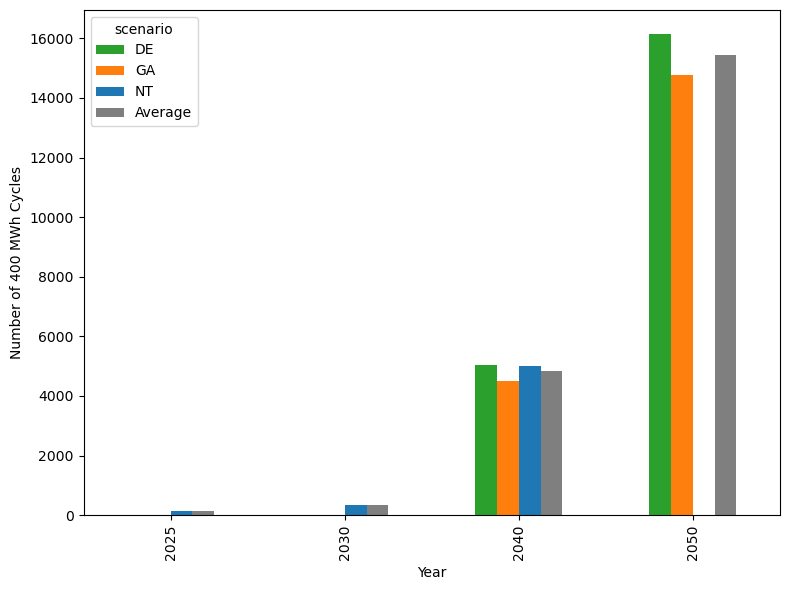

In [81]:
plot_cycles_per_scenario_with_average(
    battery_discharging,
    week_weights,
    reference_cycle_mwh=400,
    savefolder=figures_folder,
)

In [82]:
def plot_curtailment_by_scenario(
    curtailment: pd.DataFrame,
    week_weights: dict[str, float],
    savefolder: str | None = None,
) -> None:
    """
    Grouped bar chart of annual curtailment by year and scenario.

    Parameters
    ----------
    curtailment : pd.DataFrame
        MultiIndexed by (generator, scenario, year, week, hour) with column 'value' (MWh curtailed).
    week_weights : dict[str, float]
        Mapping week → weight for annualization.
    savefolder : str or None
        Directory to save the figure. If None, the figure is not saved.
    """
    df = curtailment.reset_index().rename(columns={"value": "curtail"})
    df["weight"] = df["week"].astype(str).map(week_weights)
    df["annual_curtail"] = df["curtail"] * df["weight"]

    total = df.groupby(["scenario", "year"])["annual_curtail"].sum().reset_index()
    pivot = total.pivot(
        index="year", columns="scenario", values="annual_curtail"
    ).fillna(0)

    fig, ax = plt.subplots(figsize=(8, 6))
    pivot.plot(kind="bar", ax=ax, color=[scenario_colors[s] for s in pivot.columns])
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual Curtailment (MWh)")
    plt.tight_layout()
    print("Annual Curtailment by Year and Scenario")
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "curtailment_by_scenario.png"), bbox_inches="tight"
        )


def plot_load_shedding_by_scenario(
    load_shedding: pd.DataFrame,
    week_weights: dict[str, float],
    savefolder: str | None = None,
) -> None:
    """
    Grouped bar chart of annual load shedding by year and scenario.

    Parameters
    ----------
    load_shedding : pd.DataFrame
        MultiIndexed by (node, scenario, year, week, hour) with column 'value' (MWh shed).
    week_weights : dict[str, float]
        Mapping week → weight for annualization.
    savefolder : str or None
        Directory to save the figure. If None, the figure is not saved.
    """
    df = load_shedding.reset_index().rename(columns={"value": "shed"})
    df["weight"] = df["week"].astype(str).map(week_weights)
    df["annual_shed"] = df["shed"] * df["weight"]

    total = df.groupby(["scenario", "year"])["annual_shed"].sum().reset_index()
    pivot = total.pivot(index="year", columns="scenario", values="annual_shed").fillna(
        0
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    pivot.plot(kind="bar", ax=ax, color=[scenario_colors[s] for s in pivot.columns])
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual Load Shedding (MWh)")
    plt.tight_layout()
    print("Annual Load Shedding by Year and Scenario")
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "load_shedding_by_scenario.png"),
            bbox_inches="tight",
        )

Annual Curtailment by Year and Scenario


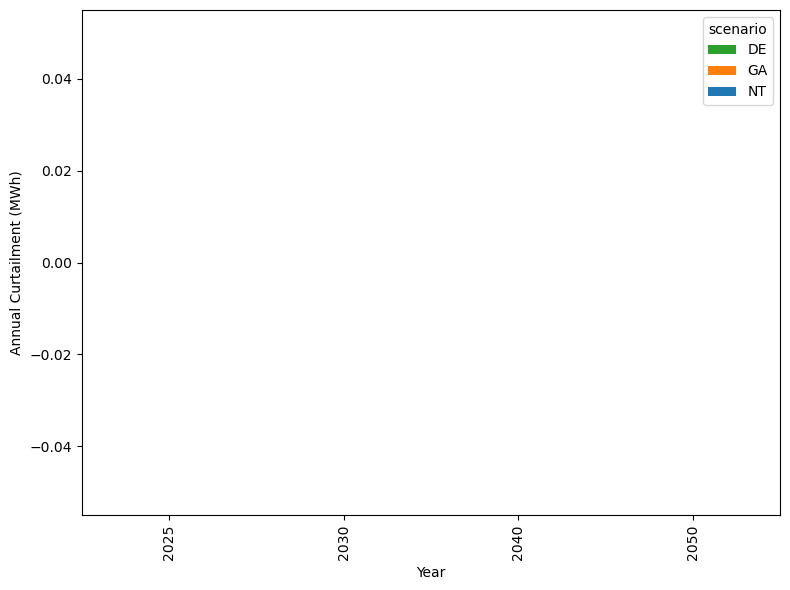

Annual Load Shedding by Year and Scenario


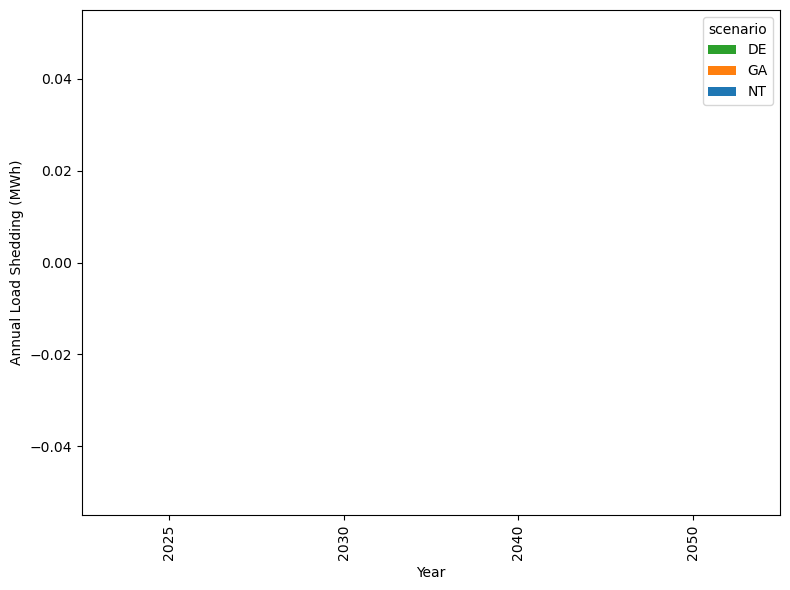

In [83]:
plot_curtailment_by_scenario(curtailment, week_weights, savefolder=figures_folder)
plot_load_shedding_by_scenario(load_shedding, week_weights, savefolder=figures_folder)

In [84]:
def make_curtailment_load_shedding_cost_table(
    curtailment: pd.DataFrame,
    load_shedding: pd.DataFrame,
    week_weights: dict[str, float],
    CC: float,
    VOLL: float,
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Compute annual curtailment and load‐shedding and their costs by year and scenario.

    Parameters
    ----------
    curtailment : pd.DataFrame
        MultiIndexed by (generator, scenario, year, week, hour) with column 'value' (MWh curtailed).
    load_shedding : pd.DataFrame
        MultiIndexed by (node, scenario, year, week, hour) with column 'value' (MWh shed).
    week_weights : dict[str, float]
        Mapping week → weight for annualization.
    CC : float
        Curtailment cost in EUR/MWh.
    VOLL : float
        Value of lost load in EUR/MWh.
    savefolder : str or None
        Directory to save the CSV. If None, does not save.

    Returns
    -------
    pd.DataFrame
        Indexed by (year, scenario) with columns:
        - load_shedding       (MWh)
        - curtailment         (MWh)
        - load_shedding_cost  (EUR)
        - curtailment_cost    (EUR)
    """
    # 1) Annualize curtailment
    df_c = curtailment.reset_index().rename(columns={"value": "curtailment"})
    df_c["weight"] = df_c["week"].astype(str).map(week_weights)
    df_c["annual_curtail"] = df_c["curtailment"] * df_c["weight"]
    annual_c = df_c.groupby(["year", "scenario"])["annual_curtail"].sum().reset_index()

    # 2) Annualize load shedding
    df_l = load_shedding.reset_index().rename(columns={"value": "load_shed"})
    df_l["weight"] = df_l["week"].astype(str).map(week_weights)
    df_l["annual_shed"] = df_l["load_shed"] * df_l["weight"]
    annual_l = df_l.groupby(["year", "scenario"])["annual_shed"].sum().reset_index()

    # 3) Merge and compute costs
    summary = annual_l.merge(annual_c, on=["year", "scenario"], how="outer").fillna(0)
    summary["load_shedding_cost"] = summary["annual_shed"] * VOLL
    summary["curtailment_cost"] = summary["annual_curtail"] * CC

    # 4) Rename and set index
    summary = summary.rename(
        columns={"annual_shed": "load_shedding", "annual_curtail": "curtailment"}
    )
    summary = summary.set_index(["year", "scenario"])

    # 5) Save if requested
    if savefolder:
        path = os.path.join(savefolder, "curtailment_load_shedding_costs.csv")
        summary.to_csv(path)

    return summary

In [85]:
curtailment_and_load_shedding_table = make_curtailment_load_shedding_cost_table(
    curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
)
curtailment_and_load_shedding_table

load_shedding  curtailment  load_shedding_cost  \
year scenario                                                   
2025 NT                  0.0          0.0                 0.0   
2030 NT                  0.0          0.0                 0.0   
2040 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   
     NT                  0.0          0.0                 0.0   
2050 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   

               curtailment_cost  
year scenario                    
2025 NT                     0.0  
2030 NT                     0.0  
2040 DE                     0.0  
     GA                     0.0  
     NT                     0.0  
2050 DE                     0.0  
     GA                     0.0

## Macro analysis

In [86]:
def plot_yearly_costs_stacked_avg(
    system_summary: pd.DataFrame,
    battery_summary: pd.DataFrame,
    branch_summary: pd.DataFrame,
    yearly_system_costs: pd.DataFrame,
    curtail_shed_costs: pd.DataFrame,
    savefolder: str | None = None,
) -> None:
    """
    Stacked‐bar of annual system costs (billion €), averaged across scenarios:
      - investments (gen, bat, tx)
      - production cost
      - CO₂ cost
      - load shedding cost
      - curtailment cost
    """
    # 1) Average scenario‐level costs
    prod_cost_avg = (
        yearly_system_costs["production_cost"].unstack("scenario").mean(axis=1) / 1e9
    )
    co2_cost_avg = (
        yearly_system_costs["co2_emission_cost"].unstack("scenario").mean(axis=1) / 1e9
    )
    ls_cost_avg = (
        curtail_shed_costs["load_shedding_cost"].unstack("scenario").mean(axis=1) / 1e9
    )
    curt_cost_avg = (
        curtail_shed_costs["curtailment_cost"].unstack("scenario").mean(axis=1) / 1e9
    )

    # 2) Investments (already scenario‐independent), scaled to billion €
    inv_gen = system_summary["cost_of_buildout"] / 1e9
    inv_bat = battery_summary["investment_cost"] / 1e9
    inv_tx = branch_summary["cost_of_buildout"] / 1e9

    # 3) Assemble DataFrame
    df = pd.DataFrame(
        {
            "Invest Gen": inv_gen,
            "Invest Bat": inv_bat,
            "Invest Tx": inv_tx,
            "Prod Cost": prod_cost_avg,
            "CO₂ Cost": co2_cost_avg,
            "Load Shedding Cost": ls_cost_avg,
            "Curtailment Cost": curt_cost_avg,
        }
    ).fillna(0)

    # 4) Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    df.plot(
        kind="bar", stacked=True, ax=ax, color=[category_colors[c] for c in df.columns]
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Cost (billion €)")
    plt.tight_layout()
    print("Annual System Costs (average across scenarios)")
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "yearly_system_costs_avg.png"), bbox_inches="tight"
        )


def plot_yearly_costs_stacked_by_scenario(
    system_summary: pd.DataFrame,
    battery_summary: pd.DataFrame,
    branch_summary: pd.DataFrame,
    yearly_system_costs: pd.DataFrame,
    curtail_shed_costs: pd.DataFrame,
    savefolder: str | None = None,
) -> None:
    """
    Stacked‐bar of annual system costs (billion €) for each scenario:
      - investments (gen, bat, tx)
      - production cost
      - CO₂ cost
      - load shedding cost
      - curtailment cost
    """
    # 1) Base costs per (year,scenario), scaled to billion €
    df = yearly_system_costs[["production_cost", "co2_emission_cost"]].copy()
    df = df.rename(
        columns={"production_cost": "Prod Cost", "co2_emission_cost": "CO₂ Cost"}
    )
    df["Prod Cost"] = df["Prod Cost"] / 1e9
    df["CO₂ Cost"] = df["CO₂ Cost"] / 1e9

    # 2) Add load shedding & curtailment cost (billion €)
    ls = (curtail_shed_costs["load_shedding_cost"] / 1e9).rename("Load Shedding Cost")
    ct = (curtail_shed_costs["curtailment_cost"] / 1e9).rename("Curtailment Cost")
    df = df.join(ls).join(ct).fillna(0)

    # 3) Add investments by mapping year → billion €
    yrs = df.index.get_level_values("year")
    df["Invest Gen"] = yrs.map(system_summary["cost_of_buildout"] / 1e9)
    df["Invest Bat"] = yrs.map(battery_summary["investment_cost"] / 1e9)
    df["Invest Tx"] = yrs.map(branch_summary["cost_of_buildout"] / 1e9)

    # 4) Reorder columns
    df = df[
        [
            "Invest Gen",
            "Invest Bat",
            "Invest Tx",
            "Prod Cost",
            "CO₂ Cost",
            "Load Shedding Cost",
            "Curtailment Cost",
        ]
    ]

    # 5) Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    df.plot(
        kind="bar", stacked=True, ax=ax, color=[category_colors[c] for c in df.columns]
    )
    ax.set_xlabel("Year / Scenario")
    ax.set_ylabel("Cost (billion €)")
    plt.tight_layout()
    print("Annual System Costs by Scenario")
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "yearly_system_costs_by_scenario.png"),
            bbox_inches="tight",
        )

In [87]:
system_summary = summary_table = make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=tables_folder,
)
branch_summary = make_branch_buildout_summary(branches, tables_folder)
yearly_system_cost_table = make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, savefolder=tables_folder
)
curtailment_and_load_shedding_table = make_curtailment_load_shedding_cost_table(
    curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
)

Branch buildout summary by year:


,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,7964.494407,19,2,1.341461e+08
2030,95000,0.000000,19,0,0.000000e+00
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


Yearly system metrics by year and scenario:


In [88]:
if len(batteries) > 0:
    print("Yes")
    battery_summary = make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        savefolder=tables_folder,
    )
else:
    # Dummy columns
    columns = ["num_buildout", "capacity", "investment_cost", "cycles_per_year"]

    # Create the DataFrame with NaNs
    empty_df = pd.DataFrame(index=years, columns=columns)
    empty_df.index.name = "year"
    battery_summary = empty_df

Yes


In [89]:
battery_summary

,num_buildout,capacity,investment_cost,cycles_per_year
year,,,,
2025,2,263.004741,5.775301e+06,238.059248
2030,2,739.462606,1.046250e+07,188.695875
2040,2,7829.070909,1.556802e+08,247.554887
2050,2,33702.645487,5.681559e+08,183.353333


Annual System Costs (average across scenarios)


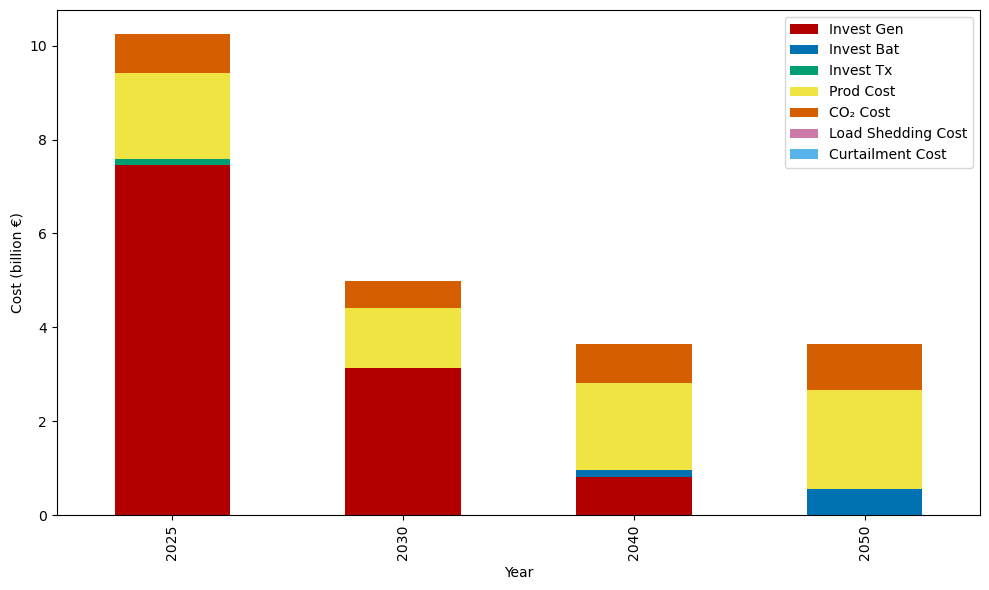

In [90]:
plot_yearly_costs_stacked_avg(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=figures_folder,
)

Annual System Costs by Scenario


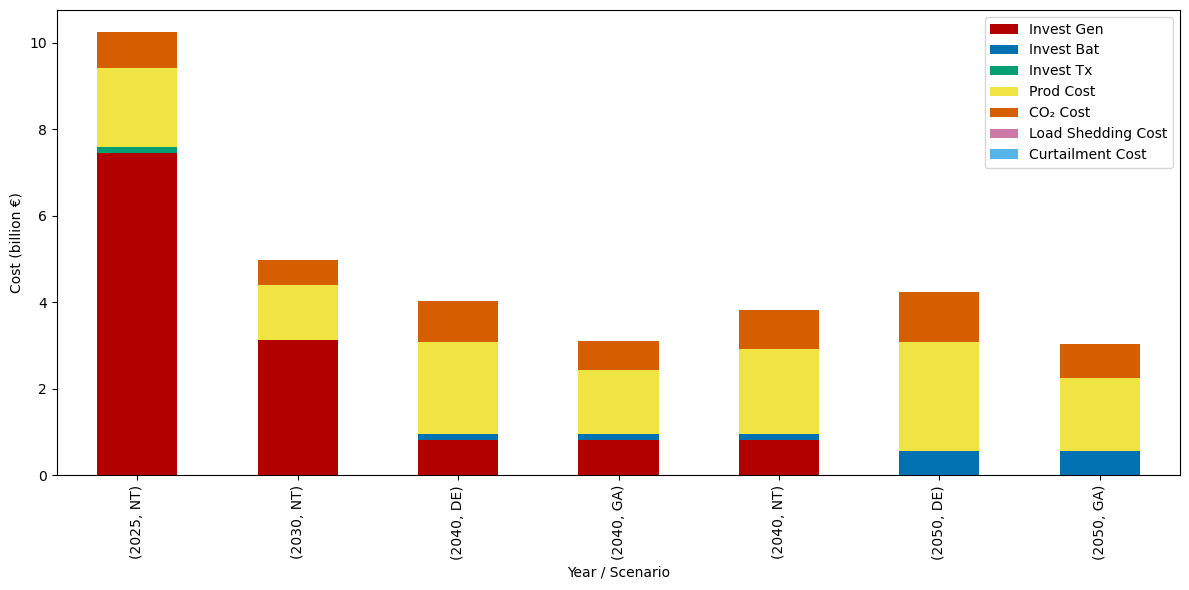

In [91]:
plot_yearly_costs_stacked_by_scenario(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=figures_folder,
)

In [92]:
def compute_total_system_cost(
    system_summary: pd.DataFrame,
    battery_summary: pd.DataFrame,
    branch_summary: pd.DataFrame,
    yearly_system_costs: pd.DataFrame,
    curtail_shed_costs: pd.DataFrame,
    scenarios: dict[str, list[str]],
    scenario_probabilities: dict[str, list[float]],
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Compute, for each year, the total cost as in the optimisation objective:
      AIC_y + ∑_{ω} p_{ω,y} · OC_{ω,y},
    where:
      AIC_y = investment cost in generators + batteries + branches
      OC_{ω,y} = production_cost + co2_emission_cost
               + load_shedding_cost + curtailment_cost
      and all are drawn from the supplied summary tables.

    Returns a DataFrame indexed by year with columns:
      - AIC           (EUR)
      - expected_OC   (EUR)
      - total_cost    (EUR)
    """
    # 1) Build annual investment cost AIC_y
    # system_summary and branch_summary each have .cost_of_buildout,
    # battery_summary has .investment_cost
    battery_investment = battery_summary["investment_cost"].fillna(0)

    AIC = (
        system_summary["cost_of_buildout"]
        + battery_investment
        + branch_summary["cost_of_buildout"]
    ).rename("AIC")

    print(f"system summary cost of buildout:\n{system_summary['cost_of_buildout']}")
    print(f"battery summary investment cost:\n{battery_summary['investment_cost']}")
    print(f"branch summary cost of buildout:\n{branch_summary['cost_of_buildout']}")
    print(f"AIC:\n{AIC}")

    # 2) Compute OC_{ω,y} = prod + co2 + load shedding + curtailment
    # merge the two per-(year,scenario) tables
    oc = (
        yearly_system_costs[["production_cost", "co2_emission_cost"]]
        .join(curtail_shed_costs[["load_shedding_cost", "curtailment_cost"]])
        .fillna(0)
    )
    oc["OC"] = (
        oc["production_cost"]
        + oc["co2_emission_cost"]
        + oc["load_shedding_cost"]
        + oc["curtailment_cost"]
    )

    # 3) Weight by scenario probabilities to get E[OC] per year
    # build a DataFrame of probabilities
    prob_rows = []
    for y_str, scen_list in scenarios.items():
        y = int(y_str)
        for scen, p in zip(scen_list, scenario_probabilities[y_str]):
            prob_rows.append({"year": y, "scenario": scen, "p": p})
    prob_df = pd.DataFrame(prob_rows).set_index(["year", "scenario"])

    oc = oc.join(prob_df, how="left")
    oc["p"] = oc["p"].fillna(0)
    oc["pOC"] = oc["OC"] * oc["p"]

    exp_OC = oc.groupby(level="year")["pOC"].sum().rename("expected_OC")

    # 4) Combine AIC and expected_OC
    result = pd.concat([AIC, exp_OC], axis=1).fillna(0)
    result["total_cost"] = result["AIC"] + result["expected_OC"]
    if savefolder:
        result.to_csv(os.path.join(savefolder, "total_system_cost.csv"))

    # 5) Print and return
    print("Total system cost by year:")

    return result

In [93]:
total_system_cost = compute_total_system_cost(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=tables_folder,
)
total_system_cost

system summary cost of buildout:
year
2025    7.447474e+09
2030    3.126891e+09
2040    8.084783e+08
2050    0.000000e+00
Name: cost_of_buildout, dtype: float64
battery summary investment cost:
year
2025    5.775301e+06
2030    1.046250e+07
2040    1.556802e+08
2050    5.681559e+08
Name: investment_cost, dtype: float64
branch summary cost of buildout:
year
2025    1.341461e+08
2030    0.000000e+00
2040    0.000000e+00
2050    0.000000e+00
Name: cost_of_buildout, dtype: float64
AIC:
year
2025    7.587396e+09
2030    3.137353e+09
2040    9.641585e+08
2050    5.681559e+08
Name: AIC, dtype: float64
Total system cost by year:


,AIC,expected_OC,total_cost
year,,,
2025,7.587396e+09,2.658087e+09,1.024548e+10
2030,3.137353e+09,1.850748e+09,4.988101e+09
2040,9.641585e+08,2.686379e+09,3.650537e+09
2050,5.681559e+08,3.075846e+09,3.644001e+09


In [95]:
print(f"Total system cost (EUR): {total_system_cost['total_cost'].sum():,.0f}")
print(
    f"Total system cost (EUR) according to model: {model_info['Objective Value'][0]:,.0f}"
)
assert (
    abs(total_system_cost["total_cost"].sum() - model_info["Objective Value"][0]) < 1
), f"Mismatch in total system cost: {total_system_cost['total_cost'].sum():,.0f} vs {model_info['Objective Value'][0]:,.0f}"

Total system cost (EUR): 22,528,123,222
Total system cost (EUR) according to model: 22,528,123,222


In [96]:
def make_mega_cost_table(
    system_summary: pd.DataFrame,
    battery_summary: pd.DataFrame,
    branch_summary: pd.DataFrame,
    yearly_system_costs: pd.DataFrame,
    curtail_shed_costs: pd.DataFrame,
    scenario_probabilities: dict[str, list[float]],
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Build a “mega‐table” of key annual metrics by (year, scenario), plus a final
    ('All','All') row that sums investments and uses probability‐weighted sums
    of operating costs across scenarios and years.

    Columns:
      - Invest Gen
      - Invest Bat
      - Invest Tx
      - Production Cost
      - CO2 Emission Cost
      - Load Shedding Cost
      - Curtailment Cost
      - Prod+CO2 Cost
      - Total CapEx
      - Total OpEx
      - Total Cost
    """
    # --- 1) Scenario‐level data ---
    df = yearly_system_costs[["production_cost", "co2_emission_cost"]].copy()
    df = df.join(curtail_shed_costs[["load_shedding_cost", "curtailment_cost"]])
    # map investments
    yrs = df.index.get_level_values("year")
    df["Invest Gen"] = yrs.map(system_summary["cost_of_buildout"])
    df["Invest Bat"] = yrs.map(battery_summary["investment_cost"])
    df["Invest Tx"] = yrs.map(branch_summary["cost_of_buildout"])
    # rename
    df = df.rename(
        columns={
            "production_cost": "Production Cost",
            "co2_emission_cost": "CO2 Emission Cost",
            "load_shedding_cost": "Load Shedding Cost",
            "curtailment_cost": "Curtailment Cost",
        }
    )
    # derived cols
    df["Prod+CO2 Cost"] = df["Production Cost"] + df["CO2 Emission Cost"]
    df["Total CapEx"] = df[["Invest Gen", "Invest Bat", "Invest Tx"]].sum(axis=1)
    df["Total OpEx"] = df[
        [
            "Production Cost",
            "CO2 Emission Cost",
            "Load Shedding Cost",
            "Curtailment Cost",
        ]
    ].sum(axis=1)
    df["Total Cost"] = df["Total CapEx"] + df["Total OpEx"]
    cols = [
        "Invest Gen",
        "Invest Bat",
        "Invest Tx",
        "Production Cost",
        "CO2 Emission Cost",
        "Load Shedding Cost",
        "Curtailment Cost",
        "Prod+CO2 Cost",
        "Total CapEx",
        "Total OpEx",
        "Total Cost",
    ]
    df = df[cols]

    # --- 2) Attach scenario probabilities ---
    prob_list = []
    for year_str, scen_list in scenarios.items():  # iterate the *names* dict
        year = int(year_str)
        probs = scenario_probabilities[year_str]  # these are the matching probabilities
        for scen, p in zip(scen_list, probs):
            prob_list.append({"year": year, "scenario": scen, "p": p})
    prob_df = pd.DataFrame(prob_list).set_index(["year", "scenario"])

    dfp = df.join(prob_df, how="left")

    # --- 3) Compute 'All' row via weighted sums ---
    # A) total investments (sum over years, scenario-independent)
    total_inv_gen = system_summary["cost_of_buildout"].sum()
    total_inv_bat = battery_summary["investment_cost"].sum()
    total_inv_tx = branch_summary["cost_of_buildout"].sum()
    # B) weighted sums of opex across (year,scenario)
    exp_prod_cost = (dfp["Production Cost"] * dfp["p"]).sum()
    exp_co2_cost = (dfp["CO2 Emission Cost"] * dfp["p"]).sum()
    exp_ls_cost = (dfp["Load Shedding Cost"] * dfp["p"]).sum()
    exp_curt_cost = (dfp["Curtailment Cost"] * dfp["p"]).sum()
    # recompute derived
    exp_prod_co2 = exp_prod_cost + exp_co2_cost
    total_capex = total_inv_gen + total_inv_bat + total_inv_tx
    total_opex = exp_prod_co2 + exp_ls_cost + exp_curt_cost
    total_cost = total_capex + total_opex

    # assemble 'All' row
    all_metrics = {
        "Invest Gen": total_inv_gen,
        "Invest Bat": total_inv_bat,
        "Invest Tx": total_inv_tx,
        "Production Cost": exp_prod_cost,
        "CO2 Emission Cost": exp_co2_cost,
        "Load Shedding Cost": exp_ls_cost,
        "Curtailment Cost": exp_curt_cost,
        "Prod+CO2 Cost": exp_prod_co2,
        "Total CapEx": total_capex,
        "Total OpEx": total_opex,
        "Total Cost": total_cost,
    }
    all_idx = pd.MultiIndex.from_tuples([("All", "All")], names=["year", "scenario"])
    all_row = pd.DataFrame(all_metrics, index=all_idx)

    # --- 4) Concatenate final mega table ---
    mega = pd.concat([df, all_row], sort=False)

    # drop the probability column if present
    if "p" in mega.columns:
        mega = mega.drop(columns=["p"])

    # --- 5) Save if requested ---
    if savefolder:
        mega.to_csv(os.path.join(savefolder, "mega_cost_table.csv"))

    return mega

In [97]:
if len(batteries) == 0:
    # Dummy columns
    columns = ["num_buildout", "capacity", "investment_cost", "cycles_per_year"]

    # Create the DataFrame with NaNs
    empty_df = pd.DataFrame(index=years, columns=columns)
    empty_df.index.name = "year"
    battery_summary = empty_df

In [98]:
mega_table = make_mega_cost_table(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenario_probabilities,
    savefolder=tables_folder,
)

In [99]:
mega_table

Invest Gen    Invest Bat     Invest Tx  Production Cost  \
year scenario                                                              
2025 NT        7.447474e+09  5.775301e+06  1.341461e+08     1.835395e+09   
2030 NT        3.126891e+09  1.046250e+07  0.000000e+00     1.272858e+09   
2040 DE        8.084783e+08  1.556802e+08  0.000000e+00     2.107953e+09   
     GA        8.084783e+08  1.556802e+08  0.000000e+00     1.461924e+09   
     NT        8.084783e+08  1.556802e+08  0.000000e+00     1.956496e+09   
2050 DE        0.000000e+00  5.681559e+08  0.000000e+00     2.521499e+09   
     GA        0.000000e+00  5.681559e+08  0.000000e+00     1.693221e+09   
All  All       1.138284e+10  7.400739e+08  1.341461e+08     7.057738e+09   

               CO2 Emission Cost  Load Shedding Cost  Curtailment Cost  \
year scenario                                                            
2025 NT             8.226920e+08                 0.0               0.0   
2030 NT             5.778899e+08                 0.0               0.0   
2040 DE             9.653506e+08                 0.0               0.0   
     GA             6.697923e+08                 0.0               0.0   
     NT             8.976211e+08                 0.0               0.0   
2050 DE             1.155513e+09                 0.0               0.0   
     GA             7.814581e+08                 0.0               0.0   
All  All            3.213322e+09                 0.0               0.0   

               Prod+CO2 Cost   Total CapEx    Total OpEx    Total Cost  
year scenario                                                           
2025 NT         2.658087e+09  7.587396e+09  2.658087e+09  1.024548e+10  
2030 NT         1.850748e+09  3.137353e+09  1.850748e+09  4.988101e+09  
2040 DE         3.073303e+09  9.641585e+08  3.073303e+09  4.037462e+09  
     GA         2.131717e+09  9.641585e+08  2.131717e+09  3.095875e+09  
     NT         2.854117e+09  9.641585e+08  2.854117e+09  3.818275e+09  
2050 DE         3.677012e+09  5.681559e+08  3.677012e+09  4.245168e+09  
     GA         2.474679e+09  5.681559e+08  2.474679e+09  3.042835e+09  
All  All        1.027106e+10  1.225706e+10  1.027106e+10  2.252812e+10

In [100]:
model_info

,Objective Value,Optimality Gap (%),Runtime (s),Build Time (s),Optimize Time (s),Total Time (s),Number of Variables,Number of Constraints,Number of Nonzeros,Number of Integer Variables,Number of Binary Variables,Number of Quadratic Constraints,Model Status
0,2.252812e+10,NaN,2990.057675,152.370698,2990.829347,3143.200045,1895688,1440348,3869565,0,0,0,2


In [101]:
# End  by saving the extended generators, transmission lines, and batteries tables to and extended tables folder
if tables_folder:
    # Create the extended tables folder if it doesn't exist
    extended_tables_folder = os.path.join(tables_folder, "extended_tables")
    os.makedirs(extended_tables_folder, exist_ok=True)
    generators.to_csv(
        os.path.join(extended_tables_folder, "extended_generators.csv"), index=False
    )
    branches.to_csv(
        os.path.join(extended_tables_folder, "extended_branches.csv"), index=False
    )
    batteries.to_csv(
        os.path.join(extended_tables_folder, "extended_batteries.csv"), index=False
    )


# Save the extended tables

# Dual Variables Analysis

In [102]:
for key in dual_variables.keys():
    print(key)
    print()
    display(dual_variables[key].head(2))
    print("------------------------------")

battery_charge_new_max_duals



dual_value
battery   scenario year week hour            
ES1 0 bat NT       2025 11   0            0.0
                             1            0.0

------------------------------
battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


------------------------------
battery_discharge_new_max_duals



...

------------------------------
load_shedding_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0            0.0
                         1            0.0

------------------------------
power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0        0.01505
                         1        0.01500

------------------------------


### Power Balance Duals

In [103]:
node_to_city = {
    "ES1 0": "Murcia",
    "ES1 1": "Bilbao",
    "ES1 2": "Zaragoza",
    "ES1 3": "Seville",
    "ES1 4": "Lugo",
    "ES1 5": "Madrid",
    "ES1 6": "Valencia",
    "ES1 7": "Salamanca",
    "ES1 8": "Barcelona",
    "PT1 0": "Porto",
    "PT1 1": "Lisbon",
}

In [104]:
if SAVE_FIGURES:
    # Create the figures folder if it doesn't exist
    duals_folder = os.path.join(RESULTS_FOLDER, "duals")
    os.makedirs(duals_folder, exist_ok=True)
    tables_folder = os.path.join(duals_folder, "tables")
    figures_folder = os.path.join(duals_folder, "figures")
    os.makedirs(tables_folder, exist_ok=True)
    os.makedirs(figures_folder, exist_ok=True)

In [105]:
def make_nodal_price_table(
    power_balance_duals: pd.DataFrame,
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Compute annual average locational marginal prices (LMPs) per node, scenario, and year
    from the power_balance_duals.

    Parameters
    ----------
    power_balance_duals : pd.DataFrame
        MultiIndexed by (node, scenario, year, week, hour) with column 'dual_value'.
    week_weights : dict[str, float]
        Mapping from week (as string) to weight for annualization.

    Returns
    -------
    pd.DataFrame
        Indexed by (year, scenario), columns are node names, values are annual-average LMP (€/MWh).
    """
    df = power_balance_duals.reset_index().rename(columns={"dual_value": "LMP"})
    # map week to weight
    table = df.groupby(["node", "scenario", "year"])["LMP"].mean()
    table = table.reset_index(name="LMP")
    table = table.pivot(
        index=["year", "scenario"], columns="node", values="LMP"
    ).fillna(0)

    print("Annual Average Locational Marginal Prices by Node")
    if savefolder:
        table.to_csv(os.path.join(savefolder, "nodal_price_table.csv"))
    # Print the first few rows of the table

    return table

In [106]:
lmp_table = make_nodal_price_table(power_balance_duals, savefolder=tables_folder)


lmp_table

Annual Average Locational Marginal Prices by Node


node               ES1 0      ES1 1      ES1 2      ES1 3      ES1 4  \
year scenario                                                          
2025 NT        28.389698  28.063296  28.405991  28.146494  28.375886   
2030 NT        20.262114  20.057581  20.296374  20.120516  20.285092   
2040 DE        11.038572  10.985496  11.115908  11.022045  11.108361   
     GA         7.111564   7.045359   7.129287   7.065047   7.018296   
     NT         8.432988   8.356916   8.455967   8.380556   8.418878   
2050 DE        22.228160  21.973724  22.233463  22.043315  22.218481   
     GA        12.079563  11.967871  12.109986  12.003865  12.059907   

node               ES1 5      ES1 6      ES1 7      ES1 8      PT1 0  \
year scenario                                                          
2025 NT        28.453548  28.753076  28.720912  28.677185  28.500021   
2030 NT        20.340014  20.544370  20.531139  20.490145  20.397675   
2040 DE        11.143267  11.251731  11.246985  11.222033  11.180530   
     GA         7.143162   7.216397   7.209231   7.197350   7.164751   
     NT         8.473170   8.559288   8.551588   8.536697   8.494795   
2050 DE        22.287605  22.505128  22.493178  22.445728  22.295212   
     GA        12.135185  12.257954  12.248842  12.225601  12.177012   

node               PT1 1  
year scenario             
2025 NT        28.806083  
2030 NT        20.616182  
2040 DE        11.290110  
     GA         7.240263  
     NT         8.583452  
2050 DE        22.530722  
     GA        12.306167

In [107]:
def plot_nodal_price_evolution_with_markers(
    lmp_table: pd.DataFrame,
    nodes: list[str] | None = None,
    savefolder: str | None = None,
) -> None:
    """
    Plot line chart of annual average LMPs for selected nodes,
    with each data point marked and legend showing city names.

    Parameters
    ----------
    lmp_table : pd.DataFrame
        Indexed by (year, scenario), columns are node names with avg LMP.
    nodes : list of str, optional
        List of node names to plot. If None, plot all.
    savefolder : str or None
        Directory to save figure. If None, not saved.
    """
    if nodes is None:
        nodes = list(lmp_table.columns)

    years = lmp_table.index.get_level_values("year")
    fig, ax = plt.subplots(figsize=(10, 6))

    for node in nodes:
        city = node_to_city.get(node, node)
        ax.plot(years, lmp_table[node].values, marker="o", linestyle="-", label=city)

    ax.set_xlabel("Year")
    ax.set_ylabel("Annual Avg LMP (€/MWh)")
    fig.subplots_adjust(right=0.75)
    ax.legend(title="City", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    print("Annual Average Locational Marginal Prices by City (with markers)")
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "nodal_price_evolution_markers.png"),
            bbox_inches="tight",
        )

Annual Average Locational Marginal Prices by City (with markers)


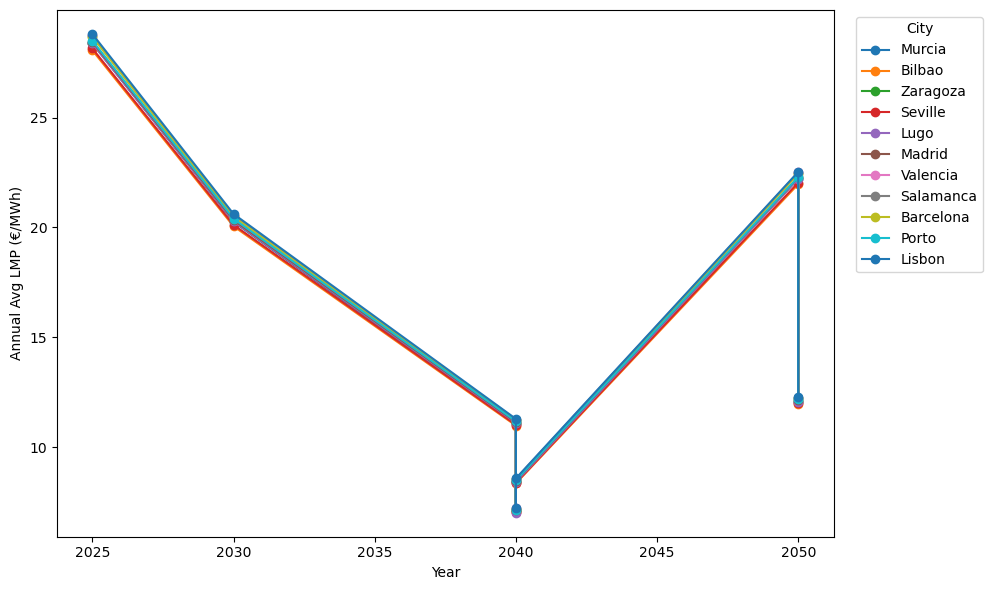

In [108]:
plot_nodal_price_evolution_with_markers(lmp_table, savefolder=figures_folder)

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_nodal_price_grouped_bar(
    lmp_table: pd.DataFrame,
    nodes: list[str] | None = None,
    node_to_city: dict[str, str] = None,
    savefolder: str | None = None,
) -> None:
    """
    Grouped bar chart of annual average LMPs for selected nodes,
    with one cluster per (year, scenario).

    Parameters
    ----------
    lmp_table : pd.DataFrame
        Indexed by (year, scenario), columns are node names with avg LMP.
    nodes : list of str, optional
        List of node names to plot. If None, plot all.
    node_to_city : dict, optional
        Mapping from node code to city name for legend labels.
    savefolder : str or None
        Directory to save figure. If None, not saved.
    """
    if nodes is None:
        nodes = list(lmp_table.columns)
    if node_to_city is None:
        node_to_city = {
            "ES1 0": "Murcia",
            "ES1 1": "Bilbao",
            "ES1 2": "Zaragoza",
            "ES1 3": "Seville",
            "ES1 4": "Lugo",
            "ES1 5": "Madrid",
            "ES1 6": "Valencia",
            "ES1 7": "Salamanca",
            "ES1 8": "Barcelona",
            "PT1 0": "Porto",
            "PT1 1": "Lisbon",
        }

    # Prepare data
    df = lmp_table[nodes].fillna(0)
    idx = list(df.index)  # list of (year, scenario) tuples
    n_groups = len(idx)
    n_nodes = len(nodes)

    # Bar positions
    base = np.arange(n_groups)
    width = 0.8 / n_nodes

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, node in enumerate(nodes):
        x = base + (i - (n_nodes - 1) / 2) * width
        city_label = node_to_city.get(node, node)
        ax.bar(x, df[node].values, width=width, label=city_label)

    # X-axis labels
    labels = [f"{year}\n{scenario}" for year, scenario in idx]
    ax.set_xticks(base)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_xlabel("Year / Scenario")
    ax.set_ylabel("Annual Avg LMP (€/MWh)")

    # Legend
    fig.subplots_adjust(right=0.8)
    ax.legend(title="City", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    print("Annual Average Locational Marginal Prices by City (grouped bar)")
    plt.show()

    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "nodal_price_grouped_bar.png"), bbox_inches="tight"
        )

Annual Average Locational Marginal Prices by City (grouped bar)


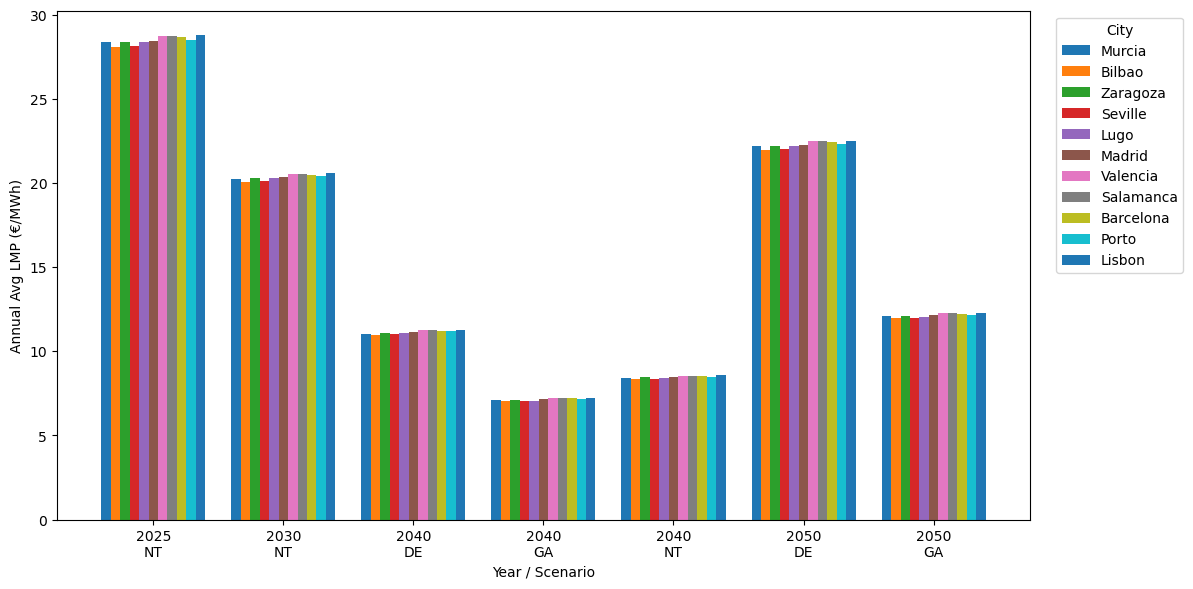

In [110]:
plot_nodal_price_grouped_bar(lmp_table, savefolder=figures_folder)

In [111]:
branch_extension_duals = branch_extension_duals.rename_axis(index={"branch": "line"})
branch_extension_duals

dual_value
line year            
88   2025         0.0
     2030         0.0
     2040         0.0
     2050         0.0
89   2025         0.0
...               ...
107  2050         0.0
219  2025         0.0
     2030         0.0
     2040         0.0
     2050         0.0

[76 rows x 1 columns]

In [112]:
generators["production_cost"] = (
    generators["marginal_cost"] + generators["co2_emissions"] * CO2_price
)
generators.groupby("carrier")["production_cost"].mean().sort_values(ascending=True)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
coal          57.096970
CCGT          57.520397
Name: production_cost, dtype: float64

In [113]:
def compute_lmp_bucket_frequencies(
    power_balance_duals: pd.DataFrame,
    generators: pd.DataFrame,
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Bucket hourly LMPs into ±10% intervals around each carrier’s mean production_cost,
    combine onwind/offwind into 'wind', rename ror to 'non-binding',
    merge overlapping coal & CCGT into 'thermal', create gap buckets,
    and include an 'other' category. Returns bucket bounds and frequencies.
    """
    # 1) Mean production cost by carrier
    carrier_cost = generators.reset_index().groupby("carrier")["production_cost"].mean()
    # 2) Combine & rename carriers: merge coal+CCGT into 'thermal'
    cost_map = {
        "non-binding": carrier_cost["ror"],
        "solar": carrier_cost["solar"],
        "wind": (carrier_cost["onwind"] + carrier_cost["offwind-ac"]) / 2,
        "thermal": None,  # placeholder
    }
    # compute thermal cost interval union
    coal_c = carrier_cost["coal"]
    ccgt_c = carrier_cost["CCGT"]
    # lower = min(0.9*cost), upper = max(1.1*cost)
    thermal_lower = min(coal_c, ccgt_c) * 0.9
    thermal_upper = max(coal_c, ccgt_c) * 1.1
    # assign a representative cost (midpoint) for sorting
    thermal_cost = (coal_c + ccgt_c) / 2
    cost_map["thermal"] = thermal_cost

    # 3) Build intervals ±10%
    intervals = []
    for label, cost in cost_map.items():
        if label == "thermal":
            lower, upper = thermal_lower, thermal_upper
        else:
            if cost == 0:
                # Avoid division by zero
                lower, upper = -0.0001, 0.0001
            else:
                lower, upper = cost * 0.9, cost * 1.1
        intervals.append({"label": label, "lower": lower, "upper": upper})

    # 4) Sort by lower bound
    intervals = sorted(intervals, key=lambda x: x["lower"])

    # 5) Create gap buckets between non-overlapping intervals
    buckets = []
    for i, iv in enumerate(intervals):
        buckets.append(iv)
        if i < len(intervals) - 1:
            next_iv = intervals[i + 1]
            if next_iv["lower"] > iv["upper"]:
                buckets.append(
                    {
                        "label": f"gap_{iv['label']}_{next_iv['label']}",
                        "lower": iv["upper"],
                        "upper": next_iv["lower"],
                    }
                )
    # 6) Sort buckets by lower bound again
    buckets = sorted(buckets, key=lambda x: x["lower"])

    # 7) Flatten LMPs
    df = power_balance_duals.reset_index()[["dual_value"]].rename(
        columns={"dual_value": "LMP"}
    )

    # 8) Assign each LMP to a bucket
    conditions = [
        (df["LMP"] >= b["lower"]) & (df["LMP"] <= b["upper"]) for b in buckets
    ]
    labels = [b["label"] for b in buckets]
    df["bucket"] = np.select(conditions, labels, default="other")

    # 9) Compute frequencies
    abs_counts = (
        df["bucket"]
        .value_counts()
        .reindex(labels + ["other"], fill_value=0)
        .astype(int)
    )
    total = len(df)
    rel_perc = (abs_counts / total) * 100

    # 10) Prepare bounds table
    bounds = pd.DataFrame(buckets).set_index("label")[["lower", "upper"]]
    bounds.index.name = "bucket"
    bounds.loc["other"] = [np.nan, np.nan]

    # 11) Combine into result
    result = bounds.copy()
    result["absolute"] = abs_counts
    result["relative_percent"] = rel_perc

    print("LMP Bucket Frequencies")
    if savefolder:
        result.to_csv(os.path.join(savefolder, "lmp_bucket_frequencies.csv"))

    return result

In [114]:
freqs = compute_lmp_bucket_frequencies(power_balance_duals, generators, tables_folder)
freqs

LMP Bucket Frequencies


,lower,upper,absolute,relative_percent
bucket,,,,
non-binding,-0.000100,0.000100,0,0.000000
gap_non-binding_solar,0.000100,0.009000,20092,38.829623
solar,0.009000,0.011000,671,1.296769
gap_solar_wind,0.011000,0.013500,0,0.000000
wind,0.013500,0.016500,7645,14.774660
gap_wind_thermal,0.016500,51.387273,16812,32.490724
thermal,51.387273,63.272437,6458,12.480674
other,NaN,NaN,66,0.127551


In [115]:
def plot_lmp_histogram_70plus(
    power_balance_duals: pd.DataFrame,
    cap: float = 70,
    bin_width: float = 1.0,
    savefolder: str | None = None,
) -> None:
    """
    Plot histogram of LMP frequencies with bin size 1 €/MWh, capping at `cap`:
    - Bins from floor(min LMP) to `cap` in steps of `bin_width`
    - One extra bin labeled 'cap+' for values above `cap`
    Prints the values and count in the `cap+` bin.
    """
    # Extract LMP values
    lmp = power_balance_duals.reset_index()["dual_value"]

    # Split into under/over
    lmp_under = lmp[lmp <= cap]
    lmp_over = lmp[lmp > cap]

    # Bin edges for <= cap
    min_val = np.floor(lmp_under.min() if not lmp_under.empty else cap)
    bins = np.arange(min_val, cap + bin_width, bin_width)

    # Histogram counts for <= cap
    counts, edges = np.histogram(lmp_under, bins=bins)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(
        edges[:-1],
        counts,
        width=bin_width,
        align="edge",
        edgecolor="black",
        label=f"≤ {cap} €/MWh",
    )
    # Plot the cap+ bin
    ax.bar(
        cap,
        len(lmp_over),
        width=bin_width,
        align="edge",
        edgecolor="black",
        color="gray",
        label=f"> {cap} €/MWh",
    )

    # Labels & ticks
    xticks = list(edges[:-1]) + [cap]
    xticklabels = [f"{int(e)}" for e in edges[:-1]] + [f"{int(cap)}+"]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=0)
    ax.set_xlabel("LMP (€/MWh)")
    ax.set_ylabel("Frequency (timesteps)")
    ax.legend()
    plt.tight_layout()
    print(f"LMP ≥ {cap} €/MWh: count = {len(lmp_over)} timesteps")
    # print("Values in ≥ cap bin:", np.sort(lmp_over.values))
    plt.show()

    # Save if requested
    if savefolder:
        fig.savefig(
            os.path.join(savefolder, f"lmp_histogram_{int(cap)}plus.png"),
            bbox_inches="tight",
        )


# Example usage:
# plot_lmp_histogram_70plus(power_balance_duals, cap=70, bin_width=1.0, savefolder=None)

LMP ≥ 70 €/MWh: count = 66 timesteps


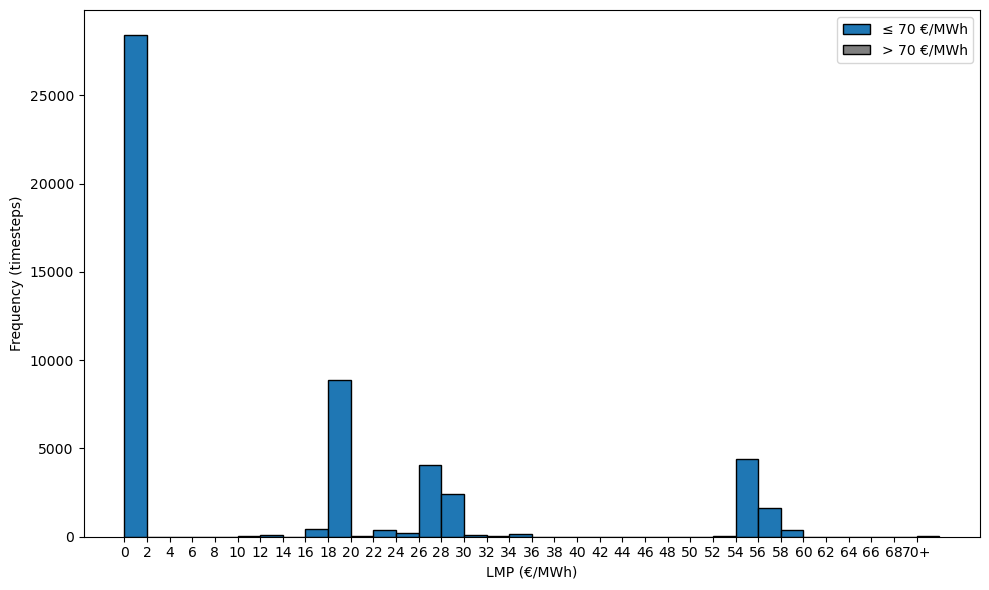

In [116]:
plot_lmp_histogram_70plus(
    power_balance_duals, cap=70, bin_width=2.0, savefolder=figures_folder
)

In [117]:
def make_lmp_frequency_table(
    power_balance_duals: pd.DataFrame,
    bin_width: float,
    cap: float | None = None,
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Create a table of LMP frequencies for custom bin width, including
    counts per year in each bin.

    Parameters
    ----------
    power_balance_duals : pd.DataFrame
        MultiIndexed by (node, scenario, year, week, hour) with 'dual_value' column.
    bin_width : float
        Width of each bin in €/MWh.
    cap : float or None, optional
        If provided, values > cap go into a single 'cap+' bin.

    Returns
    -------
    pd.DataFrame
        Columns:
          - lower_bound (float or 'cap+')
          - upper_bound (float or np.inf)
          - count        (int total)
          - percent      (float, percent of total)
          - count_{year} for each year
    """
    # Extract LMP and year series
    df = power_balance_duals.reset_index()[["year", "dual_value"]].rename(
        columns={"dual_value": "LMP"}
    )
    total = len(df)

    # Determine bin edges
    min_val = np.floor(df["LMP"].min())
    max_val = np.ceil(df["LMP"].max()) if cap is None else cap
    edges = np.arange(min_val, max_val + bin_width, bin_width)

    # Prepare list of years
    years = sorted(df["year"].unique())

    rows = []
    if cap is not None:
        # Under-cap bins
        df_under = df[df["LMP"] <= cap]
        cats = pd.cut(df_under["LMP"], bins=edges, include_lowest=True, right=False)
        df_under = df_under.assign(bin=cats)
        for interval in cats.cat.categories:
            mask = df_under["bin"] == interval
            cnt = mask.sum()
            pct = cnt / total * 100
            row = {
                "lower_bound": interval.left,
                "upper_bound": interval.right,
                "count": int(cnt),
                "percent": pct,
            }
            # per-year counts
            for y in years:
                row[f"count_{y}"] = int(
                    df_under[mask & (df_under["year"] == y)].shape[0]
                )
            rows.append(row)
        # cap+ bin
        df_over = df[df["LMP"] > cap]
        cnt_over = len(df_over)
        pct_over = cnt_over / total * 100
        row = {
            "lower_bound": cap,
            "upper_bound": np.inf,
            "count": int(cnt_over),
            "percent": pct_over,
        }
        for y in years:
            row[f"count_{y}"] = int(df_over[df_over["year"] == y].shape[0])
        rows.append(row)
    else:
        cats = pd.cut(df["LMP"], bins=edges, include_lowest=True, right=False)
        df = df.assign(bin=cats)
        for interval in cats.cat.categories:
            mask = df["bin"] == interval
            cnt = mask.sum()
            pct = cnt / total * 100
            row = {
                "lower_bound": interval.left,
                "upper_bound": interval.right,
                "count": int(cnt),
                "percent": pct,
            }
            for y in years:
                row[f"count_{y}"] = int(df[mask & (df["year"] == y)].shape[0])
            rows.append(row)

    # Build DataFrame
    table = pd.DataFrame(rows)
    if savefolder:
        table.to_csv(os.path.join(savefolder, "lmp_frequency_table.csv"), index=False)
    table_sorted = table.sort_values(by="count", ascending=False).reset_index(drop=True)
    if savefolder:
        table_sorted.to_csv(
            os.path.join(savefolder, "lmp_frequency_table_sorted.csv"), index=False
        )
    return table

In [118]:
freq_table = make_lmp_frequency_table(
    power_balance_duals, bin_width=1.0, cap=70, savefolder=tables_folder
)
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.width", None
):
    sorted_freq_table = freq_table.sort_values(by="count", ascending=False)
    display(sorted_freq_table)

,lower_bound,upper_bound,count,percent,count_2025,count_2030,count_2040,count_2050
0,0.0,1.0,28408,54.901051,3619,4697,12523,7569
18,18.0,19.0,7203,13.920455,0,0,7203,0
27,27.0,28.0,3982,7.695578,0,0,0,3982
55,55.0,56.0,3036,5.867347,1840,1196,0,0
28,28.0,29.0,1720,3.324057,0,0,0,1720
19,19.0,20.0,1682,3.250618,0,0,1682,0
54,54.0,55.0,1385,2.676639,747,638,0,0
56,56.0,57.0,1085,2.096861,699,386,0,0
29,29.0,30.0,678,1.310297,0,0,0,678
57,57.0,58.0,530,1.024273,284,246,0,0


In [119]:
generators["production_cost"].groupby(generators["carrier"]).mean().sort_values(
    ascending=True
)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
coal          57.096970
CCGT          57.520397
Name: production_cost, dtype: float64

In [120]:
def analyze_dual_interval(
    duals: pd.DataFrame | pd.Series,
    lower: float,
    upper: float,
    n_bins: int = 10,
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Print absolute and relative counts of dual values in [lower, upper],
    then return a table dividing that interval into n_bins sub‐intervals
    with counts and percentages within this interval.

    Parameters
    ----------
    duals : pd.DataFrame or pd.Series
        If DataFrame, must have column 'dual_value'; or a Series of values.
    lower : float
        Lower bound of interval (inclusive).
    upper : float
        Upper bound of interval (inclusive).
    n_bins : int, optional
        Number of sub‐bins within [lower, upper] to divide.

    Returns
    -------
    pd.DataFrame
        Columns: lower_bound, upper_bound, count, percent (of values in [lower,upper]).
    """
    # Extract series of values
    if isinstance(duals, pd.DataFrame) and "dual_value" in duals.columns:
        vals = duals["dual_value"]
    elif isinstance(duals, pd.Series):
        vals = duals
    else:
        raise ValueError(
            "`duals` must be DataFrame with 'dual_value' column or a Series."
        )

    total = len(vals)
    mask = (vals >= lower) & (vals <= upper)
    sub = vals[mask]
    count = len(sub)
    percent = count / total * 100

    print(f"Values in interval [{lower}, {upper}]: count = {count} ({percent:.2f}%)")

    # Build sub‐bins
    edges = np.linspace(lower, upper, n_bins + 1)
    cats = pd.cut(sub, bins=edges, include_lowest=True, right=True)
    freq = cats.value_counts().sort_index()

    rows = []
    for interval, cnt in freq.items():
        rows.append(
            {
                "lower_bound": interval.left,
                "upper_bound": interval.right,
                "count": int(cnt),
                "percent_of_interval": cnt / count * 100 if count > 0 else 0,
            }
        )

    df = pd.DataFrame(rows)
    if savefolder:
        df.to_csv(
            os.path.join(savefolder, f"table_duals_{lower}-{upper}_{n_bins}.csv"),
            index=False,
        )
    return pd.DataFrame(rows)


def plot_dual_interval_histogram(
    duals: pd.DataFrame | pd.Series,
    lower: float,
    upper: float,
    n_bins: int = 10,
    savefolder: str | None = None,
) -> None:
    """
    Plot histogram of duals within [lower, upper], divided into n_bins.

    Parameters
    ----------
    duals : pd.DataFrame or pd.Series
        If DataFrame, must have 'dual_value' column, otherwise a Series.
    lower : float
        Lower bound of histogram.
    upper : float
        Upper bound of histogram.
    n_bins : int, optional
        Number of bins between lower and upper.
    savefolder : str or None
        Directory to save the figure. If None, not saved.
    """
    # Extract values
    if isinstance(duals, pd.DataFrame) and "dual_value" in duals.columns:
        vals = duals["dual_value"]
    elif isinstance(duals, pd.Series):
        vals = duals
    else:
        raise ValueError(
            "`duals` must be DataFrame with 'dual_value' column or a Series."
        )

    # Filter interval
    sub = vals[(vals >= lower) & (vals <= upper)]

    # Bin edges
    edges = np.linspace(lower, upper, n_bins + 1)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(sub, bins=edges, edgecolor="black")
    ax.set_xlabel("Dual value")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    print(f"Histogram of duals in [{lower}, {upper}] with {n_bins} bins")
    plt.show()

    # Save if requested
    if savefolder:
        fname = f"dual_hist_{lower}-{upper}_{n_bins}bins.png"
        fig.savefig(os.path.join(savefolder, fname), bbox_inches="tight")

In [121]:
def plot_top_10_dual_intervals(
    power_balance_duals: pd.DataFrame,
    sorted_freq_table: pd.DataFrame,
    n_bins: int = 10,
    savefolder: str | None = None,
) -> None:
    """
    Plot histograms for the top n dual intervals from the sorted frequency table.

    Parameters
    ----------
    power_balance_duals : pd.DataFrame
        DataFrame with dual values.
    sorted_freq_table : pd.DataFrame
        DataFrame with sorted frequency table.
    n_bins : int, optional
        Number of bins for histogram.
    savefolder : str or None
        Directory to save figures. If None, not saved.
    """
    if savefolder:
        savefolder = os.path.join(savefolder, "dual_interval_histograms")
        os.makedirs(savefolder, exist_ok=True)
    # Iterate over the top n intervals
    for idk, row in sorted_freq_table.head(10).iterrows():
        lb = row["lower_bound"]
        ub = row["upper_bound"]
        print(f"Analyzing dual interval [{lb}, {ub}]")
        plot_dual_interval_histogram(
            power_balance_duals, lb, ub, n_bins=n_bins, savefolder=savefolder
        )


def create_top_10_dual_intervals_tables(
    power_balance_duals: pd.DataFrame,
    sorted_freq_table: pd.DataFrame,
    n_bins: int = 10,
    savefolder: str | None = None,
) -> None:
    """
    Create tables for the top n dual intervals from the sorted frequency table.

    Parameters
    ----------
    power_balance_duals : pd.DataFrame
        DataFrame with dual values.
    sorted_freq_table : pd.DataFrame
        DataFrame with sorted frequency table.
    n_bins : int, optional
        Number of bins for histogram.
    savefolder : str or None
        Directory to save figures. If None, not saved.
    """
    # Iterate over the top n intervals
    if savefolder:
        savefolder = os.path.join(savefolder, "dual_interval_tables")
        os.makedirs(savefolder, exist_ok=True)
    for idk, row in sorted_freq_table.head(10).iterrows():
        lb = row["lower_bound"]
        ub = row["upper_bound"]
        analyze_dual_interval(
            power_balance_duals, lb, ub, n_bins=10, savefolder=savefolder
        )

Analyzing dual interval [0.0, 1.0]
Histogram of duals in [0.0, 1.0] with 10 bins


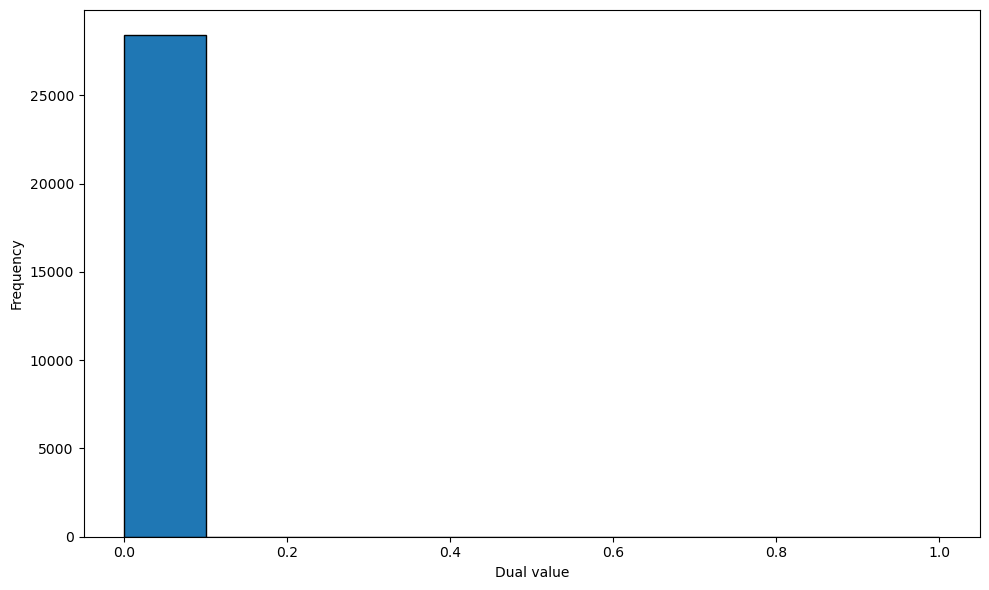

Analyzing dual interval [18.0, 19.0]
Histogram of duals in [18.0, 19.0] with 10 bins


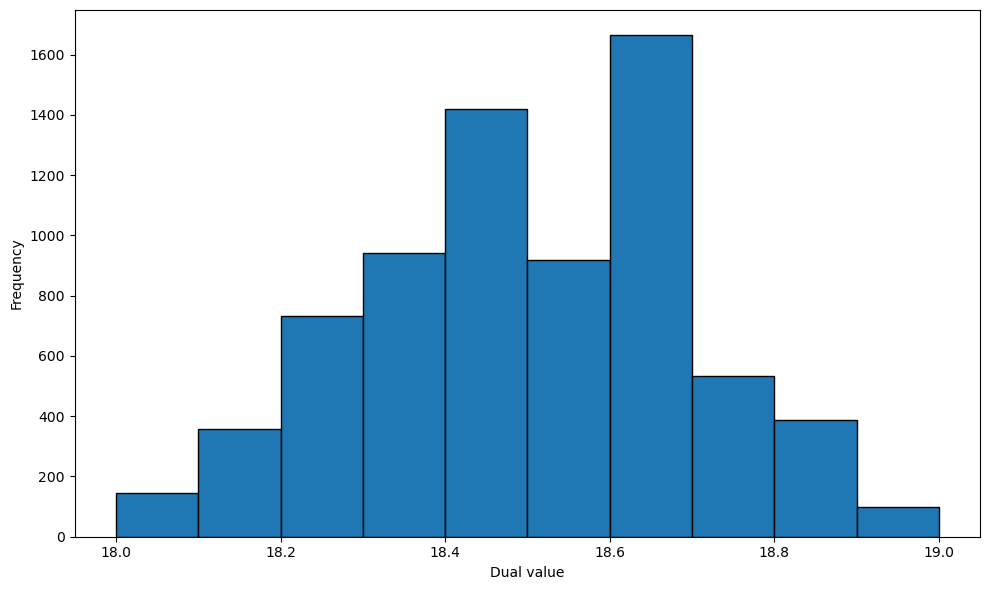

Analyzing dual interval [27.0, 28.0]
Histogram of duals in [27.0, 28.0] with 10 bins


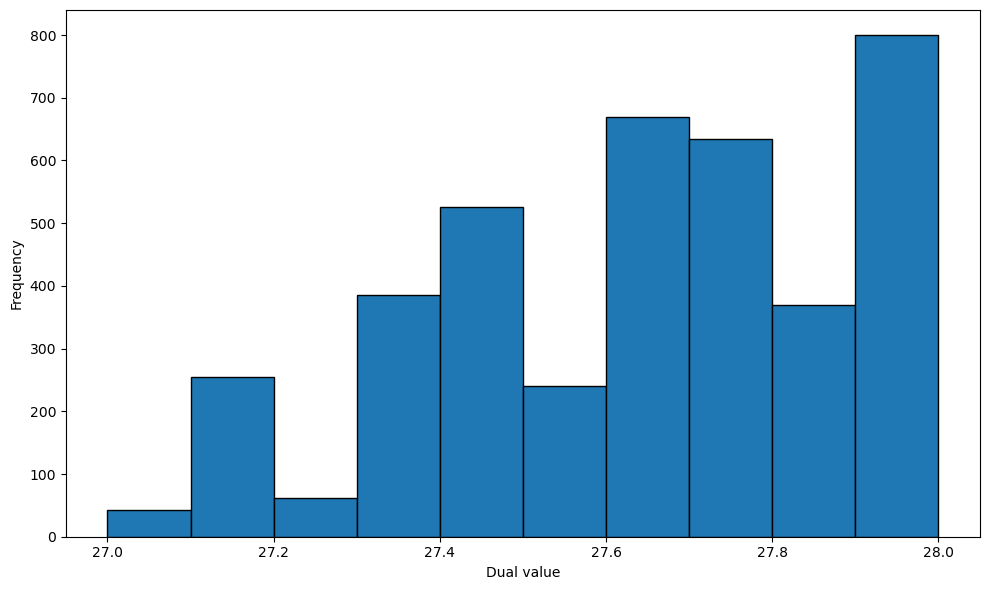

Analyzing dual interval [55.0, 56.0]
Histogram of duals in [55.0, 56.0] with 10 bins


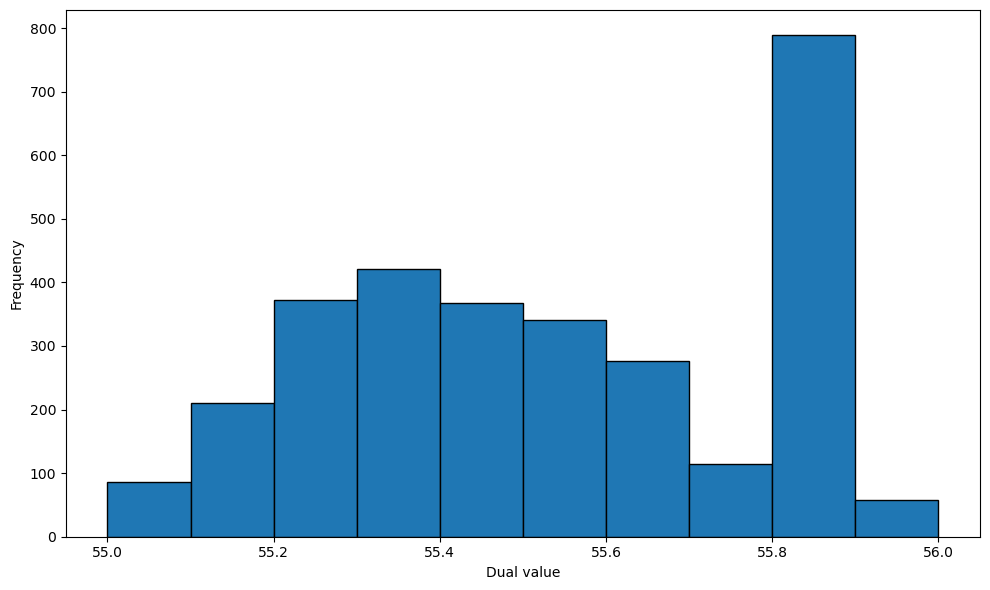

Analyzing dual interval [28.0, 29.0]
Histogram of duals in [28.0, 29.0] with 10 bins


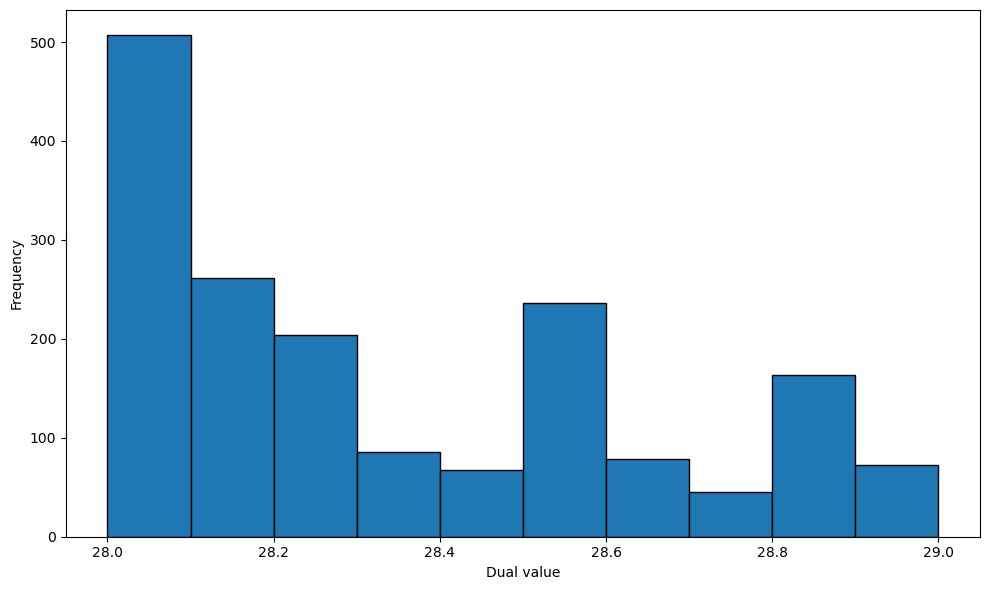

Analyzing dual interval [19.0, 20.0]
Histogram of duals in [19.0, 20.0] with 10 bins


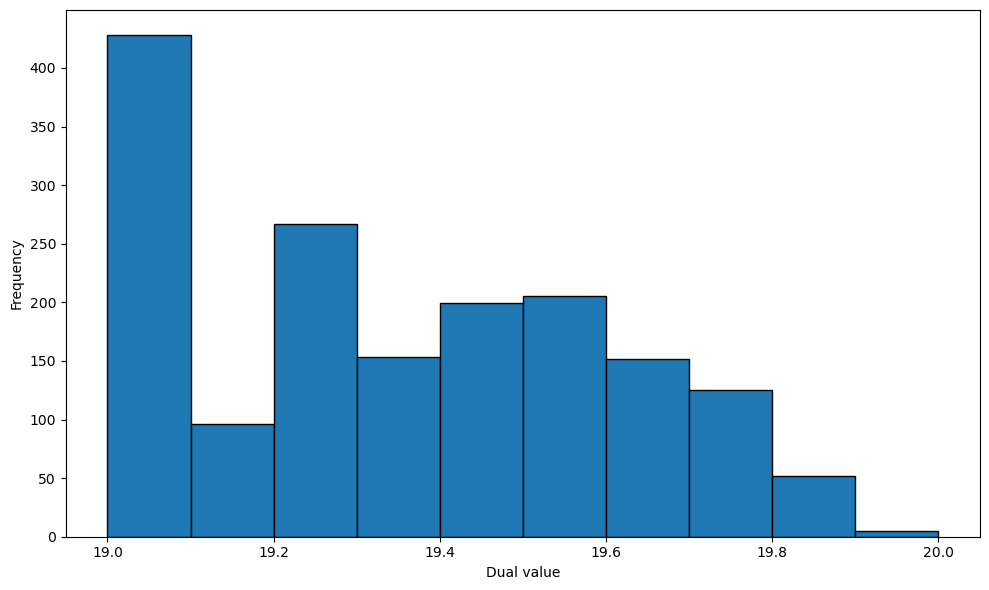

Analyzing dual interval [54.0, 55.0]
Histogram of duals in [54.0, 55.0] with 10 bins


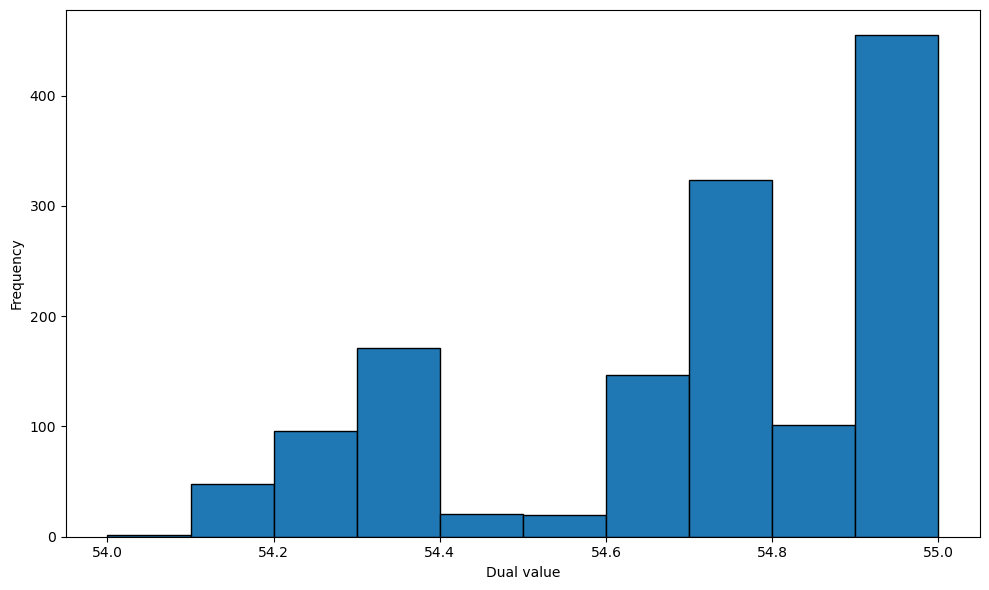

Analyzing dual interval [56.0, 57.0]
Histogram of duals in [56.0, 57.0] with 10 bins


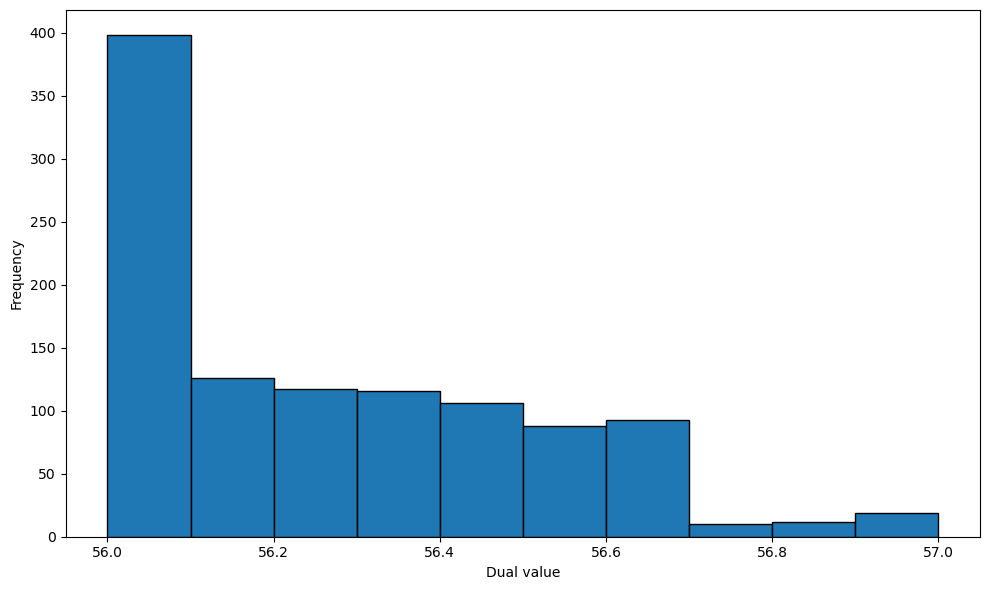

Analyzing dual interval [29.0, 30.0]
Histogram of duals in [29.0, 30.0] with 10 bins


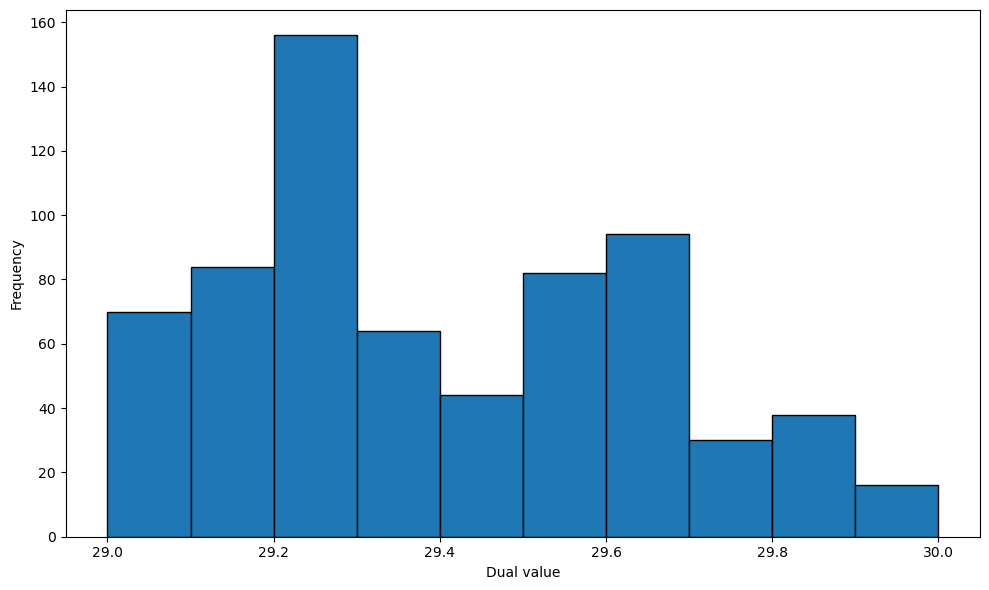

Analyzing dual interval [57.0, 58.0]
Histogram of duals in [57.0, 58.0] with 10 bins


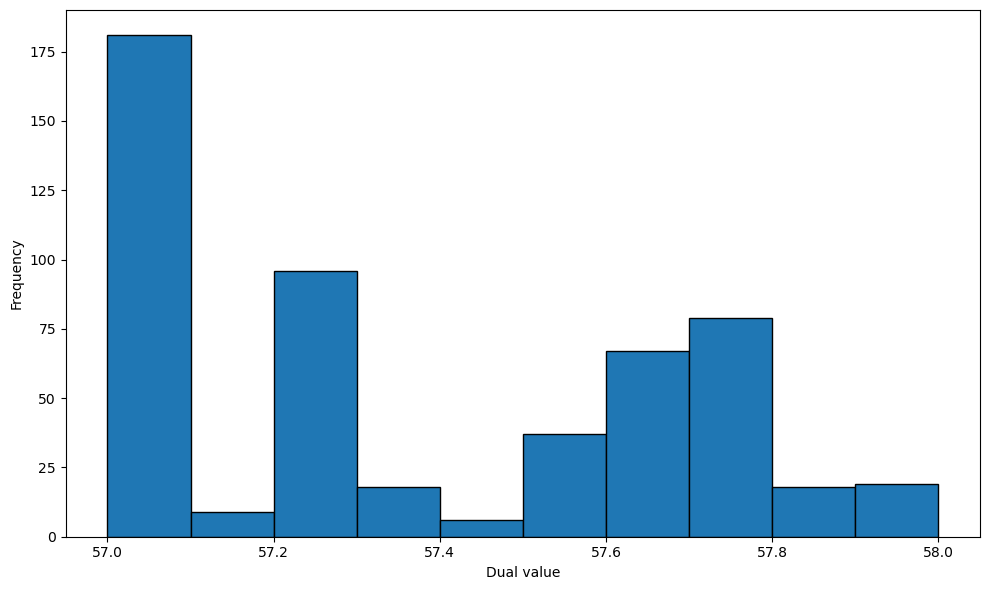

Values in interval [0.0, 1.0]: count = 28408 (54.90%)
Values in interval [18.0, 19.0]: count = 7203 (13.92%)
Values in interval [27.0, 28.0]: count = 3982 (7.70%)
Values in interval [55.0, 56.0]: count = 3036 (5.87%)
Values in interval [28.0, 29.0]: count = 1720 (3.32%)
Values in interval [19.0, 20.0]: count = 1682 (3.25%)
Values in interval [54.0, 55.0]: count = 1385 (2.68%)
Values in interval [56.0, 57.0]: count = 1085 (2.10%)
Values in interval [29.0, 30.0]: count = 678 (1.31%)
Values in interval [57.0, 58.0]: count = 530 (1.02%)


In [122]:
plot_top_10_dual_intervals(
    power_balance_duals, sorted_freq_table, n_bins=10, savefolder=figures_folder
)
create_top_10_dual_intervals_tables(
    power_balance_duals, sorted_freq_table, n_bins=10, savefolder=tables_folder
)

In [137]:
average_duals = power_balance_duals.groupby("year")["dual_value"].mean()
average_duals

year
2025    28.481108
2030    20.358291
2040     8.920910
2050    17.219394
Name: dual_value, dtype: float64

In [123]:
def summarise_extension_status_by_carrier(
    generators: pd.DataFrame, savfolder=None
) -> pd.DataFrame:
    """
    For each year and carrier, count how many generators are
    'not extended', 'partly extended', or 'fully extended'.

    Parameters
    ----------
    generators : pd.DataFrame
        Indexed by (year, generator) with columns:
        - carrier
        - new_capacity
        - extension_potential

    Returns
    -------
    pd.DataFrame
        MultiIndexed by (year, carrier) with columns:
        ['not extended', 'partly extended', 'fully extended']
        containing the counts for each status.
    """
    df = generators.reset_index()

    def _status(row):
        nc = row["new_capacity"]
        ep = row["extension_potential"]
        if nc == 0:
            return "not extended"
        if np.isclose(nc, ep):
            return "fully extended"
        if nc < ep:
            return "partly extended"
        # cover any rounding issues
        return "fully extended"

    df["extension_status"] = df.apply(_status, axis=1)
    summary = (
        df.groupby(["year", "carrier", "extension_status"])
        .size()
        .unstack("extension_status")
        .fillna(0)
        .astype(int)
    )
    # ensure all three columns exist
    for col in ["not extended", "partly extended", "fully extended"]:
        if col not in summary.columns:
            summary[col] = 0

    # sort columns
    summary = summary[["not extended", "partly extended", "fully extended"]]

    print(f"Extension status by carrier")
    if savfolder:
        summary.to_csv(os.path.join(savfolder, "extension_status_by_carrier.csv"))
    # Print the first few rows of the summary
    return summary

In [124]:
summary_by_carrier = summarise_extension_status_by_carrier(generators)
summary_by_carrier

Extension status by carrier


extension_status  not extended  partly extended  fully extended
year carrier                                                   
2025 CCGT                   10                1               0
     coal                    5                0               0
     offwind-ac              7                0               2
     onwind                  5                0               6
     ror                     2                0               2
     solar                   0                0              11
2030 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              8                0               1
     onwind                  9                0               2
     ror                     3                1               0
     solar                   1                1               9
2040 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              9                0               0
     onwind                 10                0               1
     ror                     4                0               0
     solar                  10                0               1
2050 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              9                0               0
     onwind                 11                0               0
     ror                     4                0               0
     solar                  11                0               0

In [125]:
emissions_duals

dual_value
scenario year            
NT       2025         0.0
         2030         0.0
         2040         0.0
GA       2040         0.0
DE       2040         0.0
GA       2050         0.0
DE       2050         0.0

In [126]:
def summarize_dual_nonzero_counts(
    dual_variables: dict[str, pd.DataFrame], savefolder: str | None = None
) -> pd.DataFrame:
    """
    For each dual variable, count total entries and non-zero entries.
    Optionally save the summary as CSV.

    Parameters
    ----------
    dual_variables : dict[str, pd.DataFrame]
        Mapping dual names → DataFrames with a 'dual_value' column.
    savefolder : str or None
        Directory to save the summary CSV. If None, no file is written.

    Returns
    -------
    pd.DataFrame
        Indexed by dual name with columns:
        - total_duals
        - nonzero_duals
        - percent_nonzero
    """
    rows = []
    for name, df in dual_variables.items():
        total = df["dual_value"].size
        nonzero = (df["dual_value"] != 0).sum()
        pct = (nonzero / total * 100) if total > 0 else 0.0
        rows.append(
            {
                "dual": name,
                "total_duals": int(total),
                "nonzero_duals": int(nonzero),
                "percent_nonzero": pct,
            }
        )
    summary = pd.DataFrame(rows).set_index("dual")

    if savefolder:
        path = os.path.join(savefolder, "dual_nonzero_summary.csv")
        summary.to_csv(path)

    return summary

In [127]:
# Usage example:
summary_table = summarize_dual_nonzero_counts(dual_variables, duals_folder)
summary_table

,total_duals,nonzero_duals,percent_nonzero
dual,,,
battery_charge_new_max_duals,51744,1138,2.199289
battery_charge_old_duals,0,0,0.000000
battery_discharge_new_max_duals,51744,675,1.304499
battery_discharge_old_duals,0,0,0.000000
branch_extension_duals,76,1,1.315789
branch_flow_new_duals_max,89376,9639,10.784774
branch_flow_new_duals_min,89376,34542,38.647959
branch_flow_old_duals_max,89376,9621,10.764635
branch_flow_old_duals_min,89376,34524,38.627820


In [128]:
def summarize_duals_by_year_scenario(
    dual_variables: dict[str, pd.DataFrame], savefolder: str | None = None
) -> pd.DataFrame:
    """
    For each dual variable, and for each year and scenario (or 'All' if no scenario),
    count total entries, non-zero entries, compute percent non-zero, and average dual value.

    Returns a DataFrame indexed by (dual, year, scenario) with columns:
      - total_duals
      - nonzero_duals
      - percent_nonzero
      - average_dual

    Optionally saves to “dual_year_scenario_summary.csv” in savefolder.
    """
    records = []
    for name, df in dual_variables.items():
        temp = df.reset_index()
        if "scenario" not in temp.columns:
            temp["scenario"] = "All"
        if "year" not in temp.columns:
            raise KeyError(f"{name}: missing 'year' index level")
        grp = temp.groupby(["year", "scenario"])["dual_value"]
        for (year, scen), series in grp:
            total = series.size
            nonzero = (series != 0).sum()
            pct = nonzero / total * 100 if total > 0 else 0.0
            avg = series.mean() if total > 0 else 0.0
            records.append(
                {
                    "dual": name,
                    "year": year,
                    "scenario": scen,
                    "total_duals": int(total),
                    "nonzero_duals": int(nonzero),
                    "percent_nonzero": pct,
                    "average_dual": avg,
                }
            )
    summary = pd.DataFrame(records).set_index(["dual", "year", "scenario"])
    if savefolder:
        summary.to_csv(f"{savefolder}/dual_year_scenario_summary.csv")
    return summary

In [139]:
18.5 * 3

55.5

In [129]:
summary = summarize_duals_by_year_scenario(dual_variables, savefolder=tables_folder)
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.width", None
):
    display(summary)

total_duals  nonzero_duals  \
dual                            year scenario                               
battery_charge_new_max_duals    2025 NT               7392             48   
                                2030 NT               7392            326   
                                2040 DE               7392            169   
                                     GA               7392            210   
                                     NT               7392            252   
                                2050 DE               7392             41   
                                     GA               7392             92   
battery_discharge_new_max_duals 2025 NT               7392            143   
                                2030 NT               7392             70   
                                2040 DE               7392            133   
                                     GA               7392            111   
                                     NT               7392            119   
                                2050 DE               7392             51   
                                     GA               7392             48   
branch_extension_duals          2025 All                19              1   
                                2030 All                19              0   
                                2040 All                19              0   
                                2050 All                19              0   
branch_flow_new_duals_max       2025 NT              12768           1254   
                                2030 NT              12768           1391   
                                2040 DE              12768           1400   
                                     GA              12768           1423   
                                     NT              12768           1407   
                                2050 DE              12768           1389   
                                     GA              12768           1375   
branch_flow_new_duals_min       2025 NT              12768           5035   
                                2030 NT              12768           4942   
                                2040 DE              12768           4917   
                                     GA              12768           4915   
                                     NT              12768           4900   
                                2050 DE              12768           4944   
                                     GA              12768           4889   
branch_flow_old_duals_max       2025 NT              12768           1251   
                                2030 NT              12768           1390   
                                2040 DE              12768           1399   
                                     GA              12768           1419   
                                     NT              12768           1404   
                                2050 DE              12768           1384   
                                     GA              12768           1374   
branch_flow_old_duals_min       2025 NT              12768           5034   
                                2030 NT              12768           4941   
                                2040 DE              12768           4915   
                                     GA              12768           4912   
                                     NT              12768           4900   
                                2050 DE              12768           4934   
                                     GA              12768           4888   
emissions_duals                 2025 NT                  1              0   
                                2030 NT                  1              0   
                                2040 DE                  1              0   
                                     GA                  1              0   
                                     NT    

In [130]:
def list_nonzero_gen_extension_duals(
    gen_extension_duals: pd.DataFrame, savefolder: str | None = None
) -> pd.DataFrame:
    """
    Identify which generators have non-zero extension duals in each year.

    Parameters
    ----------
    gen_extension_duals : pd.DataFrame
        MultiIndexed by (generator, year) with column 'dual_value'.
    savefolder : str or None
        Directory to save the results as CSV. If None, not saved.

    Returns
    -------
    pd.DataFrame
        Indexed by (year, generator) with column 'dual_value' for all non-zero entries.
    """
    # Flatten to columns
    df = gen_extension_duals.reset_index()[["year", "generator", "dual_value"]]
    # Filter non-zero
    nonzero = df[df["dual_value"] != 0].copy()
    # Sort by year, descending dual magnitude
    nonzero["abs_dual"] = nonzero["dual_value"].abs()
    nonzero = nonzero.sort_values(["year", "abs_dual"], ascending=[True, False])
    nonzero = nonzero.drop(columns=["abs_dual"])
    # Reindex
    result = nonzero.set_index(["year", "generator"])
    # Save if requested
    if savefolder:
        path = f"{savefolder}/gen_extension_nonzero_duals.csv"
        result.to_csv(path)
    return result

In [131]:
nz = list_nonzero_gen_extension_duals(gen_extension_duals, savefolder=tables_folder)
print(nz)

                          dual_value
year generator                      
2025 ES1 4 offwind-ac -121770.343909
     ES1 4 onwind      -98718.656325
     PT1 1 ror         -87410.141007
     PT1 0 ror         -83276.254010
     ES1 2 onwind      -59288.565619
     ES1 6 solar       -32739.260157
     ES1 2 solar       -30759.042326
     ES1 5 solar       -30618.691578
     PT1 0 offwind-ac  -30030.667353
     ES1 8 solar       -29308.392096
     ES1 3 solar       -27984.260188
     PT1 1 solar       -27776.686955
     ES1 0 solar       -24506.907997
     ES1 7 solar       -21057.595760
     PT1 0 solar       -16649.272941
     ES1 4 solar       -15671.567358
     ES1 1 onwind      -14807.143484
     ES1 1 solar       -12163.542246
     ES1 8 onwind       -9472.635869
     PT1 1 onwind       -7637.608236
     ES1 6 onwind       -3830.880814
2030 ES1 4 onwind      -38080.445800
     ES1 4 offwind-ac  -29615.620184
     ES1 2 onwind      -13115.141473
     ES1 6 solar       -10419.247821
 

In [132]:
generators.groupby("carrier")["capital_cost"].mean()

carrier
CCGT           99027.729293
coal          349976.553630
offwind-ac    184196.306769
onwind         96085.888020
ror           299140.224929
solar          35602.071244
Name: capital_cost, dtype: float64